# ABW: Is the Government a Good Market Maker? Quantifying the Spillover Effects of Federal Business on Industry Output
Authors: Kamau Njendu and Chris Howard

Las updated: 4/29/2026

Course: 15.076

## (1) Developing the Database

In [ ]:
# Set working folder to directory working within. Files should be saved to this folder as well as the code. Files will save to this folder.

working_folder = "C:/Users/klnje/Desktop/School/College/Fourth_Year/Spring/15.076/Project"

### Dependent variable data: Value Added Data by Industry

##### BEA: Gross Nominal Output by Industry
**Dataset:** GDPbyIndustry · **TableID:** 15 · **Frequency:** Annual  
**Source:** U.S. Bureau of Economic Analysis

Full pipeline: API call → raw JSON → clean DataFrame → analysis-ready panel.

Output columns: `naics_code`, `industry`, `year`, `gross_output_m` (millions USD), `gross_output` (actual USD)

In [ ]:
pip install openpyxl

In [ ]:
BEA_KEY = "06936326-712D-4445-B15F-A78B76304A76"
BASE    = "https://apps.bea.gov/api/data"

In [ ]:
import os
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import io

API_KEY  = BEA_KEY
BASE_URL = BASE

In [73]:
# ── Real Value Added  (TableID=10, chained 2017 $M) ─────────────

print("Pulling real value added...")
results = bea_get({
    "method":      "GetData",
    "datasetname": "GDPbyIndustry",
    "TableID":     10,
    "Industry":    "ALL",
    "Frequency":   "A",
    "Year":        "ALL",
})

df_va_raw = extract_rows(results)
df_va_raw = clean_columns(df_va_raw)
df_va     = df_va_raw[df_va_raw["Frequency"] == "A"].copy()
df_va     = standard_rename(df_va)
df_va     = add_year_int(df_va)
df_va, _  = drop_aggregates(df_va)
df_va     = parse_datavalue(df_va)

df_va["value_added_real_m"] = df_va["DataValue"]
df_va["value_added_real"]   = df_va["DataValue"] * 1_000_000
df_va = df_va[["naics_code", "industry", "year",
               "value_added_real_m", "value_added_real"]].sort_values(["naics_code","year"]).reset_index(drop=True)

qa_report(df_va, "value_added_real_m", "Real Value Added")
df_va.to_csv("bea_value_added_real.csv", index=False)


# ── Real Gross Output  (TableID=208, chained 2017 $M) ───────────

print("\nPulling real gross output...")
results = bea_get({
    "method":      "GetData",
    "datasetname": "GDPbyIndustry",
    "TableID":     208,
    "Industry":    "ALL",
    "Frequency":   "A",
    "Year":        "ALL",
})

df_go_raw = extract_rows(results)
df_go_raw = clean_columns(df_go_raw)
df_go     = df_go_raw[df_go_raw["Frequency"] == "A"].copy()
df_go     = standard_rename(df_go)
df_go     = add_year_int(df_go)
df_go, _  = drop_aggregates(df_go)
df_go     = parse_datavalue(df_go)

df_go["gross_output_real_m"] = df_go["DataValue"]
df_go["gross_output_real"]   = df_go["DataValue"] * 1_000_000
df_go = df_go[["naics_code", "industry", "year",
               "gross_output_real_m", "gross_output_real"]].sort_values(["naics_code","year"]).reset_index(drop=True)

qa_report(df_go, "gross_output_real_m", "Real Gross Output")
df_go.to_csv("bea_gross_output_real.csv", index=False)


# ── Employment  (TableID=11, thousands of jobs) ──────────────────

print("\nPulling employment...")
results = bea_get({
    "method":      "GetData",
    "datasetname": "GDPbyIndustry",
    "TableID":     11,
    "Industry":    "ALL",
    "Frequency":   "A",
    "Year":        "ALL",
})

df_emp_raw = extract_rows(results)
df_emp_raw = clean_columns(df_emp_raw)
df_emp     = df_emp_raw[df_emp_raw["Frequency"] == "A"].copy()
df_emp     = standard_rename(df_emp)
df_emp     = add_year_int(df_emp)
df_emp, _  = drop_aggregates(df_emp)
df_emp     = parse_datavalue(df_emp)

df_emp["employment_k"] = df_emp["DataValue"]
df_emp["employment"]   = df_emp["DataValue"] * 1_000
df_emp = df_emp[["naics_code", "industry", "year",
                 "employment_k", "employment"]].sort_values(["naics_code","year"]).reset_index(drop=True)

qa_report(df_emp, "employment_k", "Employment")
df_emp.to_csv("bea_employment.csv", index=False)


# ── Merge into panel ─────────────────────────────────────────────

print("\nMerging into panel...")
df_panel = (
    df_va
    .merge(df_go[["naics_code","year","gross_output_real_m","gross_output_real"]],
           on=["naics_code","year"], how="left")
    .merge(df_emp[["naics_code","year","employment_k","employment"]],
           on=["naics_code","year"], how="left")
)

df_panel = df_panel.sort_values(["naics_code","year"])

# Lagged real value added — denominator for contract intensity
df_panel["value_added_real_m_lag1"] = (
    df_panel.groupby("naics_code")["value_added_real_m"].shift(1)
)

# YoY growth rate of real value added — primary TWFE outcome
df_panel["va_growth"] = (
    df_panel.groupby("naics_code")["value_added_real_m"].pct_change()
)

# Employment growth — control variable
df_panel["emp_growth"] = (
    df_panel.groupby("naics_code")["employment_k"].pct_change()
)

df_panel = df_panel.sort_values(["naics_code","year"]).reset_index(drop=True)

# Sanity check — real VA in 2017 should equal nominal VA in 2017
print(f"\nFinal panel: {len(df_panel):,} rows × {len(df_panel.columns)} cols")
print(f"Columns: {list(df_panel.columns)}")
print(f"Missing va_growth:  {df_panel['va_growth'].isna().sum()}")
print(f"Missing emp_growth: {df_panel['emp_growth'].isna().sum()}")
print(f"Missing gross_output (left join gaps): {df_panel['gross_output_real_m'].isna().sum()}")

df_panel.to_csv("bea_panel.csv", index=False)
print("\nSaved bea_panel.csv")
df_panel.head(10)

Pulling real value added...

── Real Value Added ──
  Year range:   1997–2025  (29 years)
  Industries:   101
  Total rows:   2,928
  Missing vals: 0 (0.0%)
  Duplicates:   0
  Value range:  -804.6 – 23,850.4

Pulling real gross output...

── Real Gross Output ──
  Year range:   1997–2025  (29 years)
  Industries:   101
  Total rows:   2,928
  Missing vals: 0 (0.0%)
  Duplicates:   0
  Value range:  -612.5 – 41,009.3

Pulling employment...

── Employment ──
  Year range:   1997–2025  (29 years)
  Industries:   100
  Total rows:   2,899
  Missing vals: 0 (0.0%)
  Duplicates:   0
  Value range:  17.0 – 2,323.6

Merging into panel...

Final panel: 2,928 rows × 12 cols
Columns: ['naics_code', 'industry', 'year', 'value_added_real_m', 'value_added_real', 'gross_output_real_m', 'gross_output_real', 'employment_k', 'employment', 'value_added_real_m_lag1', 'va_growth', 'emp_growth']
Missing va_growth:  101
Missing emp_growth: 129
Missing gross_output (left join gaps): 29

Saved bea_panel.csv


C:\Users\klnje\AppData\Local\Temp\ipykernel_20344\3417235536.py:113: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_panel.groupby("naics_code")["employment_k"].pct_change()


,naics_code,industry,year,value_added_real_m,value_added_real,...,employment_k,employment,value_added_real_m_lag1,va_growth,emp_growth
0,11,"Agriculture, forestry, fishing, and hunting",1997,113,"113,200,000",...,96,"95,945",NaN,NaN,NaN
1,11,"Agriculture, forestry, fishing, and hunting",1998,112,"111,700,000",...,90,"90,202",113,-0,-0
2,11,"Agriculture, forestry, fishing, and hunting",1999,114,"114,400,000",...,82,"81,581",112,0,-0
3,11,"Agriculture, forestry, fishing, and hunting",2000,130,"129,900,000",...,76,"76,156",114,0,-0
4,11,"Agriculture, forestry, fishing, and hunting",2001,127,"127,100,000",...,79,"79,283",130,-0,0
5,11,"Agriculture, forestry, fishing, and hunting",2002,131,"131,300,000",...,74,"73,609",127,0,-0
6,11,"Agriculture, forestry, fishing, and hunting",2003,142,"141,500,000",...,81,"81,486",131,0,0
7,11,"Agriculture, forestry, fishing, and hunting",2004,153,"153,400,000",...,94,"94,192",142,0,0
8,11,"Agriculture, forestry, fishing, and hunting",2005,160,"159,600,000",...,82,"81,597",153,0,-0
9,11,"Agriculture, forestry, fishing, and hunting",2006,162,"161,700,000",...,79,"78,634",160,0,-0


In [74]:
# ── Fix FutureWarning + inspect missing values ───────────────────

df_panel = df_panel.sort_values(["naics_code","year"])

# YoY growth — fill_method=None means we don't forward-fill gaps
# before differencing, which is correct behavior for panel data
df_panel["va_growth"] = (
    df_panel.groupby("naics_code")["value_added_real_m"]
    .pct_change(fill_method=None)
)

df_panel["emp_growth"] = (
    df_panel.groupby("naics_code")["employment_k"]
    .pct_change(fill_method=None)
)

# ── Diagnose the missing values ──────────────────────────────────

# va_growth: expect exactly 1 missing per industry (first year of each panel)
# anything beyond that = gaps in the time series
n_industries = df_panel["naics_code"].nunique()
print(f"Industries: {n_industries}")
print(f"Expected missing va_growth (1 per industry): {n_industries}")
print(f"Actual missing va_growth:                    {df_panel['va_growth'].isna().sum()}")

# Find industries with more than 1 missing va_growth — these have internal gaps
va_missing = (
    df_panel[df_panel["va_growth"].isna()]
    .groupby("naics_code")
    .agg(missing_years=("year","count"), years=("year", list))
    .reset_index()
)
internal_gaps = va_missing[va_missing["missing_years"] > 1]
print(f"\nIndustries with internal va_growth gaps (>1 missing):")
print(internal_gaps.to_string() if len(internal_gaps) else "  None — all missing are first-year only ✓")

# emp_growth: same check — 129 missing vs ~100 industries suggests some gaps
emp_missing = (
    df_panel[df_panel["emp_growth"].isna()]
    .groupby("naics_code")
    .agg(missing_years=("year","count"), years=("year", list))
    .reset_index()
)
internal_emp_gaps = emp_missing[emp_missing["missing_years"] > 1]
print(f"\nIndustries with internal emp_growth gaps (>1 missing):")
print(internal_emp_gaps.to_string() if len(internal_emp_gaps) else "  None ✓")

# gross_output left join gaps — which industries/years are missing?
go_missing = df_panel[df_panel["gross_output_real_m"].isna()][["naics_code","industry","year"]]
print(f"\nMissing gross output rows ({len(go_missing)}):")
print(go_missing.to_string())

Industries: 101
Expected missing va_growth (1 per industry): 101
Actual missing va_growth:                    101

Industries with internal va_growth gaps (>1 missing):
  None — all missing are first-year only ✓

Industries with internal emp_growth gaps (>1 missing):
   naics_code  missing_years                                                                                                                                                                           years
95       NABI             29  [1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Missing gross output rows (29):
     naics_code                industry  year
2436        GDP  Gross domestic product  1997
2437        GDP  Gross domestic product  1998
2438        GDP  Gross domestic product  1999
2439        GDP  Gross domestic product  2000
2440        GDP  Gross domestic product  2001
2441        G

In [76]:
# ── Drop BEA residual/aggregate rows that aren't real industries ─

DROP_CODES = ["NABI", "GDP"]

before = len(df_panel)
df_panel = df_panel[~df_panel["naics_code"].isin(DROP_CODES)].copy()
print(f"Dropped {before - len(df_panel)} rows for codes: {DROP_CODES}")

# ── Recompute growth rates cleanly on filtered panel ────────────

df_panel = df_panel.sort_values(["naics_code","year"])

df_panel["va_growth"] = (
    df_panel.groupby("naics_code")["value_added_real_m"]
    .pct_change(fill_method=None)
)

df_panel["emp_growth"] = (
    df_panel.groupby("naics_code")["employment_k"]
    .pct_change(fill_method=None)
)

df_panel["value_added_real_m_lag1"] = (
    df_panel.groupby("naics_code")["value_added_real_m"].shift(1)
)

# ── Update drop_aggregates to catch these in future pulls ────────
# Add to your existing function so you don't have to patch manually

def drop_aggregates(df):
    """Remove all-industry aggregate and BEA residual rows."""
    AGGREGATE_CODES = ["...", "NABI", "GDP"]
    df_removed = df[df["naics_code"].isin(AGGREGATE_CODES)].copy()
    df_clean   = df[~df["naics_code"].isin(AGGREGATE_CODES)].copy()
    return df_clean, df_removed

# ── Final QA ─────────────────────────────────────────────────────

n_industries = df_panel["naics_code"].nunique()
print(f"\nIndustries after cleaning: {n_industries}")
print(f"Missing va_growth:         {df_panel['va_growth'].isna().sum()} (expect {n_industries} — first year each industry)")
print(f"Missing emp_growth:        {df_panel['emp_growth'].isna().sum()} (expect {n_industries})")
print(f"Missing gross_output:      {df_panel['gross_output_real_m'].isna().sum()} (expect 0)")
print(f"Total rows:                {len(df_panel):,}")

df_panel = df_panel.sort_values(["naics_code","year"]).reset_index(drop=True)
df_panel.to_csv("bea_panel.csv", index=False)
print("\nSaved bea_panel.csv")
df_panel.head(10)

Dropped 58 rows for codes: ['NABI', 'GDP']

Industries after cleaning: 99
Missing va_growth:         99 (expect 99 — first year each industry)
Missing emp_growth:        99 (expect 99)
Missing gross_output:      0 (expect 0)
Total rows:                2,870

Saved bea_panel.csv


,naics_code,industry,year,value_added_real_m,value_added_real,...,employment_k,employment,value_added_real_m_lag1,va_growth,emp_growth
0,11,"Agriculture, forestry, fishing, and hunting",1997,113,"113,200,000",...,96,"95,945",NaN,NaN,NaN
1,11,"Agriculture, forestry, fishing, and hunting",1998,112,"111,700,000",...,90,"90,202",113,-0,-0
2,11,"Agriculture, forestry, fishing, and hunting",1999,114,"114,400,000",...,82,"81,581",112,0,-0
3,11,"Agriculture, forestry, fishing, and hunting",2000,130,"129,900,000",...,76,"76,156",114,0,-0
4,11,"Agriculture, forestry, fishing, and hunting",2001,127,"127,100,000",...,79,"79,283",130,-0,0
5,11,"Agriculture, forestry, fishing, and hunting",2002,131,"131,300,000",...,74,"73,609",127,0,-0
6,11,"Agriculture, forestry, fishing, and hunting",2003,142,"141,500,000",...,81,"81,486",131,0,0
7,11,"Agriculture, forestry, fishing, and hunting",2004,153,"153,400,000",...,94,"94,192",142,0,0
8,11,"Agriculture, forestry, fishing, and hunting",2005,160,"159,600,000",...,82,"81,597",153,0,-0
9,11,"Agriculture, forestry, fishing, and hunting",2006,162,"161,700,000",...,79,"78,634",160,0,-0


In [78]:
# ── Resave with corrected growth rates ───────────────────────────

df_panel = df_panel.sort_values(["naics_code","year"]).reset_index(drop=True)

print(f"\nFinal panel: {len(df_panel):,} rows × {len(df_panel.columns)} cols")
print(f"Missing va_growth:  {df_panel['va_growth'].isna().sum()}")
print(f"Missing emp_growth: {df_panel['emp_growth'].isna().sum()}")
print(f"Missing gross_output: {df_panel['gross_output_real_m'].isna().sum()}")

df_panel.to_csv("bea_panel.csv", index=False)
print("Saved bea_panel.csv")


Final panel: 2,870 rows × 12 cols
Missing va_growth:  99
Missing emp_growth: 99
Missing gross_output: 0
Saved bea_panel.csv


### Independent variable data: USA Government Contract Investment Data by Industry

#### Pulling in all contract data

In [ ]:
import time
import requests
import pandas as pd
from pathlib import Path


BASE_URL = "https://api.usaspending.gov/api/v2/search/spending_by_transaction/"
OUTDIR = Path("usaspending_contracts_by_fy")
OUTDIR.mkdir(exist_ok=True)


CONTRACT_AWARD_TYPE_CODES = ["A", "B", "C", "D"]


FIELDS = [
    "Award ID",
    "Recipient Name",
    "Transaction Amount",
    "Action Date",
    "Awarding Agency",
    "Awarding Sub Agency",
    "Funding Agency",
    "Funding Sub Agency",
    "Award Type",
    "naics_code",
    "naics_description",
    "product_or_service_code",
    "product_or_service_description",
]


HEADERS = {
    "Content-Type": "application/json",
    "User-Agent": "python-requests usaspending research script",
}


PAGE_LIMIT = 100      # records per request (API max)
RECORD_CAP = 10_000   # USAspending hard cap per query


PAGE_PAUSE   = 1.0    # seconds between pages within a year
FY_PAUSE     = 10.0   # seconds between fiscal years
MAX_RETRIES  = 5      # attempts per page before giving up
BACKOFF_BASE = 2.0    # exponential backoff base (seconds)




def fy_date_range(fy: int):
    return f"{fy-1}-10-01", f"{fy}-09-30"




def build_payload(fy: int, page: int = 1, limit: int = PAGE_LIMIT):
    start_date, end_date = fy_date_range(fy)
    return {
        "subawards": False,
        "limit": limit,
        "page": page,
        "filters": {
            "award_type_codes": CONTRACT_AWARD_TYPE_CODES,
            "time_period": [
                {
                    "start_date": start_date,
                    "end_date": end_date,
                    "date_type": "action_date",
                }
            ],
        },
        "fields": FIELDS,
        "sort": "Transaction Amount",
        "order": "desc",
    }




def fetch_page_with_retry(session, payload) -> dict:
    """POST with exponential backoff on 5xx errors or connection drops."""
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            resp = session.post(BASE_URL, json=payload, headers=HEADERS, timeout=120)
            if resp.status_code in (429, 500, 502, 503, 504):
                wait = BACKOFF_BASE ** attempt
                print(f"    HTTP {resp.status_code} on attempt {attempt}/{MAX_RETRIES} — retrying in {wait:.0f}s...")
                time.sleep(wait)
                continue
            resp.raise_for_status()
            return resp.json()
        except requests.exceptions.ConnectionError as e:
            wait = BACKOFF_BASE ** attempt
            print(f"    Connection error on attempt {attempt}/{MAX_RETRIES}: {e} — retrying in {wait:.0f}s...")
            time.sleep(wait)


    raise RuntimeError(f"Failed after {MAX_RETRIES} retries.")




def normalize_results(results, fy):
    df = pd.json_normalize(results)
    df["fiscal_year"] = fy
    return df




def fetch_fy(session, fy: int) -> pd.DataFrame:
    all_frames = []
    total_collected = 0
    page = 1


    while total_collected < RECORD_CAP:
        payload = build_payload(fy=fy, page=page)
        data = fetch_page_with_retry(session, payload)


        results = data.get("results", [])
        if not results:
            print(f"  No results on page {page} — stopping.")
            break


        df = normalize_results(results, fy)
        all_frames.append(df)
        total_collected += len(results)


        has_next = data.get("page_metadata", {}).get("hasNext", False)
        print(
            f"  Page {page}: {len(results)} records | "
            f"total: {total_collected:,} | hasNext: {has_next}"
        )


        if not has_next or total_collected >= RECORD_CAP:
            break


        page += 1
        time.sleep(PAGE_PAUSE)


    if not all_frames:
        return pd.DataFrame()


    return pd.concat(all_frames, ignore_index=True)




def main(start_fy: int = 2009, end_fy: int = 2025):
    all_frames = []


    with requests.Session() as session:
        for fy in range(start_fy, end_fy + 1):
            print(f"\nFetching FY{fy}...")
            try:
                df_fy = fetch_fy(session, fy)
            except Exception as e:
                print(f"  Gave up on FY{fy}: {e}")
                continue


            if df_fy.empty:
                print(f"  No data returned for FY{fy}.")
                continue


            out_file = OUTDIR / f"fy_{fy}_contracts.csv"
            df_fy.to_csv(out_file, index=False)
            print(f"  Saved {len(df_fy):,} rows → {out_file}")
            all_frames.append(df_fy)


            print(f"  Pausing {FY_PAUSE:.0f}s before next year...")
            time.sleep(FY_PAUSE)


    if all_frames:
        combined = pd.concat(all_frames, ignore_index=True)
        combined_file = OUTDIR / f"usaspending_contracts_fy{start_fy}_{end_fy}_combined.csv"
        combined.to_csv(combined_file, index=False)
        print(f"\nCombined file: {len(combined):,} rows → {combined_file}")
    else:
        print("\nNo data collected across any fiscal year.")

In [ ]:
main(2009, 2025)

#### Cleaning up data in columns

In [35]:
import pandas as pd

# ── Load raw data ────────────────────────────────────────────────

all_contracts = working_folder + "/" + "usaspending_contracts_fy2009_2025_combined.csv"

df_raw = pd.read_csv(all_contracts, low_memory=False)

print(f"Raw rows: {len(df_raw):,}")
print(f"Raw cols: {len(df_raw.columns)}")
print(f"\nColumns: {list(df_raw.columns)}")

Raw rows: 170,000
Raw cols: 16

Columns: ['Award ID', 'Recipient Name', 'Transaction Amount', 'Action Date', 'Awarding Agency', 'Awarding Sub Agency', 'Funding Agency', 'Funding Sub Agency', 'Award Type', 'naics_code', 'naics_description', 'product_or_service_code', 'product_or_service_description', 'generated_internal_id', 'internal_id', 'fiscal_year']


In [36]:
# Keep only what we need
KEEP_COLS = ["Recipient Name", "Transaction Amount", "Awarding Agency", "naics_code", "fiscal_year"]
df = df_raw[KEEP_COLS].copy()

In [37]:
print(f"\nAfter column selection: {len(df):,} rows × {len(df.columns)} cols")

# Inspect NAICS code, Transaction Amount, and sample rows formatting

# print("\n── NAICS Code raw value_counts (top 30) ──")
# print(df["naics_code"].value_counts(dropna=False).head(30))

print("NAICS Code Type: " + " " + str(df["naics_code"].dtype))

# print("\n── Sample of unique NAICS codes (first 50) ──")
# print(df["naics_code"].dropna().unique()[:50])

print("\n── NAICS code length distribution ──")
df["naics_len"] = df["naics_code"].astype(str).str.strip().str.len()
print(df["naics_len"].value_counts().sort_index())

print("\n── Missing values ──")
print(df[KEEP_COLS].isna().sum())

print("\n── Award Amount dtype and sample ──")
print(df["naics_code"].dtype)
print(df["Transaction Amount"].describe())

# Spot check a few rows
print("\n── Sample rows ──")
print(df.sample(10, random_state=42).to_string())


After column selection: 170,000 rows × 5 cols
NAICS Code Type:  float64

── NAICS code length distribution ──
naics_len
3       228
6         1
8    169771
Name: count, dtype: int64

── Missing values ──
Recipient Name          0
Transaction Amount      0
Awarding Agency         0
naics_code            228
fiscal_year             0
dtype: int64

── Award Amount dtype and sample ──
float64
count    1.700000e+05
mean     3.855192e+07
std      9.200685e+08
min      6.116328e+06
25%      1.000000e+07
50%      1.440570e+07
75%      2.591163e+07
max      3.447339e+11
Name: Transaction Amount, dtype: float64

── Sample rows ──
                                Recipient Name  Transaction Amount                          Awarding Agency  naics_code  fiscal_year  naics_len
63890                     MCKESSON CORPORATION         13826463.34           Department of Veterans Affairs    325412.0         2015          8
21954                                MAV6, LLC         30990337.00                 

In [38]:
# Dropping missing contracts missing naics_codes (naics length 3, count of 228) as classified project edge cases
df = df.dropna(subset=['naics_code'])

print("\n── Missing values ──")
print(df[KEEP_COLS].isna().sum())


── Missing values ──
Recipient Name        0
Transaction Amount    0
Awarding Agency       0
naics_code            0
fiscal_year           0
dtype: int64


#### Building the USA Spending Data
- Pulling up contract data to the level of NAICS code x Fiscal Year
- Pulling up contract data to the level of NAICS code x Agency

##### Generating NAICS mapping and cleaning BEA Panel NAICS code for matching

In [110]:
# Getting the unique BEA codes as a mapping for the USA Spending contracts
bea_panel = pd.read_csv(working_folder + '/bea_panel.csv')

naics_codes = sorted(bea_panel['naics_code'].dropna().unique().tolist())

print(naics_codes)
print(len(naics_codes))


['11', '111CA', '113FF', '21', '211', '212', '213', '22', '23', '311FT', '313TT', '315AL', '31G', '31ND', '321', '322', '323', '324', '325', '326', '327', '331', '332', '333', '334', '335', '3361MV', '3364OT', '337', '339', '33DG', '42', '441', '445', '44RT', '452', '481', '482', '483', '484', '485', '486', '487OS', '48TW', '493', '4A0', '51', '511', '512', '513', '514', '52', '521CI', '523', '524', '525', '53', '531', '532RL', '54', '5411', '5412OP', '5415', '55', '56', '561', '562', '6', '61', '62', '621', '622', '623', '624', '7', '71', '711AS', '713', '72', '721', '722', '81', 'FIRE', 'G', 'GF', 'GFE', 'GFG', 'GFGD', 'GFGN', 'GSL', 'GSLE', 'GSLG', 'HS', 'ICT', 'ORE', 'PGOOD', 'PROF', 'PSERV', 'PVT']
99


In [111]:
# Mapping between BEA naics code and more general naics code
import re

# Mapping from BEA codes to standard NAICS (or None to drop non-NAICS codes)
# Keeping the parent sections and setting children to None to avoid duplicate matching in the future
bea_to_naics = {
    # Agriculture
    '11': '11', '111CA': None, '113FF': None,
    # Mining
    '21': '21', '211': '211', '212': '212', '213': '213',
    # Utilities
    '22': '22',
    # Construction
    '23': '23',
    # Manufacturing - Food
    '311FT': '311',
    # Manufacturing - Textile
    '313TT': '313', '315AL': '315',
    # Manufacturing - General
    '31G': '31', '31ND': None,
    '321': '321', '322': '322', '323': '323', '324': '324',
    '325': '325', '326': '326', '327': '327',
    '331': '331', '332': '332', '333': '333', '334': '334',
    '335': '335', '3361MV': '336', '3364OT': None,
    '337': '337', '339': '339', '33DG': '33',
    # Wholesale
    '42': '42',
    # Retail
    '441': '441', '445': '445', '44RT': '44', '452': '452',
    # Transportation
    '481': '481', '482': '482', '483': '483', '484': '484',
    '485': '485', '486': '486', '487OS': '487', '48TW': '48',
    '493': '493',
    # Other transport/postal
    '4A0': '49',
    # Information
    '51': '51', '511': '511', '512': '512', '513': '513', '514': '514',
    # Finance
    '52': '52', '521CI': '521', '523': '523', '524': '524', '525': '525',
    # Real Estate
    '53': '53', '531': '531', '532RL': '532',
    # Professional Services
    '54': '54', '5411': '5411', '5412OP': '5412', '5415': '5415',
    # Management
    '55': '55',
    # Admin/Waste
    '56': '56', '561': '561', '562': '562',
    # Education/Health/Social (BEA uses single digits)
    '6': None, '61': '61', '62': '62',                          # None here as 6 does not exist
    '621': '621', '622': '622', '623': '623', '624': '624',
    # Arts/Entertainment
    '7': None, '71': '71', '711AS': '711', '713': '713',        # None here as 7 does not exist
    # Accommodation/Food
    '72': '72', '721': '721', '722': '722',
    # Other services
    '81': '81',
    # BEA aggregates — map to None drop
    'FIRE': None, 'G': None, 'GF': None, 'GFE': None,
    'GFG': None, 'GFGD': None, 'GFGN': None, 'GSL': None,
    'GSLE': None, 'GSLG': None, 'HS': None, 'ICT': None,
    'ORE': None, 'PGOOD': None, 'PROF': None, 'PSERV': None,
    'PVT': None
}

# Apply to dataframe
bea_panel['naics_clean'] = bea_panel['naics_code'].map(bea_to_naics)

# Drop rows that couldn't be mapped to a real NAICS code
bea_panel_clean = bea_panel[bea_panel['naics_clean'].notna()].copy()

print(f"Rows before: {len(bea_panel)}")
print(f"Rows after: {len(bea_panel_clean)}")
print(f"Unmapped codes: {bea_panel[bea_panel['naics_clean'].isna()]['naics_code'].unique()}")

naics_codes = sorted(bea_panel['naics_clean'].dropna().unique().tolist())
print(naics_codes)
print(len(naics_codes))

Rows before: 2870
Rows after: 2204
Unmapped codes: ['111CA' '113FF' '31ND' '3364OT' '6' '7' 'FIRE' 'G' 'GF' 'GFE' 'GFG'
 'GFGD' 'GFGN' 'GSL' 'GSLE' 'GSLG' 'HS' 'ICT' 'ORE' 'PGOOD' 'PROF' 'PSERV'
 'PVT']
['11', '21', '211', '212', '213', '22', '23', '31', '311', '313', '315', '321', '322', '323', '324', '325', '326', '327', '33', '331', '332', '333', '334', '335', '336', '337', '339', '42', '44', '441', '445', '452', '48', '481', '482', '483', '484', '485', '486', '487', '49', '493', '51', '511', '512', '513', '514', '52', '521', '523', '524', '525', '53', '531', '532', '54', '5411', '5412', '5415', '55', '56', '561', '562', '61', '62', '621', '622', '623', '624', '71', '711', '713', '72', '721', '722', '81']
76


relevant data to keep carrying forward

**bea_panel_clean: dataframe of bea_panel data with cleaned naics codes**

naics_codes: list of naics codes to match the USA spending to

In [112]:
# Getting the unique NAICS codes for the USA Spend data
print(df['naics_code'].unique())

# sorted and cleaner
print(sorted(df['naics_code'].dropna().unique().tolist()))

# count
print(df['naics_code'].nunique())

[236220. 336611. 336411. 324110. 336212. 336414. 524114. 336992. 562910.
 541330. 424720. 541990. 561210. 237990. 541519. 325411. 336112. 541710.
 336412. 332313. 236210. 334220. 332992. 221210. 332994. 336419. 332410.
 424210. 334511. 325414. 488190. 541711. 325412. 334419. 336999. 336214.
 336413. 621420. 541720. 541712. 234930. 561110. 562211. 481112. 233320.
 541512. 541930. 334290. 336415. 336111. 332993. 336612. 332420. 333314.
 541612. 311999. 561499. 481212. 621491. 517110. 238910. 561990. 541611.
 236118. 334111. 334519. 315299. 811213. 541513. 237110. 333611. 236115.
 811118. 541614. 722310. 333319. 325188. 531110. 424410. 237310. 481211.
 336120. 561621. 561612. 333999. 522390. 812990. 325998. 335312. 236116.
 335999. 314999. 315999. 334517. 524292. 561421. 333313. 541618. 517310.
 531120. 483111. 517410. 511210. 485111. 424110. 811310. 221111. 423450.
 423430. 541690. 541810. 541310. 334413. 611519. 493110. 339999. 333612.
 221122. 321991. 333924. 423990. 333120. 488390. 33

In [113]:
# Matching the USA Spend NAICS to BEA panel naics
def match_naics(usas_code, bea_codes_set):
    """
    For a given USASpending NAICS code, find the longest matching
    BEA NAICS code by progressively truncating from the right.
    """
    code = str(usas_code).strip()
    # Try from full length down to 2 digits
    for length in range(len(code), 1, -1):
        candidate = code[:length]
        if candidate in bea_codes_set:
            return candidate
    return None

# Get the cleaned BEA codes as a set for fast lookup
bea_codes_set = set(bea_panel['naics_clean'].dropna().unique())

# Get unique USA spending NAICS codes
usas_naics = df['naics_code'].dropna().unique()

# Build mapping
naics_mapping = {
    code: match_naics(code, bea_codes_set)
    for code in usas_naics
}

# Summary
matched = {k: v for k, v in naics_mapping.items() if v is not None}
unmatched = {k: v for k, v in naics_mapping.items() if v is None}

print(f"Total unique USASpending codes: {len(naics_mapping)}")
print(f"Matched: {len(matched)}")
print(f"Unmatched: {len(unmatched)}")
print(f"\nUnmatched codes: {list(unmatched.keys())}")

Total unique USASpending codes: 649
Matched: 649
Unmatched: 0

Unmatched codes: []


In [114]:
# Implementing the mapping and dropping contracts without a valid mapping to BEA panel data
df['naics_bea'] = df['naics_code'].map(naics_mapping)
df = df[df['naics_bea'].notna()].copy()

print(f"Rows after dropping unmatched: {len(df)}")

Rows after dropping unmatched: 169257


additional relevant data moving forward:

df contains the USA spending data with individual contract level; 'naics_bea' column has the naics mapping keyed to bea_panel data

##### Generating the US Government contract spend by naics code and fiscal year

In [115]:
# Need to reduce NAICS code to level of BEA data by row sum Transaction Amount for naics_bea x fiscal_year
spendby_naicsyear = (
    df[['naics_bea', 'fiscal_year', 'Transaction Amount']]
    .groupby(['naics_bea', 'fiscal_year'])['Transaction Amount']
    .sum()
    .reset_index()
)

print(spendby_naicsyear.shape)
spendby_naicsyear.head()
spendby_naicsyear.pivot(index='naics_bea', columns='fiscal_year', values='Transaction Amount').head()

(924, 3)


fiscal_year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
naics_bea,,,,,,,,,,,,,,,,,
11,1.910392e+07,8.729887e+06,NaN,1.149957e+07,7.400000e+06,7.472000e+06,7.579974e+06,7.579974e+06,7.689700e+06,NaN,NaN,100500000.0,1.409029e+08,1.126110e+08,1.897051e+08,1.189561e+08,6.090002e+07
211,4.847495e+07,1.587075e+08,8.810596e+07,NaN,9.900000e+06,NaN,NaN,1.236914e+07,NaN,7.841300e+06,NaN,NaN,NaN,NaN,1.915000e+07,NaN,NaN
212,NaN,6.495000e+07,NaN,NaN,5.491495e+08,7.939126e+06,9.899872e+06,NaN,NaN,NaN,2.105334e+07,NaN,NaN,NaN,8.127820e+07,NaN,NaN
213,NaN,NaN,NaN,NaN,6.273359e+06,1.445305e+07,2.311187e+07,2.090638e+07,9.634613e+06,3.174228e+07,3.377032e+07,NaN,5.159815e+07,1.307526e+07,1.186187e+07,4.313472e+07,1.169117e+07
22,1.229424e+09,7.757765e+08,9.923235e+08,7.206121e+08,6.133156e+08,5.492639e+08,4.255313e+08,3.058087e+08,3.364270e+08,2.425254e+08,5.483611e+08,666010029.3,3.308270e+08,5.754237e+08,5.382739e+08,5.877941e+08,8.800918e+08


Missing industry x year cells: 198
   naics_bea  missing_years
0         11              3
1        211             10
2        212             11
3        213              5
4        313              7
5        323             12
6        441             11
7        445             12
8        484              2
9        485              5
10       486             10
11       512              8
12       513              9
13       514             13
14       525             15
15        53             16
16       532              2
17       623              8
18        71             13
19       711             10
20       713             13
21       721              3


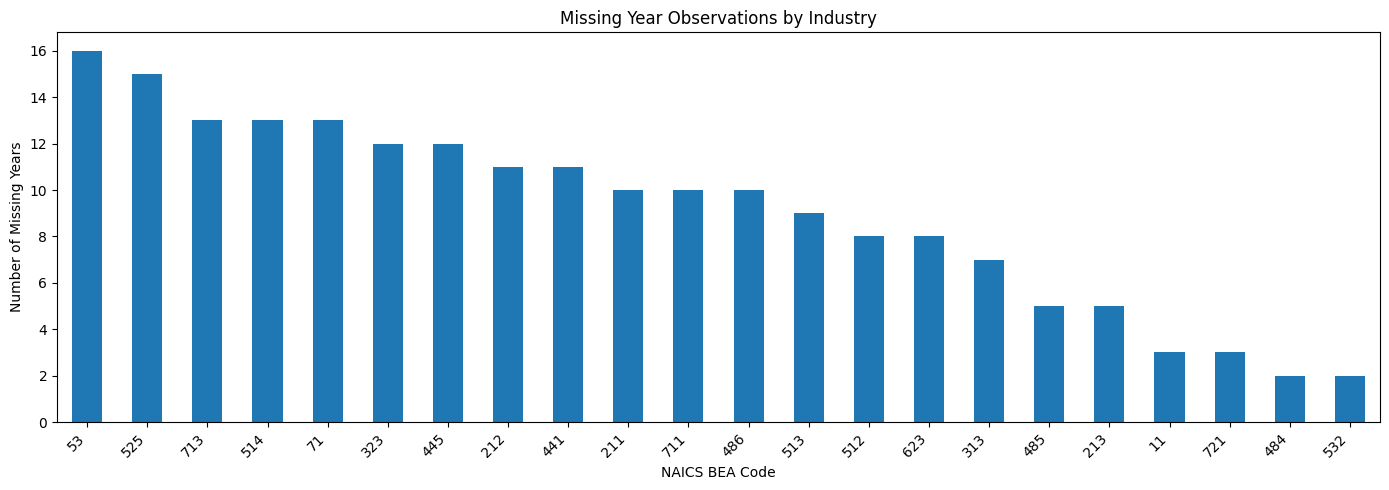

In [47]:
# Checking distribution of NaN values over industry to see whether industries need to be dropped for lack of data or imputed for some values
import matplotlib.pyplot as plt

# Full grid of all naics_bea x fiscal_year combinations
full_grid = pd.MultiIndex.from_product(
    [spendby_naicsyear['naics_bea'].unique(), spendby_naicsyear['fiscal_year'].unique()],
    names=['naics_bea', 'fiscal_year']
).to_frame(index=False)

# Find missing combinations
missing_cells = full_grid.merge(spendby_naicsyear, on=['naics_bea', 'fiscal_year'], how='left')
missing_cells = missing_cells[missing_cells['Transaction Amount'].isna()]

print(f"Missing industry x year cells: {len(missing_cells)}")
print(missing_cells.groupby('naics_bea').size().reset_index(name='missing_years'))

missing_by_industry = (
    missing_cells
    .groupby('naics_bea')
    .size()
    .reset_index(name='missing_years')
    .sort_values('missing_years', ascending=False)
)

missing_by_industry.plot(
    kind='bar',
    x='naics_bea',
    y='missing_years',
    figsize=(14, 5),
    legend=False,
    title='Missing Year Observations by Industry'
)
plt.xlabel('NAICS BEA Code')
plt.ylabel('Number of Missing Years')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Will handle missing NaN values at imputation step once combined with BEA data that has richer background characteristics

relevant data moving forward

**spendby_naicsyear: total contract spend by naics x year**

##### Generating US Government spend by naics code and agency

In [49]:
print(df['Awarding Agency'].nunique())
print(df['Awarding Agency'].unique())

43
['Department of Defense' 'Department of Energy'
 'Department of Health and Human Services'
 'National Aeronautics and Space Administration'
 'General Services Administration' 'Department of Veterans Affairs'
 'Department of the Interior' 'Department of Justice'
 'Department of State' 'Department of Homeland Security'
 'Agency for International Development' 'Department of Commerce'
 'Department of Labor' 'Department of Education'
 'Department of Transportation' 'Social Security Administration'
 'Department of Housing and Urban Development'
 'National Science Foundation' 'Environmental Protection Agency'
 'Department of Agriculture' 'Department of the Treasury'
 'Office of Personnel Management'
 'National Archives and Records Administration'
 'Federal Communications Commission' 'Smithsonian Institution'
 'Nuclear Regulatory Commission' 'Securities and Exchange Commission'
 'Pension Benefit Guaranty Corporation'
 'Corporation for National and Community Service'
 'National Gallery of Ar

In [55]:
# Collapsing Transaction Amount data to Agency Name x naics_code level
spendby_agencyindustry = (
    df[['naics_bea', 'Awarding Agency', 'Transaction Amount']]
    .groupby(['naics_bea', 'Awarding Agency'])['Transaction Amount']
    .sum()
    .reset_index()
    .fillna(0)
)

print(spendby_agencyindustry.shape)
print(spendby_agencyindustry.isna().sum())
spendby_agencyindustry.head()
spendby_agencyindustry.pivot(index='naics_bea', columns='Awarding Agency', values='Transaction Amount')

(616, 3)
naics_bea             0
Awarding Agency       0
Transaction Amount    0
dtype: int64


Awarding Agency,Agency for International Development,Commodity Futures Trading Commission,Consumer Financial Protection Bureau,Corporation for National and Community Service,Court Services and Offender Supervision Agency,Department of Agriculture,Department of Commerce,Department of Defense,Department of Education,Department of Energy,...,Nuclear Regulatory Commission,Office of Personnel Management,Peace Corps,Pension Benefit Guaranty Corporation,Securities and Exchange Commission,Small Business Administration,Smithsonian Institution,Social Security Administration,U.S. Agency for Global Media,U.S. International Development Finance Corporation
naics_bea,,,,,,,,,,,,,,,,,,,,,
11,3.095700e+07,NaN,NaN,NaN,NaN,6.501926e+08,NaN,1.783380e+07,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
211,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.920962e+08,NaN,1.103357e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.654456e+08,NaN,6.882445e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.254171e+08,NaN,5.527707e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,4.283760e+08,NaN,NaN,NaN,NaN,NaN,75120657.84,6.793136e+09,NaN,7.075655e+08,...,NaN,NaN,NaN,NaN,NaN,NaN,63261511.24,70175709.24,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
711,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.786504e+08,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.975598e+06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
721,NaN,NaN,NaN,NaN,NaN,NaN,13951251.59,1.711274e+08,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
spendby_agencyindustry['agency_industry_ratio'] = (
    spendby_agencyindustry.groupby('Awarding Agency')['Transaction Amount']
    .transform(lambda x: x / x.sum())
)

print(spendby_agencyindustry.head())

  naics_bea                          Awarding Agency  Transaction Amount  \
0        11     Agency for International Development        3.095700e+07   
1        11                Department of Agriculture        6.501926e+08   
2        11                    Department of Defense        1.783380e+07   
3        11  Department of Health and Human Services        5.362660e+07   
4        11               Department of the Interior        4.802012e+07   

   agency_industry_ratio  
0               0.000655  
1               0.023624  
2               0.000004  
3               0.000218  
4               0.001960  


In [57]:
spendby_agencyindustry.to_csv(working_folder + '/spendby_agencyindustry.csv', index=False)

relevant data moving forward

**spendby_agencyindustry: average percentage of an agency's spend that goes towards a certain industry (over 2008-2016 total contracts)**

### Combining the two datasets by NAICS and Year

USASpending contract data: spendby_naicsyear

BEA Panel Data (real value added, real gross output, employment, employment growth, va growth): bea_panel_clean


In [116]:
# Generating 2 more year lags for value added data

bea_panel_clean = (
    bea_panel_clean
    .drop(columns=['naics_code', 'value_added_real_m', 'gross_output_real_m', 'employment_k'])
    .rename(columns={'naics_clean': 'naics'})
)

# Sort to ensure lags are computed correctly
bea_panel_clean = bea_panel_clean.sort_values(['naics', 'year'])

# Generate 2 and 3 year lags
bea_panel_clean['value_added_real_m_lag2'] = (
    bea_panel_clean.groupby('naics')['value_added_real_m_lag1']
    .shift(1)
)

bea_panel_clean['value_added_real_m_lag3'] = (
    bea_panel_clean.groupby('naics')['value_added_real_m_lag1']
    .shift(2)
)

print(bea_panel_clean.columns.tolist())
print(bea_panel_clean.head())

['industry', 'year', 'value_added_real', 'gross_output_real', 'employment', 'value_added_real_m_lag1', 'va_growth', 'emp_growth', 'naics', 'value_added_real_m_lag2', 'value_added_real_m_lag3']
                                      industry  year  value_added_real  \
0  Agriculture, forestry, fishing, and hunting  1997       113200000.0   
1  Agriculture, forestry, fishing, and hunting  1998       111700000.0   
2  Agriculture, forestry, fishing, and hunting  1999       114400000.0   
3  Agriculture, forestry, fishing, and hunting  2000       129900000.0   
4  Agriculture, forestry, fishing, and hunting  2001       127100000.0   

   gross_output_real  employment  value_added_real_m_lag1  va_growth  \
0        357100000.0     95945.0                      NaN        NaN   
1        364900000.0     90202.0                    113.2  -0.013251   
2        377200000.0     81581.0                    111.7   0.024172   
3        371600000.0     76156.0                    114.4   0.135490   
4 

In [117]:
# View a single industry to verify lags
test_industry = bea_panel_clean['naics'].unique()[0]

bea_panel_clean[bea_panel_clean['naics'] == test_industry][
    ['naics', 'year', 'value_added_real_m_lag1', 'value_added_real_m_lag2', 'value_added_real_m_lag3']
].sort_values('year')

,naics,year,value_added_real_m_lag1,value_added_real_m_lag2,value_added_real_m_lag3
0,11,1997,NaN,NaN,NaN
1,11,1998,113.2,NaN,NaN
2,11,1999,111.7,113.2,NaN
3,11,2000,114.4,111.7,113.2
4,11,2001,129.9,114.4,111.7
5,11,2002,127.1,129.9,114.4
6,11,2003,131.3,127.1,129.9
7,11,2004,141.5,131.3,127.1
8,11,2005,153.4,141.5,131.3
9,11,2006,159.6,153.4,141.5


In [118]:
# Drop rows outside spendby_naicsyear year range
year_min = spendby_naicsyear['fiscal_year'].min()
year_max = spendby_naicsyear['fiscal_year'].max()

bea_panel_clean = bea_panel_clean[
    bea_panel_clean['year'].between(year_min, year_max)
].copy()

print(f"\nbea_panel_clean rows after year filter: {len(bea_panel_clean)}")


bea_panel_clean rows after year filter: 1292


In [120]:
# Combining the datasets
# for spendby_naicsyear: naics_bea x fiscal_year
# for bea_panel_clean: naics x year

# Merge spendby_naicsyear onto bea_panel_clean
merged = bea_panel_clean.merge(
    spendby_naicsyear,
    left_on=['naics', 'year'],
    right_on=['naics_bea', 'fiscal_year'],
    how='left'
)

print(f"\nMerged shape: {merged.shape}")
print(f"bea_panel_clean shape: {bea_panel_clean.shape}")
print(f"Rows difference: {len(merged) - len(bea_panel_clean)}")
merged.head()


Merged shape: (1292, 14)
bea_panel_clean shape: (1292, 11)
Rows difference: 0


,industry,year,value_added_real,gross_output_real,employment,value_added_real_m_lag1,va_growth,emp_growth,naics,value_added_real_m_lag2,value_added_real_m_lag3,naics_bea,fiscal_year,Transaction Amount
0,"Agriculture, forestry, fishing, and hunting",2009,160000000.0,396600000.0,80831.0,144.1,0.110340,-0.205373,11,144.5,161.7,11,2009.0,19103916.66
1,"Agriculture, forestry, fishing, and hunting",2010,156000000.0,398300000.0,93454.0,160.0,-0.025000,0.156165,11,144.1,144.5,11,2010.0,8729886.63
2,"Agriculture, forestry, fishing, and hunting",2011,150200000.0,388900000.0,119746.0,156.0,-0.037179,0.281336,11,160.0,144.1,NaN,NaN,NaN
3,"Agriculture, forestry, fishing, and hunting",2012,145700000.0,390900000.0,123169.0,150.2,-0.029960,0.028586,11,156.0,160.0,11,2012.0,11499573.44
4,"Agriculture, forestry, fishing, and hunting",2013,160400000.0,405700000.0,134541.0,145.7,0.100892,0.092328,11,150.2,156.0,11,2013.0,7400000.00


In [121]:
# Rename columns: Transaction Amount to govspend
merged = merged.rename(columns={'Transaction Amount': 'govspend'})

In [122]:
merged.head()

,industry,year,value_added_real,gross_output_real,employment,value_added_real_m_lag1,va_growth,emp_growth,naics,value_added_real_m_lag2,value_added_real_m_lag3,naics_bea,fiscal_year,govspend
0,"Agriculture, forestry, fishing, and hunting",2009,160000000.0,396600000.0,80831.0,144.1,0.110340,-0.205373,11,144.5,161.7,11,2009.0,19103916.66
1,"Agriculture, forestry, fishing, and hunting",2010,156000000.0,398300000.0,93454.0,160.0,-0.025000,0.156165,11,144.1,144.5,11,2010.0,8729886.63
2,"Agriculture, forestry, fishing, and hunting",2011,150200000.0,388900000.0,119746.0,156.0,-0.037179,0.281336,11,160.0,144.1,NaN,NaN,NaN
3,"Agriculture, forestry, fishing, and hunting",2012,145700000.0,390900000.0,123169.0,150.2,-0.029960,0.028586,11,156.0,160.0,11,2012.0,11499573.44
4,"Agriculture, forestry, fishing, and hunting",2013,160400000.0,405700000.0,134541.0,145.7,0.100892,0.092328,11,150.2,156.0,11,2013.0,7400000.00


From before, noticed quite a few (not a lot to drop rows but not too little to just ignore) missing govspend data points. Decided to address this using imputation of missing data by interpolating within industry - smoothly fills gaps between known values without using the outcome variable or its correlates. This avoids biasing regression, introducing artificial persistence that could bias standard errors, or create a mechanical correlation between imputed govspend and value_added_real since they share common drivers; all of which would arise with other imputation methods.

In [123]:
# Imputing missing contract spend data within industry

# Flag interpolated rows before filling
merged['govspend_interpolated'] = merged['govspend'].isna().astype(int)

# Sort then interpolate
merged = merged.sort_values(['naics', 'year'])
merged['govspend'] = (
    merged.groupby('naics')['govspend']
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

print(f"Remaining missing govspend: {merged['govspend'].isna().sum()}")
print(f"Interpolated rows: {merged['govspend_interpolated'].sum()}")

Remaining missing govspend: 170
Interpolated rows: 368


In [124]:
merged = merged.drop(columns=['naics_bea', 'fiscal_year'])
merged.head(3)

,industry,year,value_added_real,gross_output_real,employment,value_added_real_m_lag1,va_growth,emp_growth,naics,value_added_real_m_lag2,value_added_real_m_lag3,govspend,govspend_interpolated
0,"Agriculture, forestry, fishing, and hunting",2009,160000000.0,396600000.0,80831.0,144.1,0.110340,-0.205373,11,144.5,161.7,1.910392e+07,0
1,"Agriculture, forestry, fishing, and hunting",2010,156000000.0,398300000.0,93454.0,160.0,-0.025000,0.156165,11,144.1,144.5,8.729887e+06,0
2,"Agriculture, forestry, fishing, and hunting",2011,150200000.0,388900000.0,119746.0,156.0,-0.037179,0.281336,11,160.0,144.1,1.011473e+07,1


Missing industry x year cells: 170


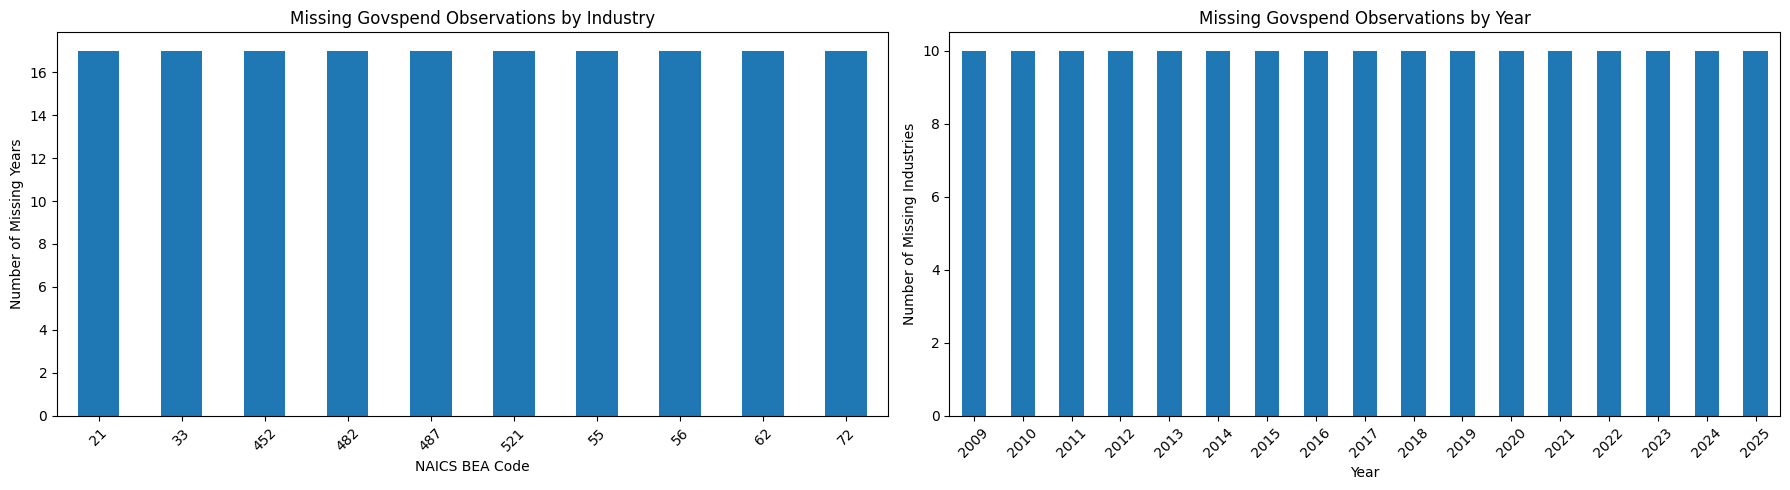

In [125]:
import matplotlib.pyplot as plt

# Full grid of all naics x year combinations
full_grid = pd.MultiIndex.from_product(
    [merged['naics'].unique(), merged['year'].unique()],
    names=['naics', 'year']
).to_frame(index=False)

# Find missing combinations
missing_cells = full_grid.merge(merged, on=['naics', 'year'], how='left')
missing_cells = missing_cells[missing_cells['govspend'].isna()]

print(f"Missing industry x year cells: {len(missing_cells)}")

# Distribution by industry
missing_by_industry = (
    missing_cells
    .groupby('naics')
    .size()
    .reset_index(name='missing_years')
    .sort_values('missing_years', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# By industry
missing_by_industry.plot(
    kind='bar',
    x='naics',
    y='missing_years',
    ax=axes[0],
    legend=False,
    title='Missing Govspend Observations by Industry'
)
axes[0].set_xlabel('NAICS BEA Code')
axes[0].set_ylabel('Number of Missing Years')
axes[0].tick_params(axis='x', rotation=45)

# By year
missing_by_year = (
    missing_cells
    .groupby('year')
    .size()
    .reset_index(name='missing_industries')
    .sort_values('year')
)

missing_by_year.plot(
    kind='bar',
    x='year',
    y='missing_industries',
    ax=axes[1],
    legend=False,
    title='Missing Govspend Observations by Year'
)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Missing Industries')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [126]:
# Check for duplicates
print(merged.duplicated(subset=['naics', 'year']).sum())

# Inspect them
print(merged[merged.duplicated(subset=['naics', 'year'], keep=False)][['naics', 'year', 'govspend', 'employment', 'va_growth']].sort_values(['naics', 'year']))

0
Empty DataFrame
Columns: [naics, year, govspend, employment, va_growth]
Index: []


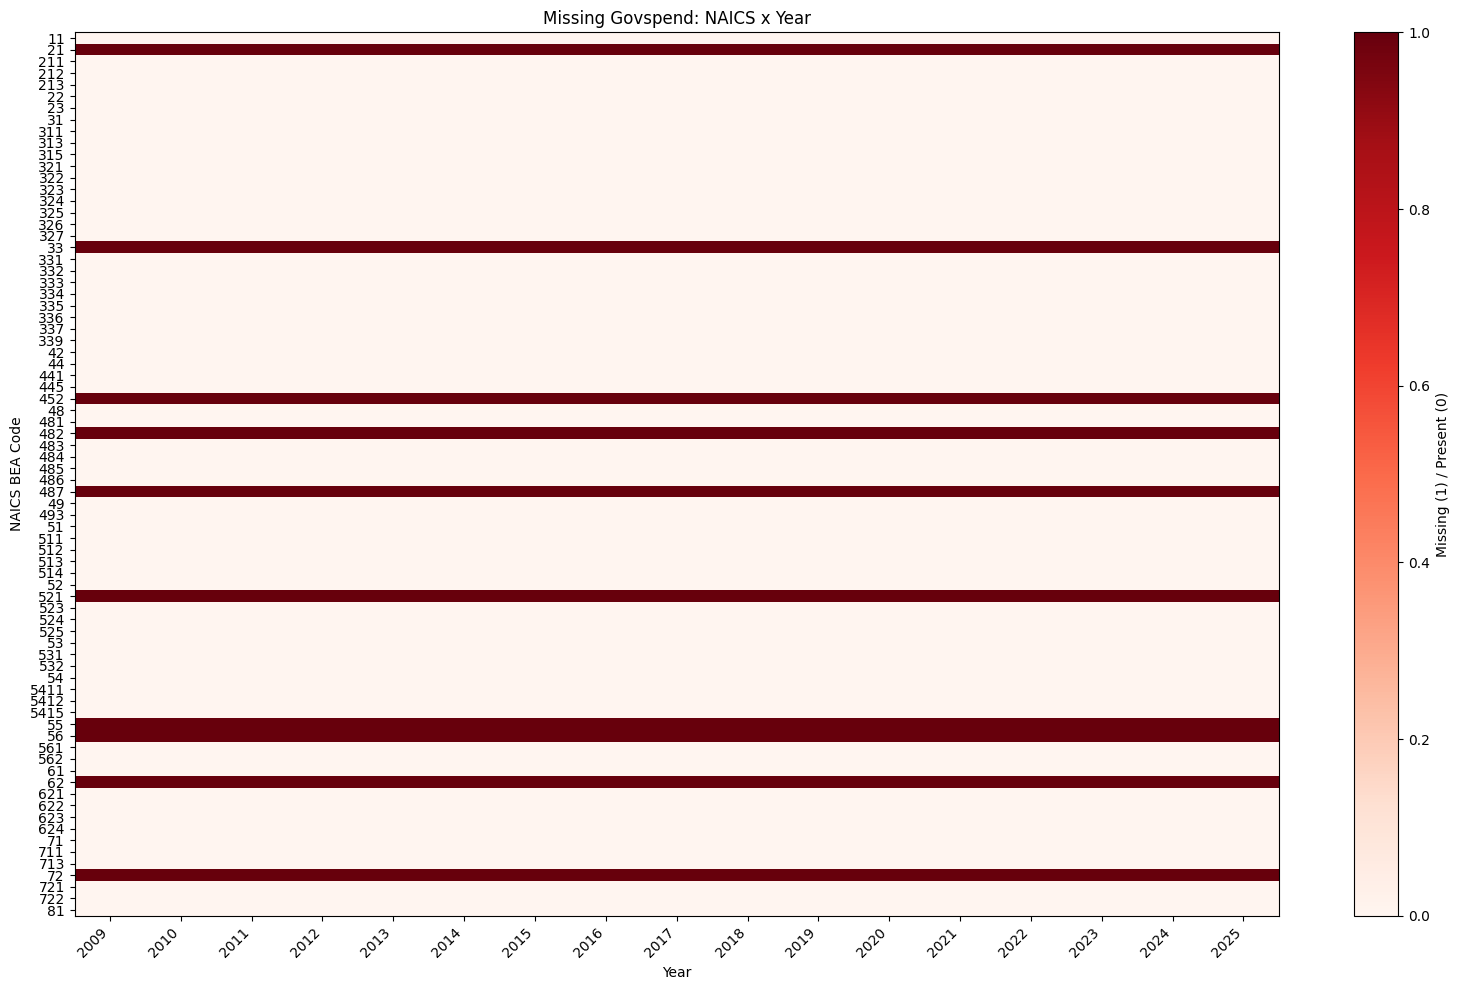

In [127]:
# Create pivot of missing values
missing_pivot = (
    merged.assign(missing=merged['govspend'].isna().astype(int))
    .pivot(index='naics', columns='year', values='missing')
)

plt.figure(figsize=(16, 10))
plt.imshow(missing_pivot, aspect='auto', cmap='Reds', interpolation='none')
plt.colorbar(label='Missing (1) / Present (0)')
plt.title('Missing Govspend: NAICS x Year')
plt.xlabel('Year')
plt.ylabel('NAICS BEA Code')
plt.xticks(range(len(missing_pivot.columns)), missing_pivot.columns, rotation=45, ha='right')
plt.yticks(range(len(missing_pivot.index)), missing_pivot.index)
plt.tight_layout()
plt.show()

In [128]:
# We notice that there are consistent gaps across certain industries, we treat these industries as never having received government investment and fill their NaN as 0
merged['govspendfull'] = merged['govspend'].fillna(0)

# verify
print(merged['govspendfull'].isna().sum())

0


govspendfull and govspend are the key columns, using govspend full moving forward as the fullest data rich variable

**Later we will test whether the regression results are robust to dropping interpolated observations**

In [129]:
# Creating variable of interest: intensity of contract investment 
merged['govspend_intensity'] = merged['govspendfull'] / merged['gross_output_real']

print(merged[['naics', 'year', 'govspendfull', 'gross_output_real', 'govspend_intensity']].head())

  naics  year  govspendfull  gross_output_real  govspend_intensity
0    11  2009  1.910392e+07        396600000.0            0.048169
1    11  2010  8.729887e+06        398300000.0            0.021918
2    11  2011  1.011473e+07        388900000.0            0.026009
3    11  2012  1.149957e+07        390900000.0            0.029418
4    11  2013  7.400000e+06        405700000.0            0.018240


In [152]:
# fixing mistake in lead vs lag structure

# Drop lag columns
# merged = merged.drop(columns=['value_added_real_m_lag1', 'value_added_real_m_lag2', 'value_added_real_m_lag3'])

# Generate 1, 2, 3 year leads within industry
merged = merged.sort_values(['naics', 'year'])

for h in [1, 2, 3, 4, 5, 6, 7, 8, 9]:
    merged[f'va_lead{h}'] = (
        merged.groupby('naics')['value_added_real']
        .shift(-h)
    )

print(merged[['naics', 'year', 'value_added_real', 'va_lead1', 'va_lead2', 'va_lead3', 'va_lead4', 'va_lead5', 'va_lead6', 'va_lead7', 'va_lead8', 'va_lead9']].head(10))

  naics  year  value_added_real     va_lead1     va_lead2     va_lead3  \
0    11  2009       160000000.0  156000000.0  150200000.0  145700000.0   
1    11  2010       156000000.0  150200000.0  145700000.0  160400000.0   
2    11  2011       150200000.0  145700000.0  160400000.0  159000000.0   
3    11  2012       145700000.0  160400000.0  159000000.0  171600000.0   
4    11  2013       160400000.0  159000000.0  171600000.0  181500000.0   
5    11  2014       159000000.0  171600000.0  181500000.0  176800000.0   
6    11  2015       171600000.0  181500000.0  176800000.0  184100000.0   
7    11  2016       181500000.0  176800000.0  184100000.0  172500000.0   
8    11  2017       176800000.0  184100000.0  172500000.0  177900000.0   
9    11  2018       184100000.0  172500000.0  177900000.0  188900000.0   

      va_lead4     va_lead5     va_lead6     va_lead7     va_lead8  \
0  160400000.0  159000000.0  171600000.0  181500000.0  176800000.0   
1  159000000.0  171600000.0  181500000.0  176

In [166]:
for h in [1, 2, 3, 4, 5, 6, 7, 8, 9]:
    merged[f'go_lead{h}'] = (
        merged.groupby('naics')['gross_output_real']
        .shift(-h)
    )

In [167]:
# Saving final gov-econ_data
merged.to_csv(working_folder + '/gov-econ_data.csv', index=False)

### Additional Data

##### CBP County Business Patterns 2023 from: https://www.census.gov/programs-surveys/cbp.html

County Business Patterns (CBP) is an annual series that provides subnational economic data for establishments with paid employees by industry and employment size. This series includes the number of establishments, employment during the week of March 12, first quarter payroll, and annual payroll.

FIPSTATE        C       FIPS State Code

NAICS           C       Industry Code - 6-digit NAICS code.

EMP             N       Total Mid-March Employees with Noise

EST             N       Total Number of Establishments

In [73]:
import pandas as pd

# Before this you need to download the CBP data from CBP, put the zip file into the project folder and unzip to the same folder
# Loading CBP data

all_CBP = working_folder + "/cbp23st/cbp23st.txt"

statedf_raw = pd.read_csv(all_CBP, sep=',')

In [74]:
# Keeping necessary columns from CBP

KEEP_COL = ["fipstate", "naics", "emp", "est"]

statedf = statedf_raw[KEEP_COL].copy()
print(statedf.shape)
statedf.head(5)

(348204, 4)


,fipstate,naics,emp,est
0,1,------,1822666,105720
1,1,------,820308,27410
2,1,------,524012,45474
3,1,------,74987,10428
4,1,------,207102,12597


In [75]:
# Matching state level employee and establishment data to bea panel data

unique_state_naics = statedf['naics'].dropna().unique()

state_naics_mapping = {
    code: match_naics(str(code), bea_codes_set)
    for code in unique_state_naics
}

# Summary
matched = {k: v for k, v in state_naics_mapping.items() if v is not None}
unmatched = {k: v for k, v in state_naics_mapping.items() if v is None}

print(f"Total unique state NAICS codes: {len(state_naics_mapping)}")
print(f"Matched: {len(matched)}")
print(f"Unmatched: {len(unmatched)}")
print(f"\nUnmatched codes: {list(unmatched.keys())}")

# Apply mapping and drop unmatched
statedf['naics_bea'] = statedf['naics'].map(state_naics_mapping)
statedf = statedf[statedf['naics_bea'].notna()].copy()

print(f"\nRows after dropping unmatched: {len(statedf)}")

Total unique state NAICS codes: 2001
Matched: 1951
Unmatched: 50

Unmatched codes: ['------', '451///', '4511//', '45111/', '451110', '45112/', '451120', '45113/', '451130', '45114/', '451140', '4512//', '45121/', '451211', '453///', '4531//', '45311/', '453110', '4532//', '45321/', '453210', '45322/', '453220', '4533//', '45331/', '453310', '4539//', '45391/', '453910', '45392/', '453920', '45393/', '453930', '45399/', '453991', '453998', '454///', '4541//', '45411/', '454110', '4542//', '45421/', '454210', '4543//', '45431/', '454310', '45439/', '454390', '99----', '451212']

Rows after dropping unmatched: 335242


In [76]:
# Get proportion mapping between naics and states

statedf['est_ratio'] = (
    statedf.groupby('naics_bea')['est']
    .transform(lambda x: x / x.sum())
)

statedf['emp_ratio'] = (
    statedf.groupby('naics_bea')['emp']
    .transform(lambda x: x / x.sum())
)

print(statedf[['fipstate', 'naics_bea', 'est', 'est_ratio', 'emp', 'emp_ratio']].head())

    fipstate naics_bea  est  est_ratio   emp  emp_ratio
8          1        11  726   0.003234  5548   0.003487
9          1        11  110   0.000490   978   0.000615
10         1        11  358   0.001595  3001   0.001886
11         1        11  135   0.000601   474   0.000298
12         1        11  115   0.000512  1054   0.000662


Mapping Between State FIP and State Name

https://www2.census.gov/programs-surveys/cbp/technical-documentation/reference/state-county-geography-reference/georef22.txt

In [67]:
import pandas as pd

geo_ref = pd.read_csv(
    'https://www2.census.gov/programs-surveys/cbp/technical-documentation/reference/state-county-geography-reference/georef22.txt',
    sep=',',
    encoding='latin-1'
)

print(geo_ref.head())
print(geo_ref.columns.tolist())

   fipstate  fipscty              county_name
0         1        1  Autauga County, Alabama
1         1        3  Baldwin County, Alabama
2         1        5  Barbour County, Alabama
3         1        7     Bibb County, Alabama
4         1        9   Blount County, Alabama
['fipstate', 'fipscty', 'county_name']


In [77]:
geo_ref['stname'] = geo_ref['county_name'].str.split(',').str[-1].str.strip()

fips_to_state = (
    geo_ref[['fipstate', 'stname']]
    .drop_duplicates()
    .set_index('fipstate')['stname']
    .to_dict()
)

statedf['state_name'] = statedf['fipstate'].map(fips_to_state)

print(statedf[['fipstate', 'state_name']].drop_duplicates())

        fipstate            state_name
8              1               Alabama
7109           2                Alaska
11568          4               Arizona
19069          5              Arkansas
25262          6            California
35295          8              Colorado
42861          9           Connecticut
49652         10              Delaware
54535         11  District of Columbia
58037         12               Florida
67191         13               Georgia
75516         15                Hawaii
80238         16                 Idaho
86267         17              Illinois
94916         18               Indiana
102492        19                  Iowa
108966        20                Kansas
115398        21              Kentucky
122326        22             Louisiana
129282        23                 Maine
134700        24              Maryland
141853        25         Massachusetts
149488        26              Michigan
157900        27             Minnesota
165574        28         

In [78]:
print(statedf.head())

    fipstate   naics   emp  est naics_bea  est_ratio  emp_ratio state_name
8          1  11----  5548  726        11   0.003234   0.003487    Alabama
9          1  11----   978  110        11   0.000490   0.000615    Alabama
10         1  11----  3001  358        11   0.001595   0.001886    Alabama
11         1  11----   474  135        11   0.000601   0.000298    Alabama
12         1  11----  1054  115        11   0.000512   0.000662    Alabama


In [79]:
statedf = (
    statedf
    .drop(columns=['fipstate', 'naics'])
    .rename(columns={'state_name': 'state'})
)

print(statedf.head())

     emp  est naics_bea  est_ratio  emp_ratio    state
8   5548  726        11   0.003234   0.003487  Alabama
9    978  110        11   0.000490   0.000615  Alabama
10  3001  358        11   0.001595   0.001886  Alabama
11   474  135        11   0.000601   0.000298  Alabama
12  1054  115        11   0.000512   0.000662  Alabama


In [80]:
print(statedf.groupby('naics_bea')['est_ratio'].sum())
print(statedf.groupby('naics_bea')['emp_ratio'].sum())

naics_bea
11     1.0
21     1.0
211    1.0
212    1.0
213    1.0
      ... 
713    1.0
72     1.0
721    1.0
722    1.0
81     1.0
Name: est_ratio, Length: 72, dtype: float64
naics_bea
11     1.0
21     1.0
211    1.0
212    1.0
213    1.0
      ... 
713    1.0
72     1.0
721    1.0
722    1.0
81     1.0
Name: emp_ratio, Length: 72, dtype: float64


In [82]:
statedf.to_csv(working_folder + '/est-emp_byindustrystate.csv', index=False)

data to keep moving forward:

**statedf or 'est-emp_byindustrystate.csv': is the ratio of an industry's presence in each state for number of employees and establishments**

# (2) Predictions: TWFE Regression and Linear Regression

### Necessary Files

In [168]:
# gov-econ_data.csv
paneldata = pd.read_csv(working_folder + '/gov-econ_data.csv')

In [138]:
# packages to install
!pip install linearmodels

  Obtaining dependency information for linearmodels from https://files.pythonhosted.org/packages/ff/b4/07bfbe879d029d42dbcf9a66693bc21ed702dc0368d01394ceefeb10c1ce/linearmodels-7.0-cp310-cp310-win_amd64.whl.metadata
  Obtaining dependency information for statsmodels>=0.13.0 from https://files.pythonhosted.org/packages/9a/1c/2e10b7c7cc44fa418272996bf0427b8016718fd62f995d9c1f7ab37adf35/statsmodels-0.14.6-cp310-cp310-win_amd64.whl.metadata
  Obtaining dependency information for mypy_extensions>=0.4 from https://files.pythonhosted.org/packages/79/7b/2c79738432f5c924bef5071f933bcc9efd0473bac3b4aa584a6f7c1c8df8/mypy_extensions-1.1.0-py3-none-any.whl.metadata
  Obtaining dependency information for pyhdfe>=0.1 from https://files.pythonhosted.org/packages/2f/51/cb006fbc08c32f161035fb19ca718250eb5f6d0692ea6dcc1e62c3e556a2/pyhdfe-0.2.0-py3-none-any.whl.metadata
  Obtaining dependency information for formulaic>=1.2.1 from https://files.pythonhosted.org/packages/1a/9d/c2c8b51b32f829a16fe042db30ad1d

### TWFE Regression for All Industries

In [145]:
paneldata.head(3)

,industry,year,value_added_real,gross_output_real,employment,va_growth,emp_growth,naics,govspend,govspend_interpolated,govspendfull,govspend_intensity,va_lead1,va_lead2,va_lead3,va_lead4,va_lead5
0,"Agriculture, forestry, fishing, and hunting",2009,160000000.0,396600000.0,80831.0,0.110340,-0.205373,11,1.910392e+07,0,1.910392e+07,0.048169,156000000.0,150200000.0,145700000.0,160400000.0,159000000.0
1,"Agriculture, forestry, fishing, and hunting",2010,156000000.0,398300000.0,93454.0,-0.025000,0.156165,11,8.729887e+06,0,8.729887e+06,0.021918,150200000.0,145700000.0,160400000.0,159000000.0,171600000.0
2,"Agriculture, forestry, fishing, and hunting",2011,150200000.0,388900000.0,119746.0,-0.037179,0.281336,11,1.011473e+07,1,1.011473e+07,0.026009,145700000.0,160400000.0,159000000.0,171600000.0,181500000.0



h = 0 | outcome: value_added_real
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
govspend_intensity -3.059e+05  1.696e+05    -1.8038     0.0715  -6.386e+05   2.681e+04
emp_growth         -1.496e+07  6.968e+06    -2.1478     0.0319  -2.864e+07  -1.295e+06
va_growth          -6.979e+05  6.232e+05    -1.1198     0.2630   -1.92e+06   5.248e+05

h = 1 | outcome: va_lead1
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
govspend_intensity -2.329e+05  1.452e+05    -1.6037     0.1091  -5.179e+05   5.206e+04
emp_growth         -1.847e+07  7.677e+06    -2.4059     0.0163  -3.3

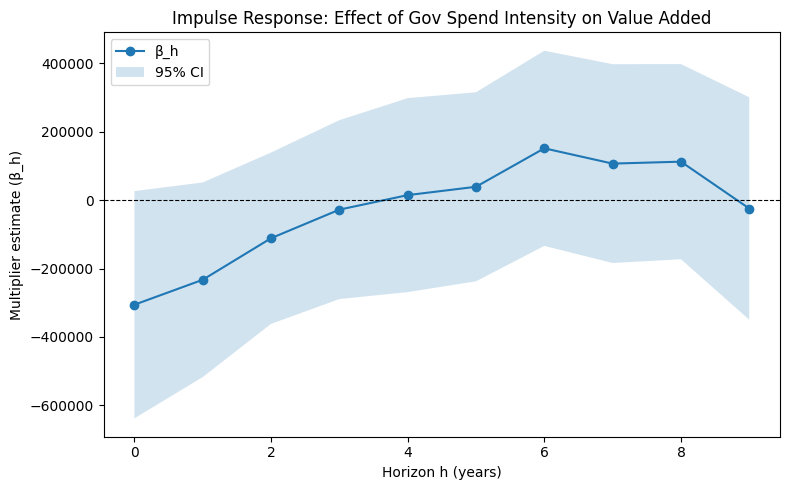

In [155]:
import numpy as np
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt

# Set up panel index
paneldata = paneldata.set_index(['naics', 'year'])

# Map horizon to existing lag columns
outcome_cols = {
    0: 'value_added_real',
    1: 'va_lead1',
    2: 'va_lead2',
    3: 'va_lead3',
    4: 'va_lead4',
    5: 'va_lead5', 
    6: 'va_lead6', 
    7: 'va_lead7', 
    8: 'va_lead8', 
    9: 'va_lead9'
}

results = {}

for h, outcome_col in outcome_cols.items():
    reg_df = paneldata.dropna(subset=[outcome_col, 'govspend_intensity', 'emp_growth', 'va_growth'])
    
    model = PanelOLS(
        dependent=reg_df[outcome_col],
        exog=reg_df[['govspend_intensity', 'emp_growth', 'va_growth']],
        entity_effects=True,
        time_effects=True
    )
    
    res = model.fit(cov_type='clustered', cluster_entity=True)
    results[h] = {
        'beta': res.params['govspend_intensity'],
        'ci_low': res.params['govspend_intensity'] - 1.96 * res.std_errors['govspend_intensity'],
        'ci_high': res.params['govspend_intensity'] + 1.96 * res.std_errors['govspend_intensity']
    }
    
    print(f"\nh = {h} | outcome: {outcome_col}")
    print(res.summary.tables[1])

# Plot impulse response
horizons = list(results.keys())
betas = [results[h]['beta'] for h in horizons]
ci_low = [results[h]['ci_low'] for h in horizons]
ci_high = [results[h]['ci_high'] for h in horizons]

plt.figure(figsize=(8, 5))
plt.plot(horizons, betas, marker='o', label='β_h')
plt.fill_between(horizons, ci_low, ci_high, alpha=0.2, label='95% CI')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Horizon h (years)')
plt.ylabel('Multiplier estimate (β_h)')
plt.title('Impulse Response: Effect of Gov Spend Intensity on Value Added')
plt.legend()
plt.tight_layout()
plt.show()


h = 0 | outcome: gross_output_real
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
govspend_intensity -7.884e+05    3.1e+05    -2.5434     0.0111  -1.396e+06  -1.802e+05
emp_growth         -1.473e+07  4.863e+06    -3.0295     0.0025  -2.427e+07  -5.192e+06
va_growth          -1.318e+06  8.991e+05    -1.4662     0.1429  -3.082e+06   4.458e+05

h = 1 | outcome: go_lead1
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
govspend_intensity -6.601e+05   2.79e+05    -2.3658     0.0182  -1.208e+06  -1.127e+05
emp_growth         -1.621e+07   5.56e+06    -2.9162     0.0036  -2.

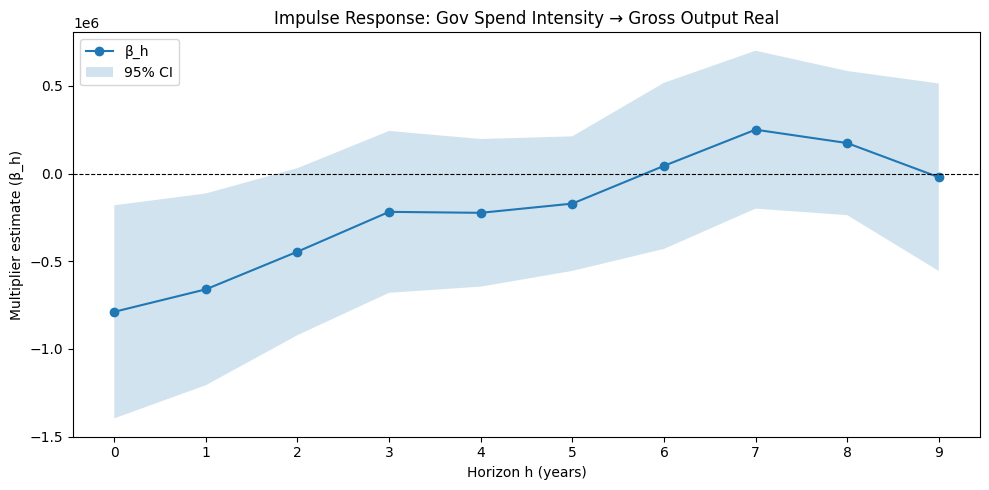

In [156]:
# Generate gross output leads up to 9
paneldata = paneldata.sort_values(['naics', 'year'])
for h in range(1, 10):
    paneldata[f'go_lead{h}'] = (
        paneldata.groupby('naics')['gross_output_real']
        .shift(-h)
    )

go_outcome_cols = {h: f'go_lead{h}' if h > 0 else 'gross_output_real' for h in range(10)}

results_go = {}

for h, outcome_col in go_outcome_cols.items():
    reg_df = paneldata.dropna(subset=[outcome_col, 'govspend_intensity', 'emp_growth', 'va_growth'])

    model = PanelOLS(
        dependent=reg_df[outcome_col],
        exog=reg_df[['govspend_intensity', 'emp_growth', 'va_growth']],
        entity_effects=True,
        time_effects=True
    )

    res = model.fit(cov_type='clustered', cluster_entity=True)
    results_go[h] = {
        'beta': res.params['govspend_intensity'],
        'ci_low': res.params['govspend_intensity'] - 1.96 * res.std_errors['govspend_intensity'],
        'ci_high': res.params['govspend_intensity'] + 1.96 * res.std_errors['govspend_intensity']
    }

    print(f"\nh = {h} | outcome: {outcome_col}")
    print(res.summary.tables[1])

# Plot
horizons = list(results_go.keys())
betas = [results_go[h]['beta'] for h in horizons]
ci_low = [results_go[h]['ci_low'] for h in horizons]
ci_high = [results_go[h]['ci_high'] for h in horizons]

plt.figure(figsize=(10, 5))
plt.plot(horizons, betas, marker='o', label='β_h')
plt.fill_between(horizons, ci_low, ci_high, alpha=0.2, label='95% CI')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.xticks(horizons)
plt.xlabel('Horizon h (years)')
plt.ylabel('Multiplier estimate (β_h)')
plt.title('Impulse Response: Gov Spend Intensity → Gross Output Real')
plt.legend()
plt.tight_layout()
plt.show()


h = 0 | outcome: employment
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
govspend_intensity    -61.670     67.941    -0.9077     0.3642     -194.97      71.628
emp_growth          3.021e+04     2071.5     14.584     0.0000   2.615e+04   3.427e+04
va_growth          -1.592e+04     183.05    -86.970     0.0000  -1.628e+04  -1.556e+04

h = 1 | outcome: emp_lead1
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
govspend_intensity    -73.843     49.029    -1.5061     0.1323     -170.04      22.357
emp_growth          9.413e+04     5770.7     16.311     0.0000   8.281e+0

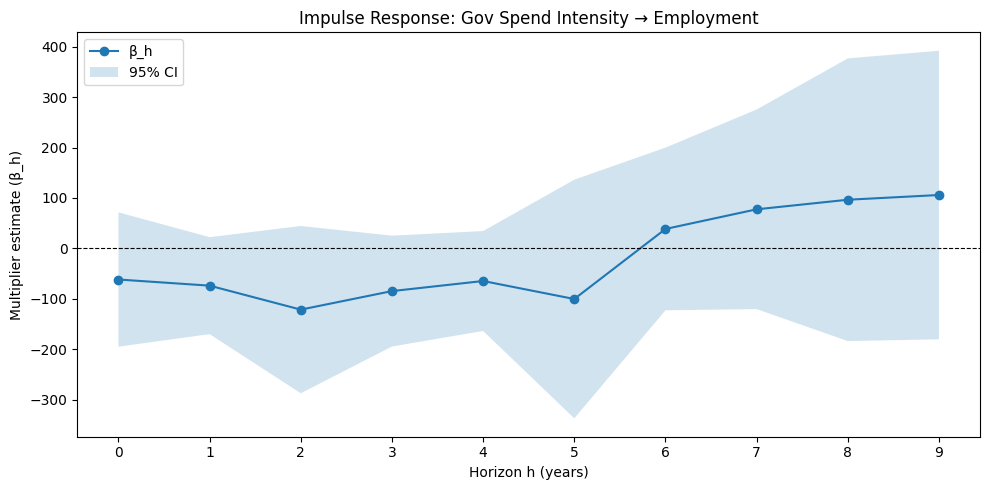

In [157]:
# Generate employment leads up to 9
paneldata = paneldata.sort_values(['naics', 'year'])
for h in range(1, 10):
    paneldata[f'emp_lead{h}'] = (
        paneldata.groupby('naics')['employment']
        .shift(-h)
    )

emp_outcome_cols = {h: f'emp_lead{h}' if h > 0 else 'employment' for h in range(10)}

results_emp = {}

for h, outcome_col in emp_outcome_cols.items():
    reg_df = paneldata.dropna(subset=[outcome_col, 'govspend_intensity', 'emp_growth', 'va_growth'])

    model = PanelOLS(
        dependent=reg_df[outcome_col],
        exog=reg_df[['govspend_intensity', 'emp_growth', 'va_growth']],
        entity_effects=True,
        time_effects=True
    )

    res = model.fit(cov_type='clustered', cluster_entity=True)
    results_emp[h] = {
        'beta': res.params['govspend_intensity'],
        'ci_low': res.params['govspend_intensity'] - 1.96 * res.std_errors['govspend_intensity'],
        'ci_high': res.params['govspend_intensity'] + 1.96 * res.std_errors['govspend_intensity']
    }

    print(f"\nh = {h} | outcome: {outcome_col}")
    print(res.summary.tables[1])

# Plot
horizons = list(results_emp.keys())
betas = [results_emp[h]['beta'] for h in horizons]
ci_low = [results_emp[h]['ci_low'] for h in horizons]
ci_high = [results_emp[h]['ci_high'] for h in horizons]

plt.figure(figsize=(10, 5))
plt.plot(horizons, betas, marker='o', label='β_h')
plt.fill_between(horizons, ci_low, ci_high, alpha=0.2, label='95% CI')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.xticks(horizons)
plt.xlabel('Horizon h (years)')
plt.ylabel('Multiplier estimate (β_h)')
plt.title('Impulse Response: Gov Spend Intensity → Employment')
plt.legend()
plt.tight_layout()
plt.show()

### Hierarchical Mixed Effects Model with Empirical Bayes

In [159]:
# =============================================================================
# INDUSTRY-SPECIFIC MULTIPLIER ESTIMATION: HIERARCHICAL MIXED EFFECTS MODEL
# =============================================================================
#
# We estimate industry-specific government spending multipliers using a
# hierarchical linear mixed effects model. Rather than running separate
# regressions per industry (which yields noisy estimates given ~15 years of
# data per sector) or a pooled TWFE (which assumes a single multiplier for
# all industries), we specify a model where each industry's multiplier is
# drawn from a common distribution. This partial pooling shrinks noisy
# industry estimates toward the global mean — industries with more data and
# cleaner signals retain more of their idiosyncratic estimate, while data-
# sparse industries are regularized toward the cross-industry average.
#
# The model is:
#   y_{i,t+h} = (β + u_i) · govspend_intensity_{i,t} + γ · X_{i,t} + α_t + ε_{i,t}
#
# where:
#   β        = population-level (fixed) effect of govspend_intensity
#   u_i      = industry-specific random slope ~ N(0, σ²_u)
#   X_{i,t}  = time-varying controls: emp_growth, va_growth
#   α_t      = year fixed effects (demeaned)
#
# The industry-specific multiplier at horizon h is recovered as β + u_i.
# Standard errors on u_i reflect the precision of each industry's estimate.
# =============================================================================

import statsmodels.formula.api as smf
import pandas as pd
import matplotlib.pyplot as plt

h = 6  # horizon of interest as best horizon for effect from general TWFE model for all industries
outcome_col = f'va_lead{h}'

# Year-demean to approximate year fixed effects (mixedlm does not support FE directly)
reg_df = paneldata.reset_index().dropna(subset=[outcome_col, 'govspend_intensity', 'emp_growth', 'va_growth'])
reg_df['year_mean'] = reg_df.groupby('year')[outcome_col].transform('mean')
reg_df[f'{outcome_col}_dm'] = reg_df[outcome_col] - reg_df['year_mean']

# Fit hierarchical model with random slope on govspend_intensity
model = smf.mixedlm(
    f"{outcome_col}_dm ~ govspend_intensity + emp_growth + va_growth",
    data=reg_df,
    groups=reg_df['naics'],
    re_formula="~govspend_intensity"
)
res = model.fit(reml=True)
print(res.summary())

# Extract industry-specific multipliers: fixed effect + random slope
fixed_slope = res.params['govspend_intensity']
random_effects = res.random_effects

industry_multipliers = {
    naics: fixed_slope + re.get('govspend_intensity', 0)
    for naics, re in random_effects.items()
}

multiplier_df = (
    pd.DataFrame.from_dict(industry_multipliers, orient='index', columns=['multiplier'])
    .sort_values('multiplier', ascending=True)
    .reset_index()
    .rename(columns={'index': 'naics'})
)

print(f"\nPooled multiplier (β): {fixed_slope:.4f}")
print(multiplier_df)

                                    Mixed Linear Model Regression Results
Model:                          MixedLM               Dependent Variable:               va_lead6_dm          
No. Observations:               836                   Method:                           REML                 
No. Groups:                     76                    Scale:                            5343462948937609.0000
Min. group size:                11                    Log-Likelihood:                   -16518.0167          
Max. group size:                11                    Converged:                        Yes                  
Mean group size:                11.0                                                                         
-------------------------------------------------------------------------------------------------------------
                                       Coef.             Std.Err.     z    P>|z|     [0.025         0.975]   
----------------------------------------------

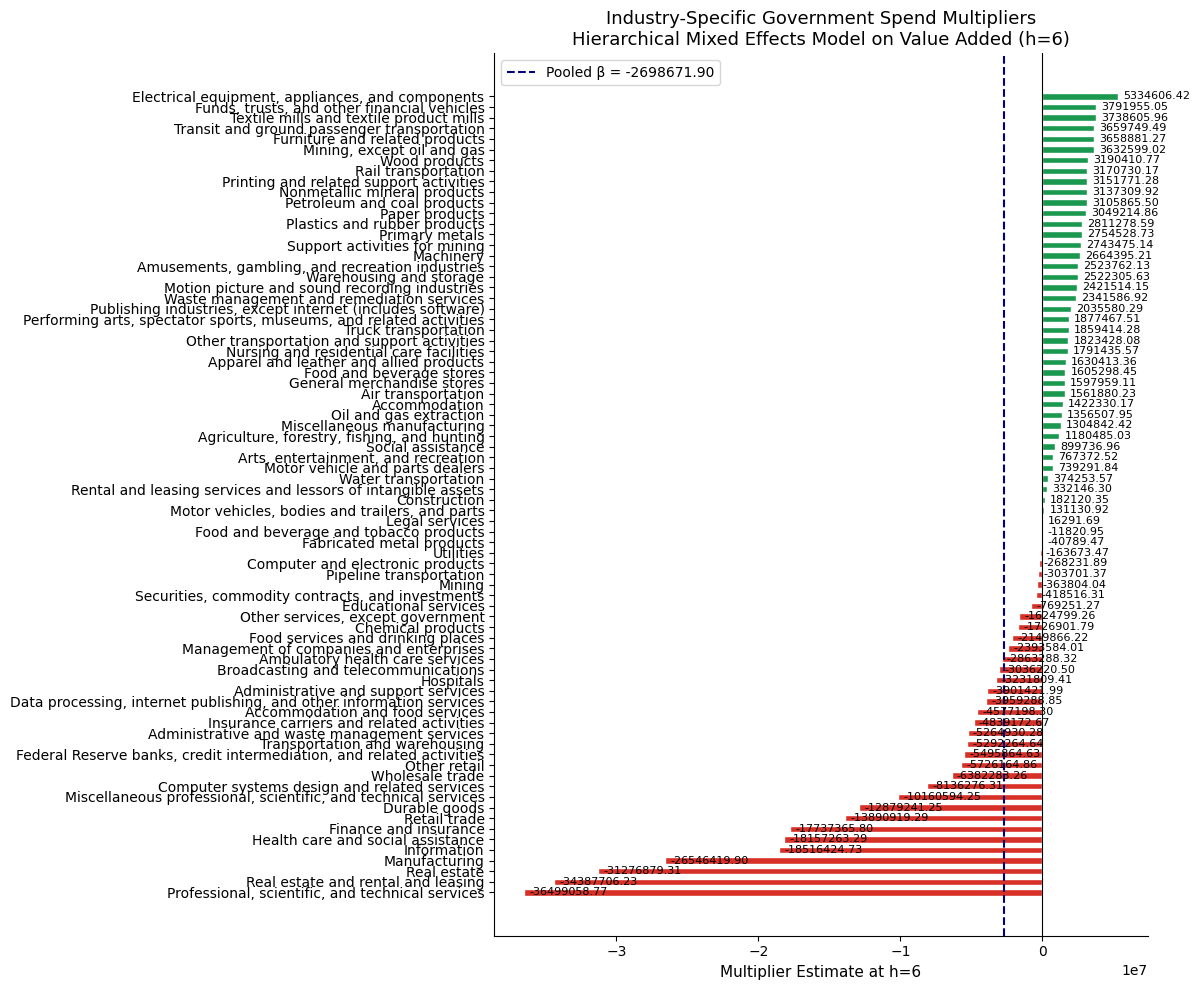

In [169]:
# Map naics codes to industry names
naics_to_industry = paneldata.reset_index()[['naics', 'industry']].drop_duplicates().set_index('naics')['industry'].to_dict()
multiplier_df['industry'] = multiplier_df['naics'].map(naics_to_industry)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

colors = ['#d73027' if x < 0 else '#1a9850' for x in multiplier_df['multiplier']]

bars = ax.barh(
    multiplier_df['industry'],
    multiplier_df['multiplier'],
    color=colors,
    edgecolor='white',
    height=0.6
)

# Add value labels
for bar, val in zip(bars, multiplier_df['multiplier']):
    ax.text(
        val + (0.01 * max(abs(multiplier_df['multiplier']))),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center',
        fontsize=8
    )

ax.axvline(fixed_slope, color='navy', linestyle='--', linewidth=1.5, label=f'Pooled β = {fixed_slope:.2f}')
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Multiplier Estimate at h=6', fontsize=11)
ax.set_title('Industry-Specific Government Spend Multipliers\nHierarchical Mixed Effects Model on Value Added (h=6)', fontsize=13)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [161]:
multipliers_by_naics = multiplier_df[['naics', 'multiplier']].set_index('naics')
print(multipliers_by_naics)

         multiplier
naics              
54    -3.649906e+07
53    -3.438771e+07
531   -3.127688e+07
31    -2.654642e+07
51    -1.851642e+07
...             ...
337    3.658881e+06
485    3.659749e+06
313    3.738606e+06
525    3.791955e+06
335    5.334606e+06

[76 rows x 1 columns]


In [162]:
multipliers_by_naics.to_csv(working_folder + '/govmultiple.csv')

In [170]:
import statsmodels.formula.api as smf
import pandas as pd
import matplotlib.pyplot as plt

h = 6  # horizon of interest as best horizon for effect from general TWFE model for all industries
outcome_col = f'go_lead{h}'

# Year-demean to approximate year fixed effects (mixedlm does not support FE directly)
reg_df = paneldata.reset_index().dropna(subset=[outcome_col, 'govspend_intensity', 'emp_growth', 'va_growth'])
reg_df['year_mean'] = reg_df.groupby('year')[outcome_col].transform('mean')
reg_df[f'{outcome_col}_dm'] = reg_df[outcome_col] - reg_df['year_mean']

# Fit hierarchical model with random slope on govspend_intensity
model = smf.mixedlm(
    f"{outcome_col}_dm ~ govspend_intensity + emp_growth + va_growth",
    data=reg_df,
    groups=reg_df['naics'],
    re_formula="~govspend_intensity"
)
res = model.fit(reml=True)
print(res.summary())

# Extract industry-specific multipliers: fixed effect + random slope
fixed_slope = res.params['govspend_intensity']
random_effects = res.random_effects

industry_multipliers = {
    naics: fixed_slope + re.get('govspend_intensity', 0)
    for naics, re in random_effects.items()
}

multiplier_df = (
    pd.DataFrame.from_dict(industry_multipliers, orient='index', columns=['multiplier'])
    .sort_values('multiplier', ascending=True)
    .reset_index()
    .rename(columns={'index': 'naics'})
)

print(f"\nPooled multiplier (β): {fixed_slope:.4f}")
print(multiplier_df)

                                     Mixed Linear Model Regression Results
Model:                           MixedLM               Dependent Variable:               go_lead6_dm           
No. Observations:                836                   Method:                           REML                  
No. Groups:                      76                    Scale:                            10596057734350050.0000
Min. group size:                 11                    Log-Likelihood:                   -16818.4036           
Max. group size:                 11                    Converged:                        Yes                   
Mean group size:                 11.0                                                                          
---------------------------------------------------------------------------------------------------------------
                                        Coef.             Std.Err.      z    P>|z|     [0.025         0.975]   
-----------------------------

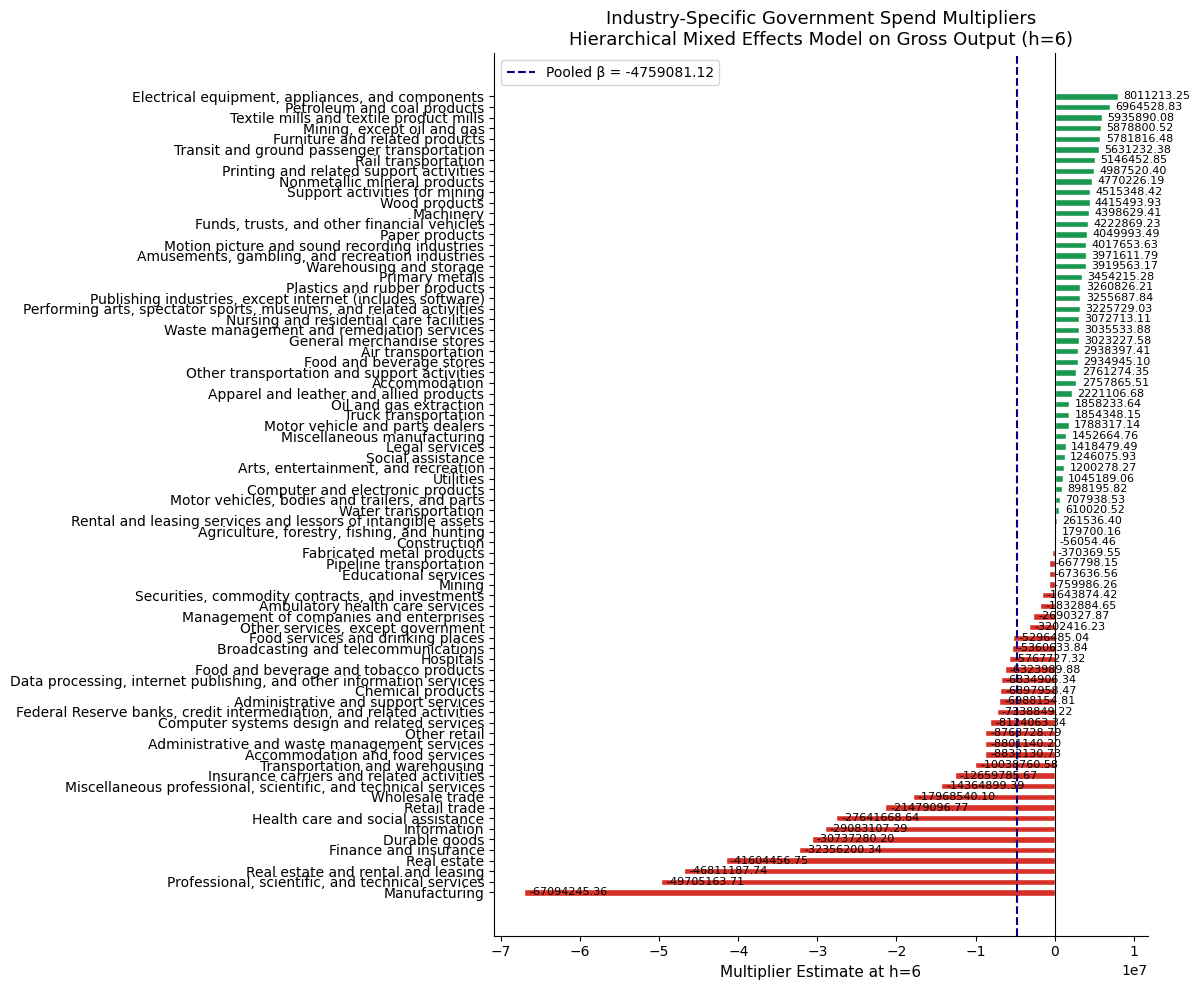

In [171]:
# Map naics codes to industry names
naics_to_industry = paneldata.reset_index()[['naics', 'industry']].drop_duplicates().set_index('naics')['industry'].to_dict()
multiplier_df['industry'] = multiplier_df['naics'].map(naics_to_industry)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

colors = ['#d73027' if x < 0 else '#1a9850' for x in multiplier_df['multiplier']]

bars = ax.barh(
    multiplier_df['industry'],
    multiplier_df['multiplier'],
    color=colors,
    edgecolor='white',
    height=0.6
)

# Add value labels
for bar, val in zip(bars, multiplier_df['multiplier']):
    ax.text(
        val + (0.01 * max(abs(multiplier_df['multiplier']))),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center',
        fontsize=8
    )

ax.axvline(fixed_slope, color='navy', linestyle='--', linewidth=1.5, label=f'Pooled β = {fixed_slope:.2f}')
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Multiplier Estimate at h=6', fontsize=11)
ax.set_title('Industry-Specific Government Spend Multipliers\nHierarchical Mixed Effects Model on Gross Output (h=6)', fontsize=13)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

important data to keep track of moving forward:

**govmultiple.csv has naics indexed empirical bayes calculated multiplier on govintensity for value_added 6 years from investment**

### Time Series ARIMA Regression for VA growth and Employee growth

In [172]:
paneldata = pd.read_csv(working_folder + '/gov-econ_data.csv')

ARIMA(1,0,1) is a reasonable default for growth rate series which are typically stationary - no differencing needed (d=0)

Meanwhile, gross_output_real is a level series rather than a growth rate, it may be non-stationary (trending upward over time) - want d=1 to difference it

In [173]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

forecasts = {}

# Differentiate order by variable
arima_order = {
    'emp_growth': (1, 0, 1),
    'va_growth': (1, 0, 1),
    'gross_output_real': (1, 1, 1)
}

for naics, group in paneldata.reset_index().groupby('naics'):
    group = group.sort_values('year').set_index('year')
    
    naics_forecasts = {}
    for var in ['emp_growth', 'va_growth', 'gross_output_real']:
        series = group[var].dropna()    

        if len(series) < 5:
            naics_forecasts[var] = None
            continue
        
        try:
            # Fit ARIMA(1,0,1) — appropriate for stationary growth rate series
            model = ARIMA(series, order=arima_order[var])
            res = model.fit()
            
            # Forecast 1 step ahead (2026)
            forecast = res.forecast(steps=1)
            naics_forecasts[var] = forecast.iloc[0]
        except:
            naics_forecasts[var] = None
    
    forecasts[naics] = naics_forecasts

# Convert to dataframe
forecast_df = (
    pd.DataFrame.from_dict(forecasts, orient='index')
    .reset_index()
    .rename(columns={'index': 'naics'})
)
forecast_df['year'] = 2026

print(forecast_df)

    naics  emp_growth  va_growth  gross_output_real  year
0      11    0.025591   0.030533       4.629192e+08  2026
1      21   -0.064234   0.002943       5.964613e+08  2026
2      22    0.014562   0.015076       5.284895e+08  2026
3      23    0.018697   0.010685       1.715925e+09  2026
4      31    0.000491   0.001118       5.594927e+09  2026
..    ...         ...        ...                ...   ...
71    721    0.038619  -0.009862       2.933241e+08  2026
72    722    0.063844   0.050046       9.941083e+08  2026
73   5411    0.082452  -0.003309       3.555220e+08  2026
74   5412    0.013067   0.036517       2.112042e+09  2026
75   5415   -0.027377   0.103787       9.115565e+08  2026

[76 rows x 5 columns]


In [174]:
forecast_df.to_csv(working_folder + '/growthpredictionsVAEMPGO26.csv', index=False)

important data to keep track of moving forward:

**growthpredictionsVAEMPGO26.csv has naics indexed va_growth, emp_growth, and gross_output_real predictions for 2026**

# (3) Optimization Models

### Necessary Files

In [ ]:
# industry presence in each state at "est-emp_byindustrystate.csv"
# agency spend ratio in each industry at "spendby_agencyindustry.csv"
# naics indexed va_growth, emp_growth, and gross_output_real predictions for 2026 at "growthpredictionsVAEMPGO26"
# naics indexed empirical bayes calculated multiplier on govintensity for value_added 6 years from investment at "govmultiple.csv"

Imports & data loading

In [ ]:
# Install & imports
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pulp", "-q"], check=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pulp

print("PuLP version:", pulp.__version__)
print("CBC available:", pulp.listSolvers(onlyAvailable=True))

PuLP version: 3.3.0
CBC available: ['GUROBI_CMD', 'PULP_CBC_CMD']


In [187]:
# Load & merge data
FOLDER = working_folder  # ← adjust if needed

emp_state  = pd.read_csv(f"{FOLDER}/est-emp_byindustrystate.csv")
govmult    = pd.read_csv(f"{FOLDER}/govmultiple.csv")
growth     = pd.read_csv(f"{FOLDER}/growthpredictionsVAEMPGO26.csv")
agency_raw = pd.read_csv(f"{FOLDER}/spendby_agencyindustry.csv")

# Master industry table (inner join on naics across all 4 files)
# govmultiple and growth use "naics"; emp and agency use "naics_bea"
master = (
    govmult
    .merge(growth[["naics","emp_growth","va_growth","gross_output_real"]],
           on="naics", how="inner")
    .merge(emp_state[["naics_bea"]].drop_duplicates().rename(columns={"naics_bea":"naics"}),
           on="naics", how="inner")
    .merge(agency_raw[["naics_bea"]].drop_duplicates().rename(columns={"naics_bea":"naics"}),
           on="naics", how="inner")
    .reset_index(drop=True)
)

INDUSTRIES  = master["naics"].tolist()
N           = len(INDUSTRIES)
naics_idx   = {n: i for i, n in enumerate(INDUSTRIES)}

mu  = master["multiplier"].values.copy()
GO  = master["gross_output_real"].values.copy()        # 2026 predicted gross output ($)
va_pos  = master["va_growth"].values > 0               # boolean filter
emp_pos = master["emp_growth"].values > 0              # boolean filter

BUDGET = 10e9   # $100 billion

print(f"{N} industries in master table")
print(f"Positive multipliers : {(mu>0).sum()}")
print(f"Positive VA growth   : {va_pos.sum()}")
print(f"Positive emp growth  : {emp_pos.sum()}")
print(f"Gross output range   : ${GO.min()/1e9:.2f}B – ${GO.max()/1e9:.2f}B")

64 industries in master table
Positive multipliers : 38
Positive VA growth   : 48
Positive emp growth  : 57
Gross output range   : $0.02B – $5.59B


In [188]:
# Cell 2 — State presence matrix
# emp_ratio[s,i] = fraction of industry i's national workforce in state s
# (already sums to 1.0 per naics_bea — confirmed)

state_pivot = (
    emp_state[emp_state["naics_bea"].isin(INDUSTRIES)]
    .pivot_table(index="state", columns="naics_bea",
                 values="emp_ratio", aggfunc="sum", fill_value=0)
    .reindex(columns=INDUSTRIES, fill_value=0)
)

STATES = state_pivot.index.tolist()
S      = len(STATES)
W      = state_pivot.values.astype(float)   # shape (S, N)
# Each column sums to 1 — W[s,i] = share of industry i's workforce in state s

# Equal share benchmark: if funding were proportional to workforce presence,
# each state would receive 1/S of total. We constrain the employment-weighted
# effective funding share per state to stay within [1/S - tol, 1/S + tol].
equal_share = 1.0 / S

print(f"{S} states | W shape: {W.shape}")
print(f"Column sums (first 5, should be ~1.0): {W.sum(axis=0)[:5].round(3)}")

51 states | W shape: (51, 64)
Column sums (first 5, should be ~1.0): [1. 1. 1. 1. 1.]


In [189]:
# Agency mix matrix
# agency_industry_ratio[k,i] = share of agency k's spend going to industry i
# (sums to 1.0 per agency — confirmed)

agency_pivot = (
    agency_raw[agency_raw["naics_bea"].isin(INDUSTRIES)]
    .pivot_table(index="Awarding Agency", columns="naics_bea",
                 values="agency_industry_ratio", aggfunc="sum", fill_value=0)
    .reindex(columns=INDUSTRIES, fill_value=0)
)

# Re-normalise rows to 1 (in case filtering dropped some industries)
row_sums = agency_pivot.sum(axis=1).replace(0, 1)
agency_pivot = agency_pivot.div(row_sums, axis=0)

AGENCIES = agency_pivot.index.tolist()
K        = len(AGENCIES)
P        = agency_pivot.values.astype(float)   # shape (K, N)
# P[k,i] = fraction of agency k's budget flowing to industry i
# industry allocation under agency model: a[i] = sum_k P[k,i] * b[k]

print(f"{K} agencies | P shape: {P.shape}")
print(f"Row sums (first 3, should be 1.0): {P.sum(axis=1)[:3].round(4)}")

43 agencies | P shape: (43, 64)
Row sums (first 3, should be 1.0): [1. 1. 1.]


Note: as expected have 43 agencies and 51 states, went from 73 industries to 64 industries during merge of BEA anchored codes and CBP data

In [190]:
# Cell 4 — National priority industries
# From Trump admin national security / industrial base reports.
# Covers: semiconductors, aerospace/defense manufacturing, steel, oil & gas extraction, and pharma/chemicals.

NATIONAL_PRIORITY_NAICS = [334, 336, 331, 211, 325]
# 334 = Computer & electronic products (semiconductors)
# 336 = Transportation equipment / aerospace-defense manufacturing
# 331 = Primary metals (steel)
# 211 = Oil & gas extraction
# 325 = Chemical manufacturing (pharma included)

priority_mask = np.array([n in NATIONAL_PRIORITY_NAICS for n in INDUSTRIES])
print(f"Priority industries flagged: {priority_mask.sum()} / 5 expected")
for n in NATIONAL_PRIORITY_NAICS:
    if n in naics_idx:
        i = naics_idx[n]
        print(f"  NAICS {n}: μ={mu[i]:.3e}  GO=${GO[i]/1e9:.2f}B  va_growth={master.loc[i,'va_growth']:.3f}")
    else:
        print(f"  NAICS {n}: NOT IN MASTER — check code")

Priority industries flagged: 5 / 5 expected
  NAICS 334: μ=-2.682e+05  GO=$0.39B  va_growth=0.034
  NAICS 336: μ=1.311e+05  GO=$0.65B  va_growth=0.148
  NAICS 331: μ=2.755e+06  GO=$0.24B  va_growth=0.052
  NAICS 211: μ=1.357e+06  GO=$0.43B  va_growth=0.054
  NAICS 325: μ=-1.727e+06  GO=$0.86B  va_growth=0.015


Plotting helper functions

In [191]:
def plot_industry_results(alloc, go, naics_list, title, top_n=30):
    """Side-by-side: funding amount and investment intensity, top_n industries."""
    intensity = np.where(go > 0, alloc / go, 0)
    funded = alloc > 1e4
    idx = np.where(funded)[0]
    order = idx[np.argsort(alloc[idx])[::-1]][:top_n]
    labels = [str(naics_list[i]) for i in order]

    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(order) * 0.35 + 1)))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)

    ax = axes[0]
    ax.barh(range(len(order)), alloc[order] / 1e9, color="#4C72B0")
    ax.set_yticks(range(len(order))); ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis(); ax.set_xlabel("Funding ($B)")
    ax.set_title("Funding amount"); ax.axvline(0, color="k", lw=0.5)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}B"))

    ax = axes[1]
    ax.barh(range(len(order)), intensity[order] * 100, color="#DD8452")
    ax.set_yticks(range(len(order))); ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis(); ax.set_xlabel("% of gross output")
    ax.set_title("Investment intensity (% of gross output)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}%"))

    plt.tight_layout(); plt.show()


def plot_agency_results(agency_alloc, agency_names, title):
    """Horizontal bar chart of agency-level funding."""
    order = np.argsort(agency_alloc)[::-1]
    fig, ax = plt.subplots(figsize=(11, max(4, len(agency_names) * 0.32)))
    ax.barh(range(len(agency_names)), agency_alloc[order] / 1e9, color="#55A868")
    ax.set_yticks(range(len(agency_names)))
    ax.set_yticklabels([agency_names[i] for i in order], fontsize=8)
    ax.invert_yaxis(); ax.set_xlabel("Funding ($B)")
    ax.set_title(title, fontweight="bold")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}B"))
    plt.tight_layout(); plt.show()


def solve_status(prob):
    status = pulp.LpStatus[prob.status]
    obj    = pulp.value(prob.objective)
    return status, obj

### Models

#### General Model aka Model 1: Direct investment in industries with simple constraints (output maximization)

M1 — Status: Optimal | Obj: 5.3346e+16 | Spend: $10.00B
     Industries funded: 1 | Max intensity: 7320.3%


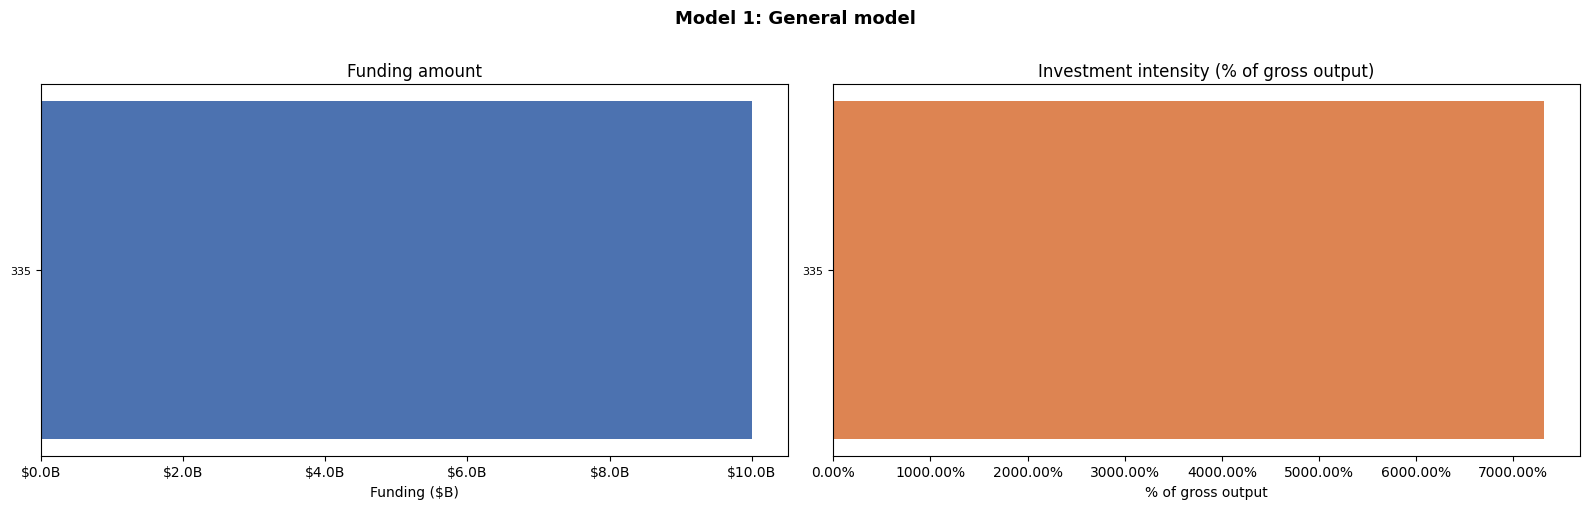

In [192]:
# Model 1: General model
# Max Σ μᵢ·aᵢ  s.t.  Σaᵢ ≤ B,  aᵢ ≥ 0

prob1 = pulp.LpProblem("M1_General", pulp.LpMaximize)
a1    = [pulp.LpVariable(f"a_{i}", lowBound=0) for i in range(N)]

prob1 += pulp.lpSum(mu[i] * a1[i] for i in range(N))          # objective
prob1 += pulp.lpSum(a1[i] for i in range(N)) <= BUDGET         # budget

prob1.solve(pulp.PULP_CBC_CMD(msg=0))
status1, obj1 = solve_status(prob1)
alloc1 = np.array([pulp.value(a1[i]) or 0.0 for i in range(N)])

print(f"M1 — Status: {status1} | Obj: {obj1:.4e} | Spend: ${alloc1.sum()/1e9:.2f}B")
print(f"     Industries funded: {(alloc1>1e4).sum()} | Max intensity: {(alloc1/GO).max()*100:.1f}%")
plot_industry_results(alloc1, GO, INDUSTRIES, "Model 1: General model")

### Model 2: Adding No Nationalization constraint

M2 cap=5% — Optimal | Obj: 8.5478e+14 | Spend: $0.56B | Funded: 38


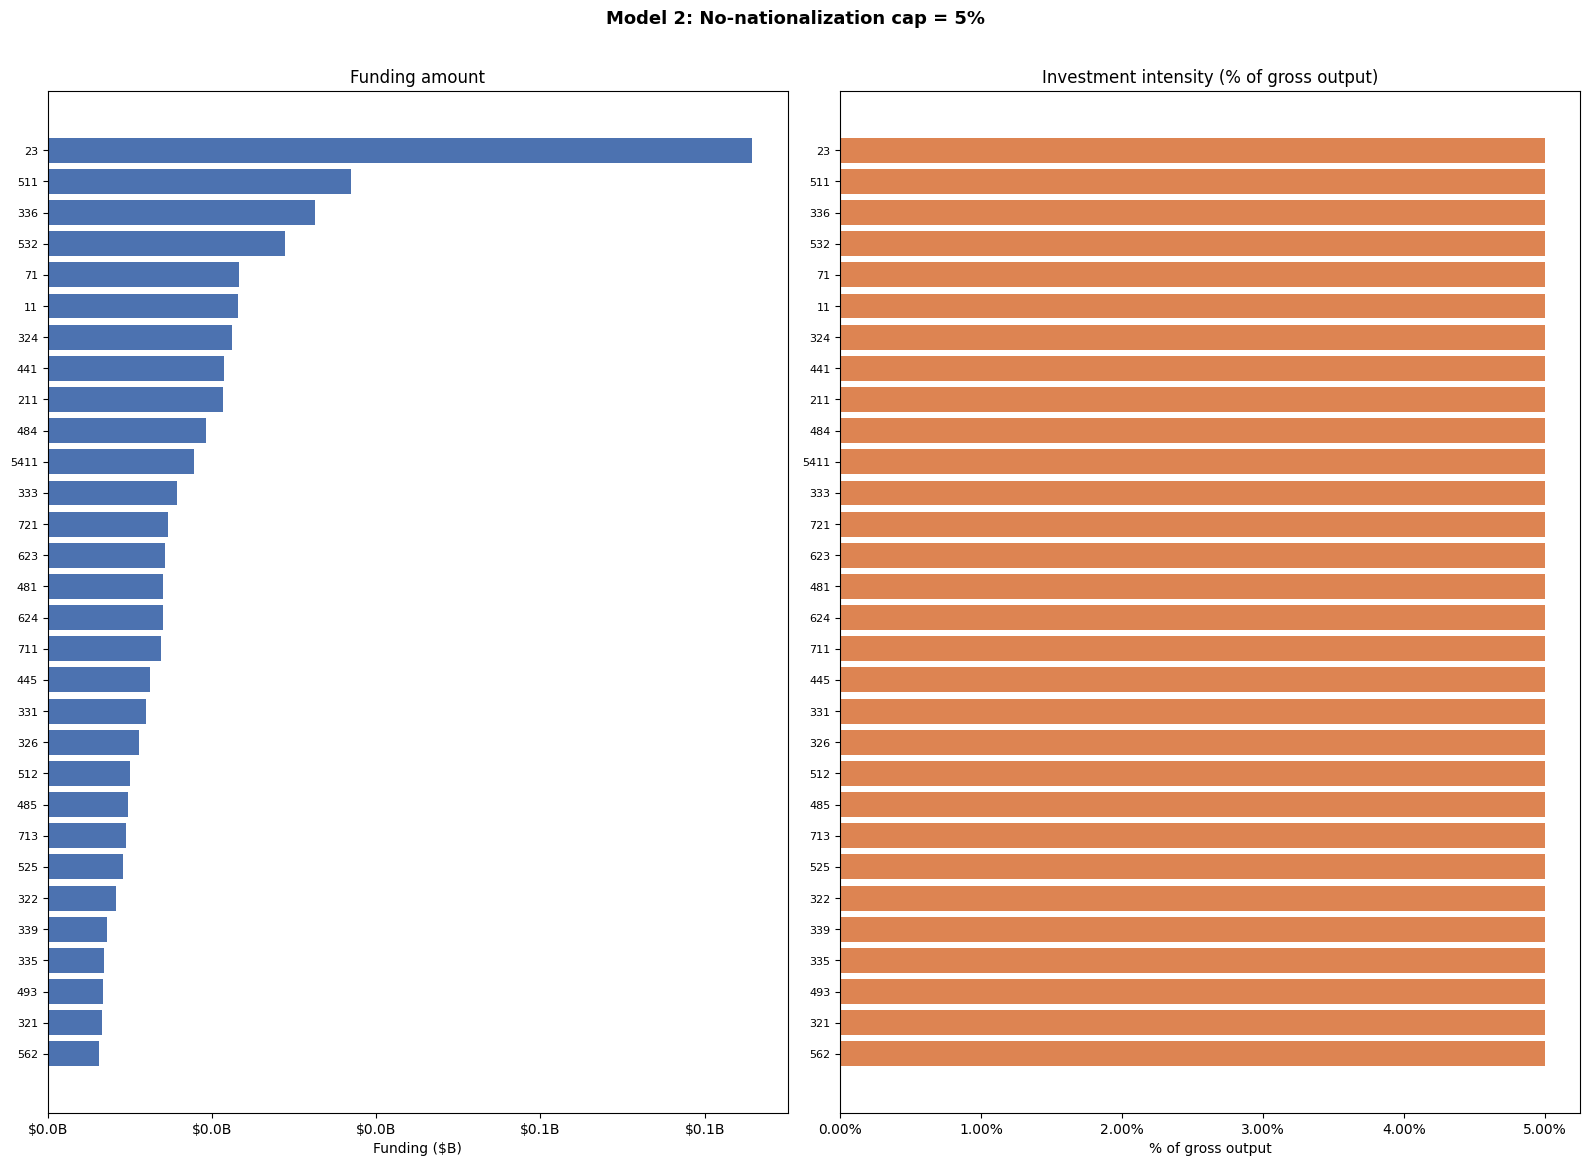

M2 cap=10% — Optimal | Obj: 1.7096e+15 | Spend: $1.12B | Funded: 38


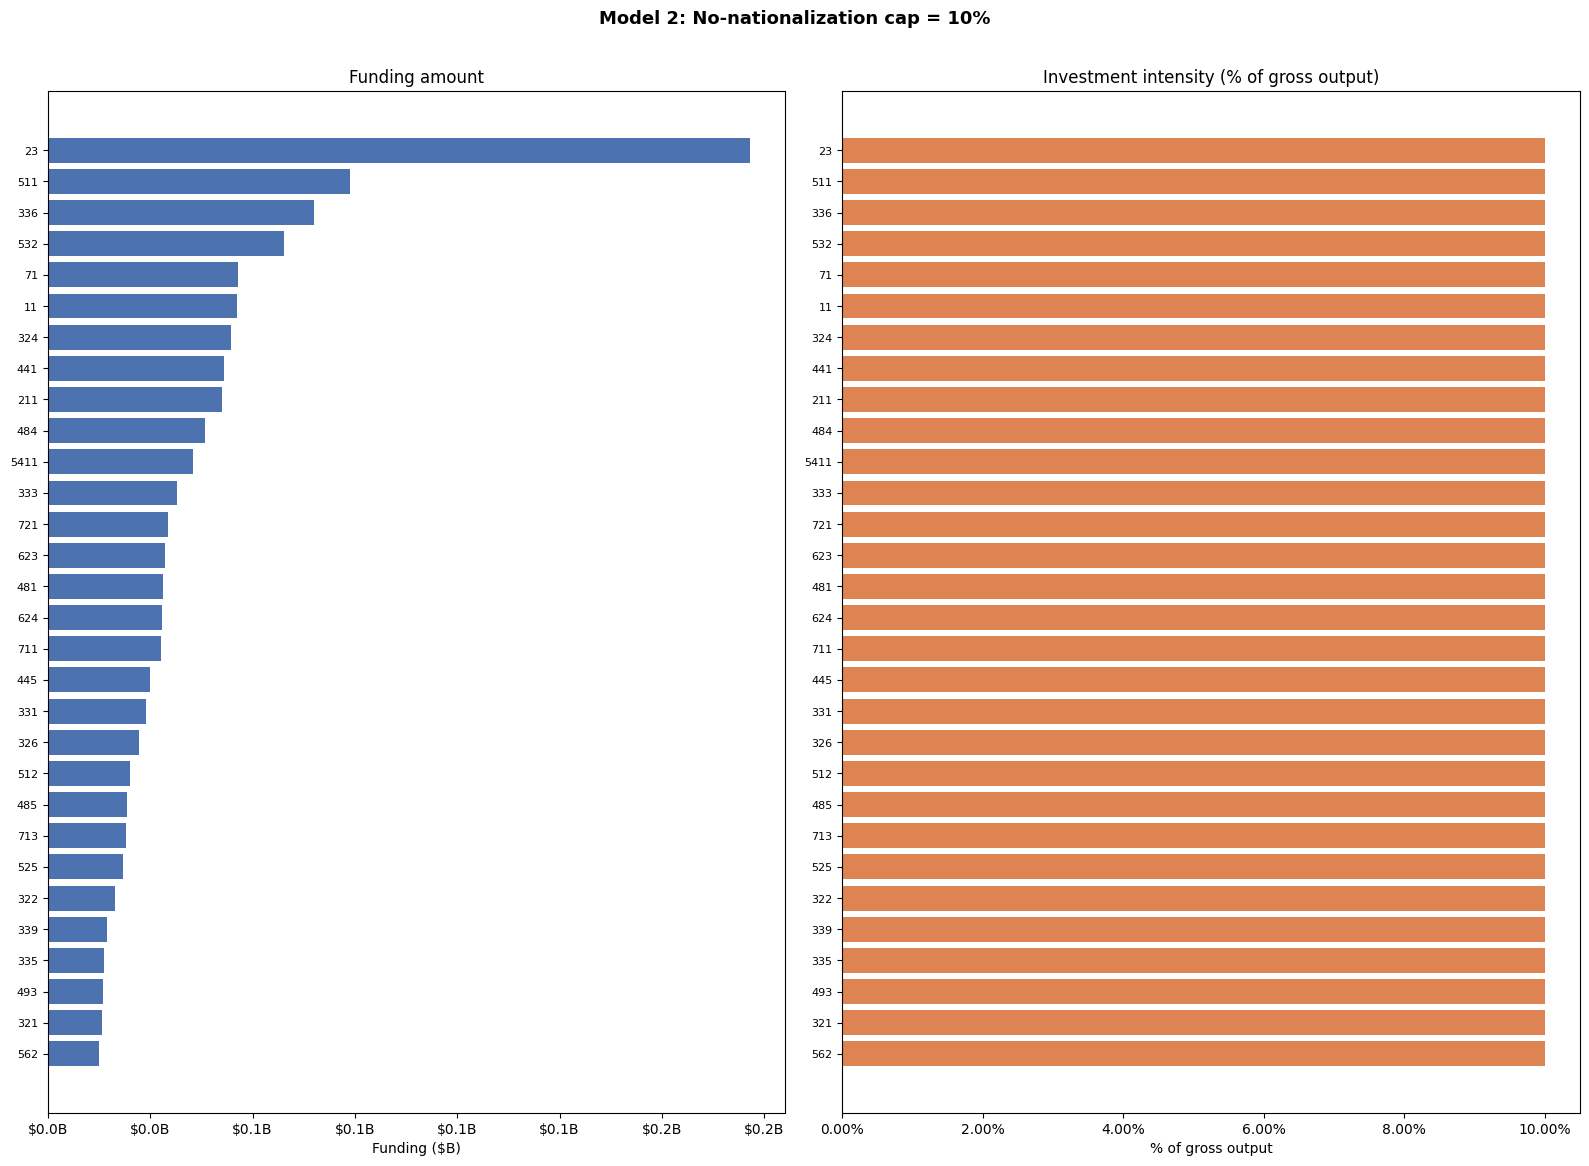

M2 cap=20% — Optimal | Obj: 3.4191e+15 | Spend: $2.25B | Funded: 38


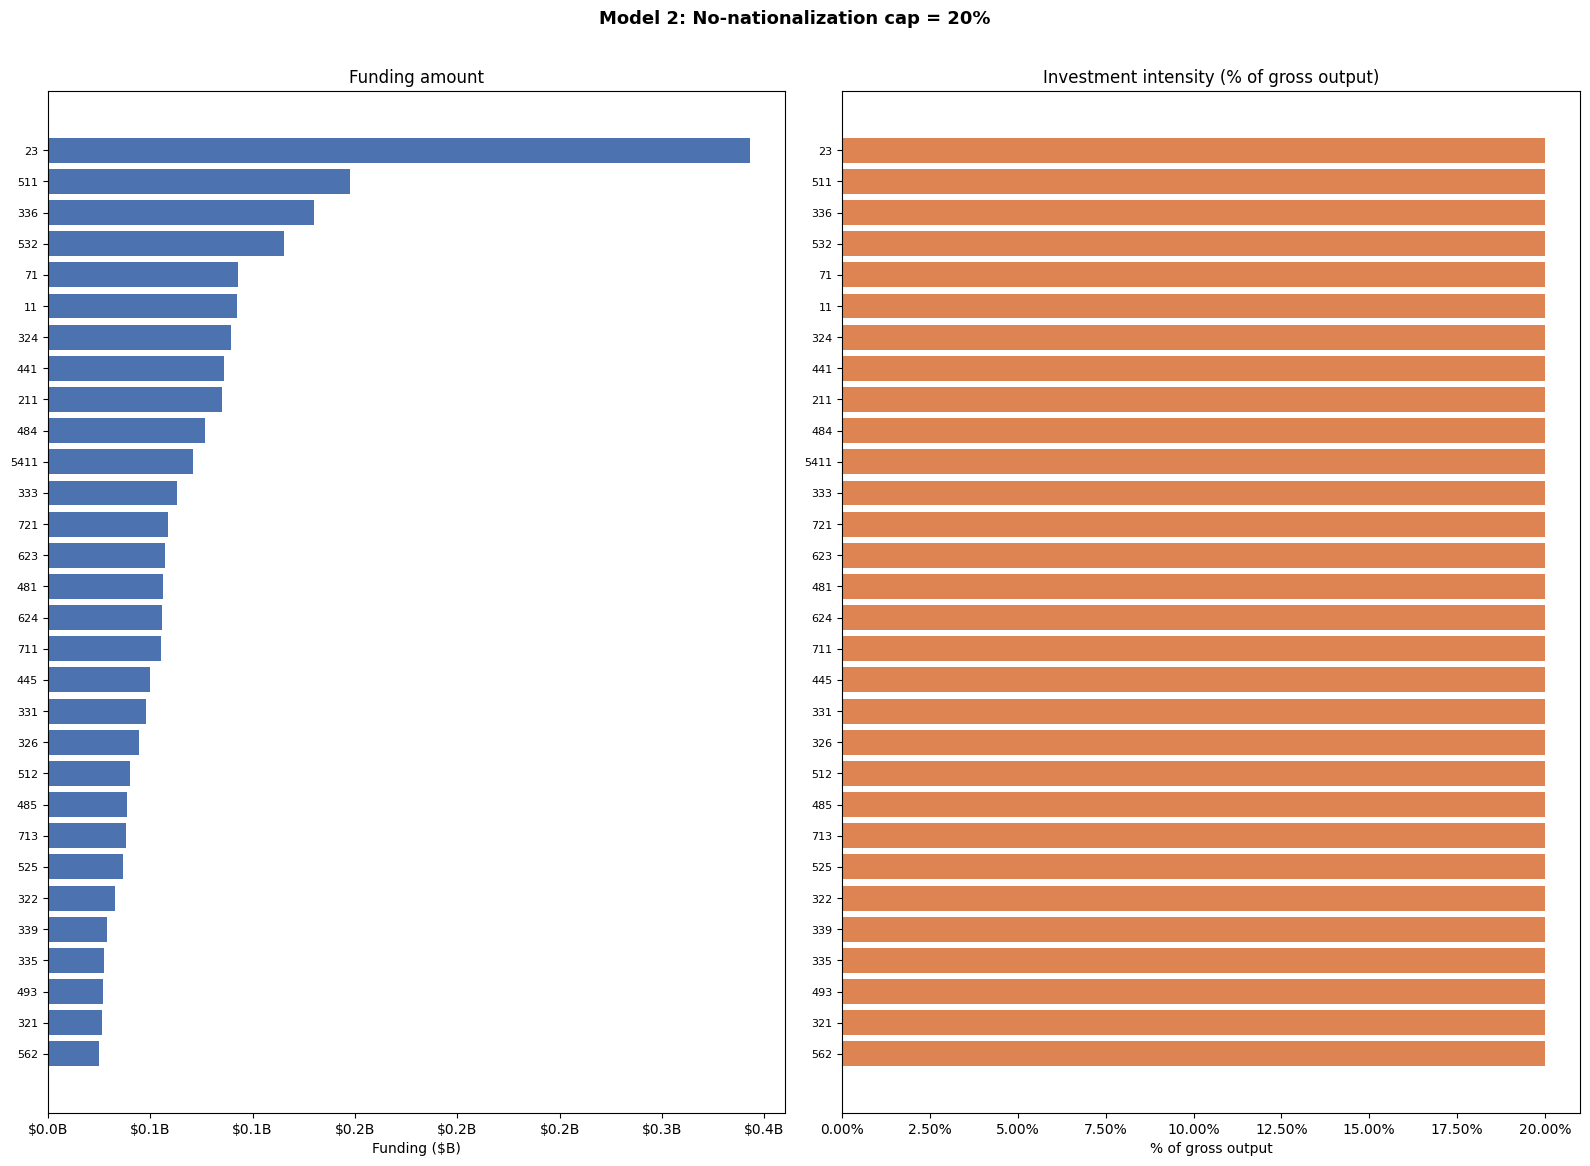

In [ ]:
# Model 2: intensity cap swept over [5%, 10%, 20%] applies uniform cap to ALL industries
# (priority tiering starts from Model 4 onward via intensity_caps[i])


intensity_caps = [0.05, 0.10, 0.20]
results_m2 = {}

for cap in intensity_caps:
    prob = pulp.LpProblem(f"M2_cap{int(cap*100)}", pulp.LpMaximize)
    a    = [pulp.LpVariable(f"a_{i}", lowBound=0, upBound=cap * GO[i]) for i in range(N)]

    prob += pulp.lpSum(mu[i] * a[i] for i in range(N))
    prob += pulp.lpSum(a[i] for i in range(N)) <= BUDGET

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    status, obj = solve_status(prob)
    alloc = np.array([pulp.value(a[i]) or 0.0 for i in range(N)])
    results_m2[cap] = alloc

    print(f"M2 cap={cap*100:.0f}% — {status} | Obj: {obj:.4e} | Spend: ${alloc.sum()/1e9:.2f}B | Funded: {(alloc>1e4).sum()}")
    plot_industry_results(alloc, GO, INDUSTRIES, f"Model 2: No-nationalization cap = {cap*100:.0f}%")

### Model 3: adding value added growth filter

M3 — Optimal | Obj: 1.2303e+15 | Spend: $0.86B | Funded: 24


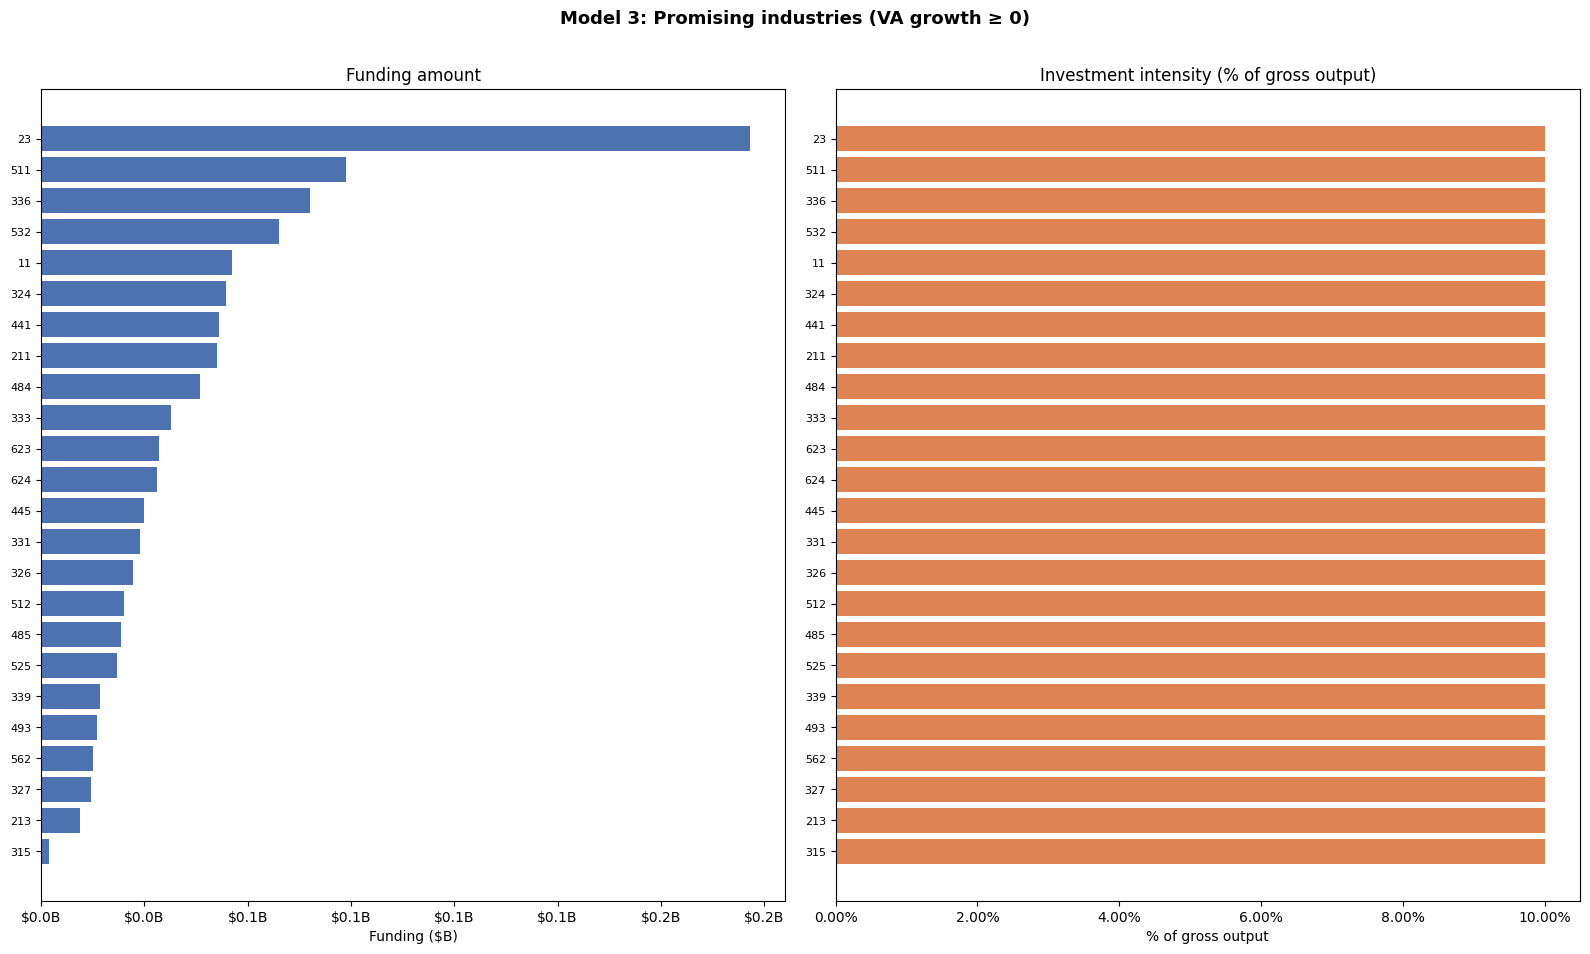

In [194]:
# Model 3: M2 (10% cap) + restrict to industries with positive VA growth

prob3 = pulp.LpProblem("M3_VA_filter", pulp.LpMaximize)
a3 = [
    pulp.LpVariable(f"a_{i}", lowBound=0, upBound=(0.10 * GO[i] if va_pos[i] else 0.0))
    for i in range(N)
]

prob3 += pulp.lpSum(mu[i] * a3[i] for i in range(N))
prob3 += pulp.lpSum(a3[i] for i in range(N)) <= BUDGET

prob3.solve(pulp.PULP_CBC_CMD(msg=0))
status3, obj3 = solve_status(prob3)
alloc3 = np.array([pulp.value(a3[i]) or 0.0 for i in range(N)])

print(f"M3 — {status3} | Obj: {obj3:.4e} | Spend: ${alloc3.sum()/1e9:.2f}B | Funded: {(alloc3>1e4).sum()}")
plot_industry_results(alloc3, GO, INDUSTRIES, "Model 3: Promising industries (VA growth ≥ 0)")

### Model 4: trying out adding employment growth filter

M4 — Optimal | Obj: 1.4022e+15 | Spend: $0.99B | Funded: 34


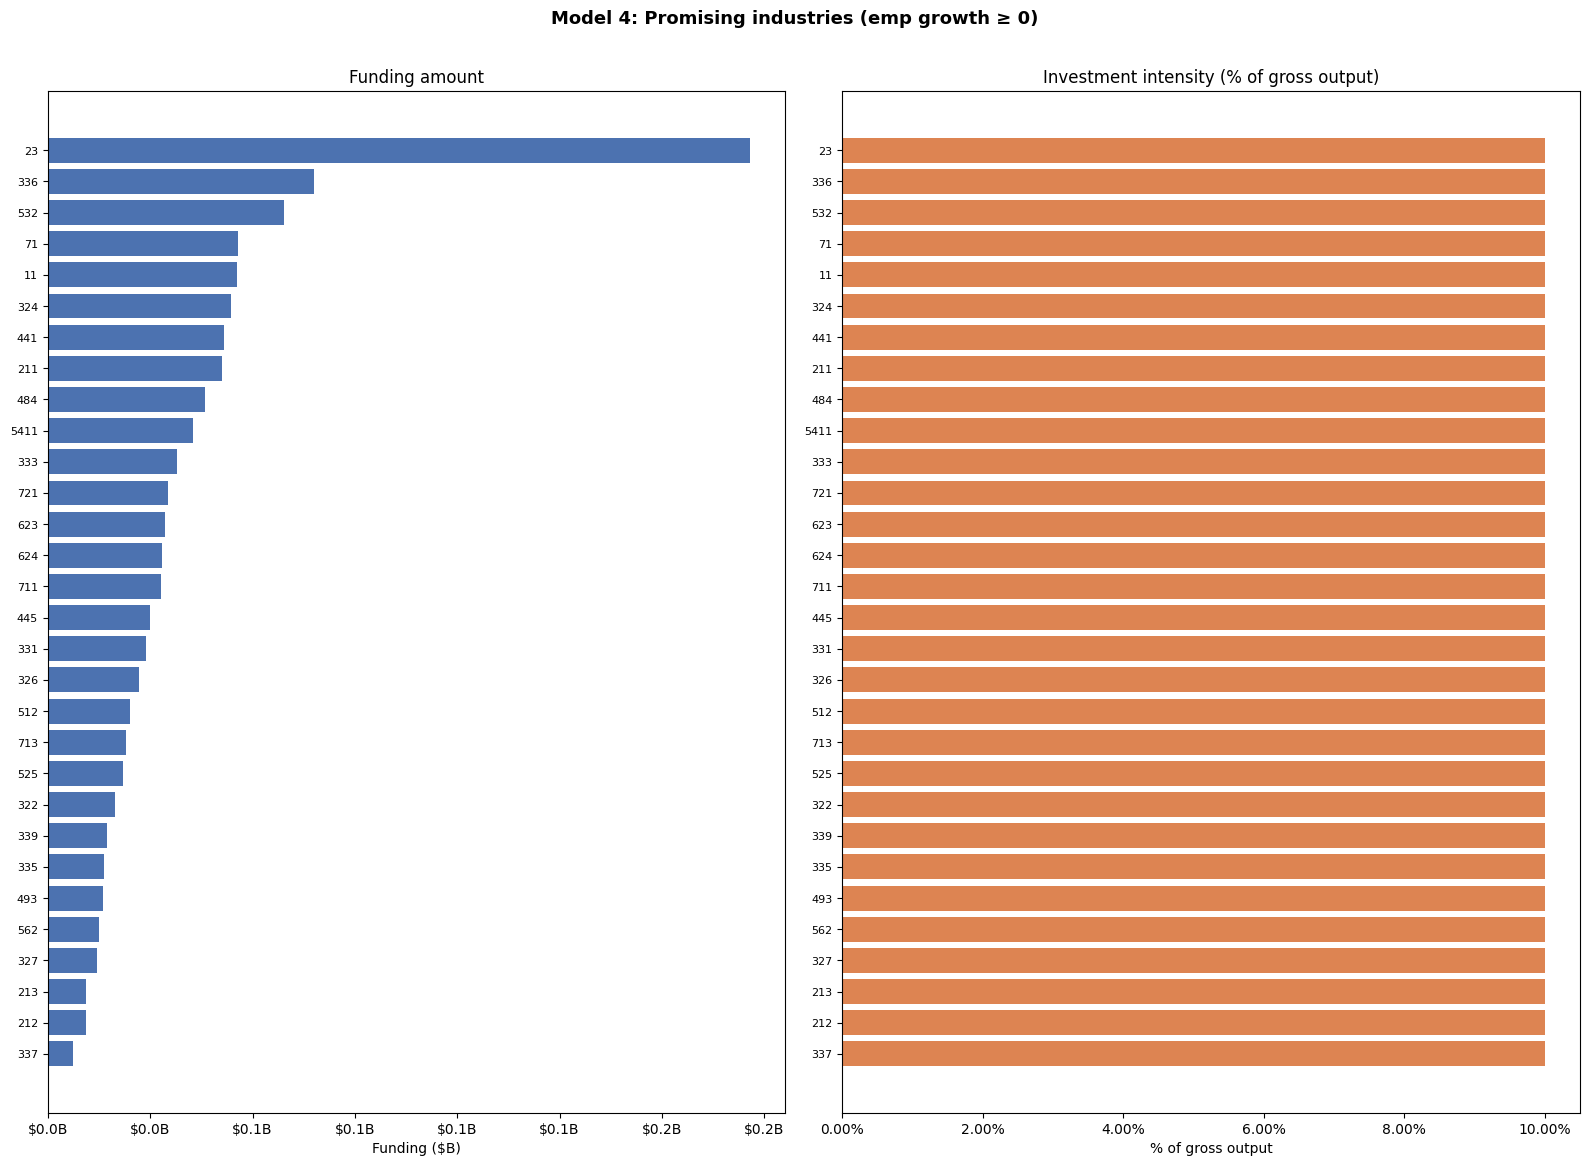

In [195]:
# Model 4: M2 (10% cap) + restrict to industries with positive emp growth

prob4 = pulp.LpProblem("M4_Emp_filter", pulp.LpMaximize)
a4 = [
    pulp.LpVariable(f"a_{i}", lowBound=0, upBound=(0.10 * GO[i] if emp_pos[i] else 0.0))
    for i in range(N)
]

prob4 += pulp.lpSum(mu[i] * a4[i] for i in range(N))
prob4 += pulp.lpSum(a4[i] for i in range(N)) <= BUDGET

prob4.solve(pulp.PULP_CBC_CMD(msg=0))
status4, obj4 = solve_status(prob4)
alloc4 = np.array([pulp.value(a4[i]) or 0.0 for i in range(N)])

print(f"M4 — {status4} | Obj: {obj4:.4e} | Spend: ${alloc4.sum()/1e9:.2f}B | Funded: {(alloc4>1e4).sum()}")
plot_industry_results(alloc4, GO, INDUSTRIES, "Model 4: Promising industries (emp growth ≥ 0)")

### Model 5: adding state balance for political constraint

M5 tol=±10% — Optimal | Obj: 1.2256e+15 | Spend: $0.99B


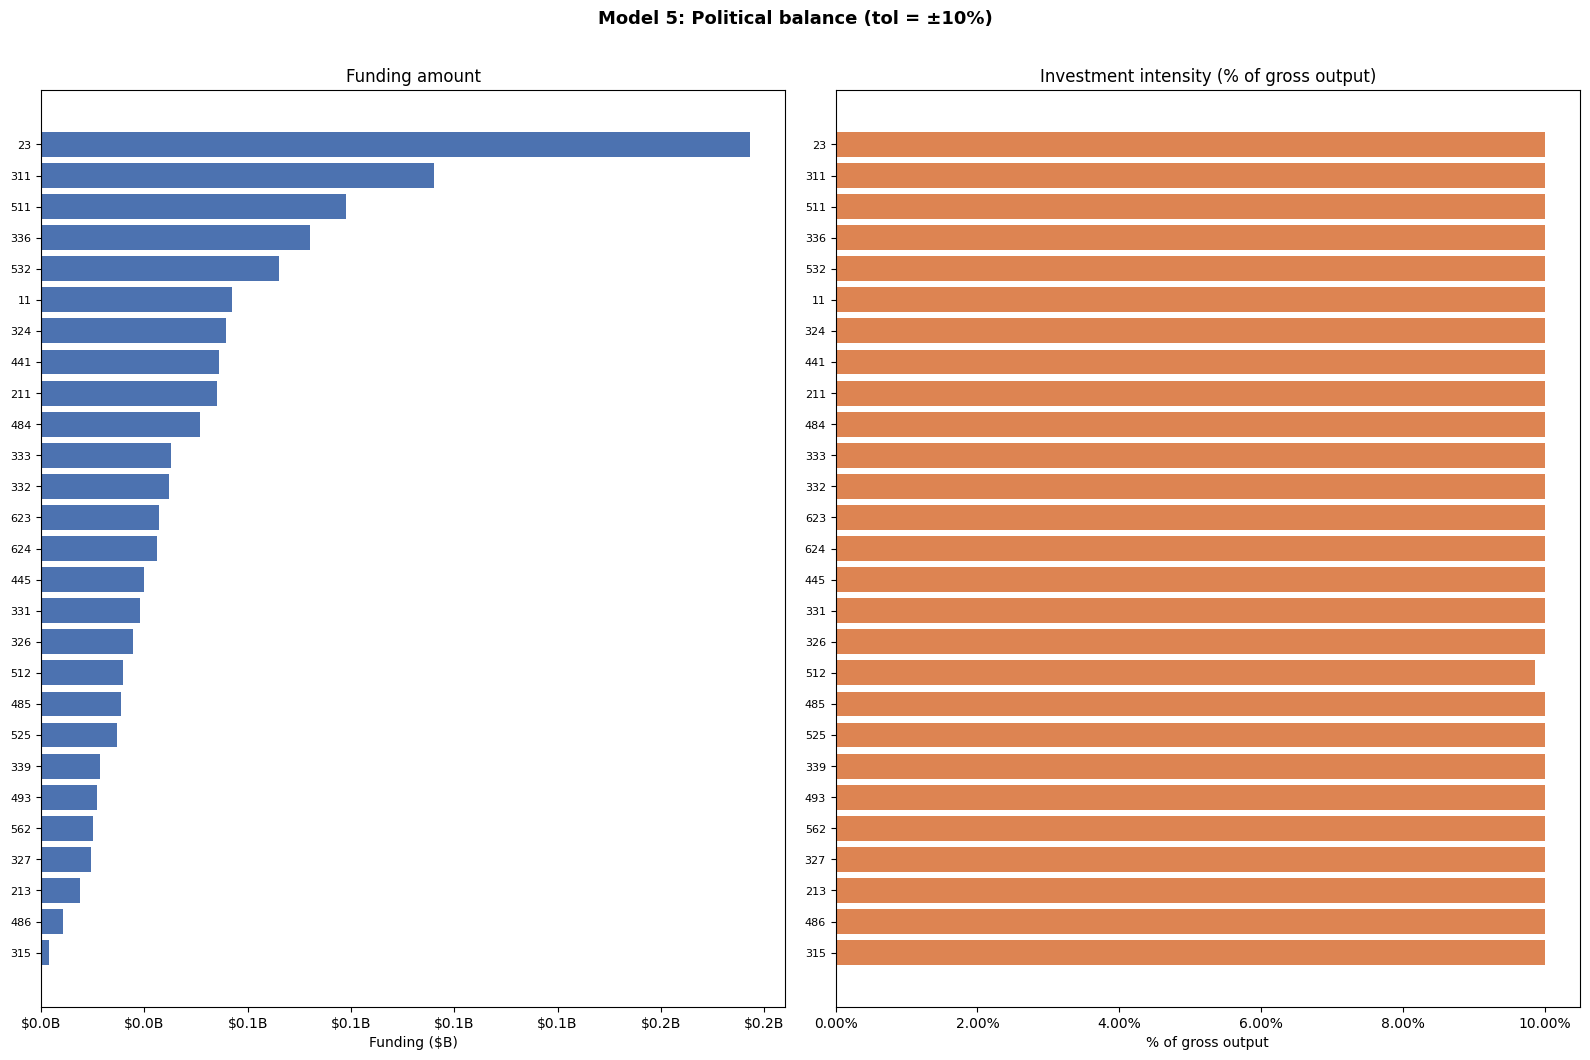

M5 tol=±20% — Optimal | Obj: 1.2303e+15 | Spend: $0.86B


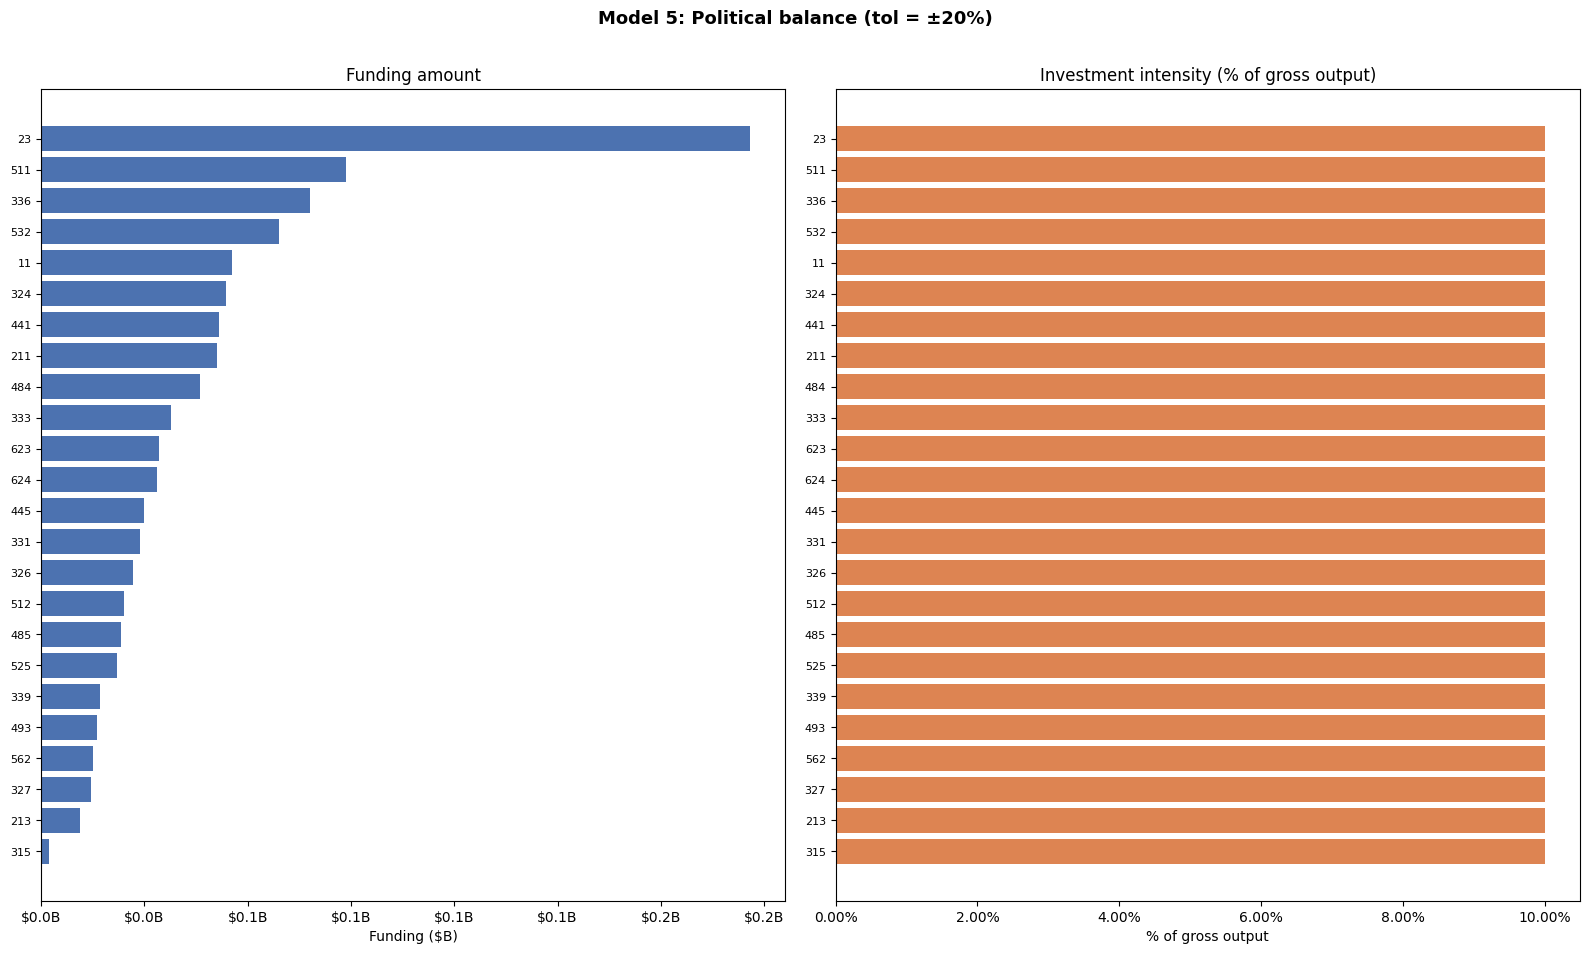

M5 tol=±50% — Optimal | Obj: 1.2303e+15 | Spend: $0.86B


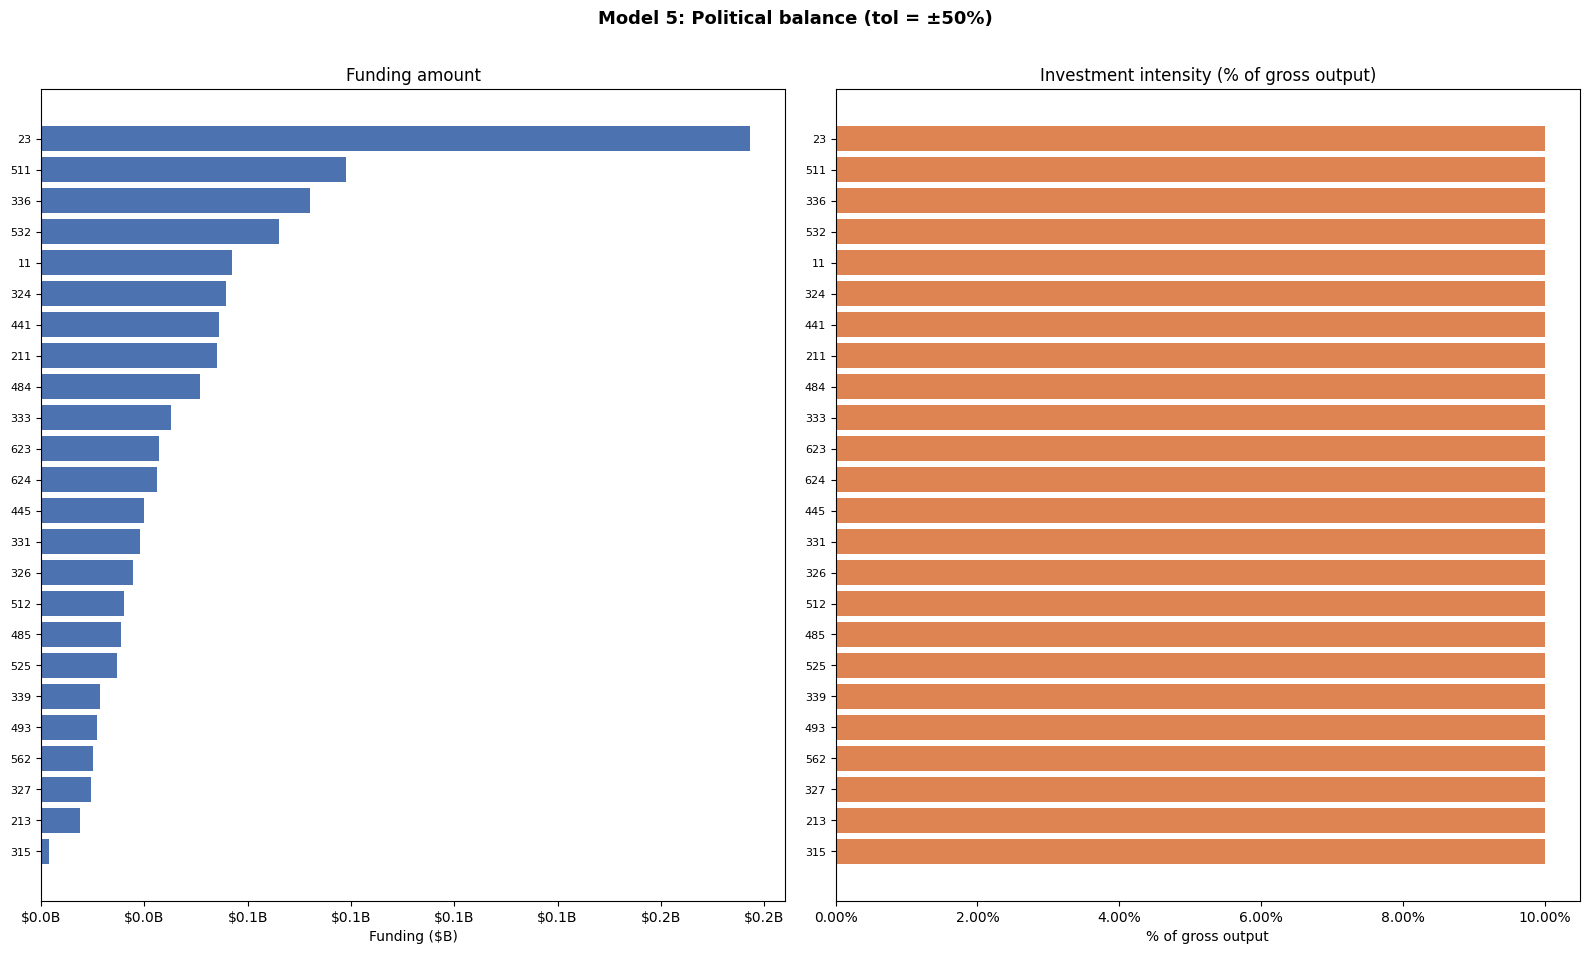


Best (tightest) feasible tolerance: ±10%


In [196]:
# Model 5: M3 + political balance constraint (swept over tolerances)
#
# Interpretation of W[s,i]: fraction of industry i's workforce in state s.
# Effective funding received by state s (employment-weighted):
#   F_s = Σᵢ W[s,i] · aᵢ / GO[i]    (weighted by intensity, not raw dollars)
#
# But simpler and defensible: require the dollar-weighted state exposure to
# sit within ± tol of the equal-share benchmark 1/S:
#   Σᵢ W[s,i] · aᵢ  ≥  (1/S - tol) · Σᵢ aᵢ
#   Σᵢ W[s,i] · aᵢ  ≤  (1/S + tol) · Σᵢ aᵢ
# This says: state s's employment-weighted funding share ≈ its population-equal share.

balance_tols = [0.10, 0.20, 0.50]
results_m5   = {}

for tol in balance_tols:
    prob = pulp.LpProblem(f"M5_tol{int(tol*100)}", pulp.LpMaximize)
    a    = [
        pulp.LpVariable(f"a_{i}", lowBound=0, upBound=(0.10 * GO[i] if va_pos[i] else 0.0))
        for i in range(N)
    ]
    total = pulp.lpSum(a[i] for i in range(N))

    prob += pulp.lpSum(mu[i] * a[i] for i in range(N))
    prob += total <= BUDGET

    for s in range(S):
        state_wtd = pulp.lpSum(W[s, i] * a[i] for i in range(N))
        prob += state_wtd >= (equal_share - tol) * total,  f"state_lo_{s}"
        prob += state_wtd <= (equal_share + tol) * total,  f"state_hi_{s}"

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    status, obj = solve_status(prob)
    alloc = np.array([pulp.value(a[i]) or 0.0 for i in range(N)])
    results_m5[tol] = (alloc, status)

    print(f"M5 tol=±{tol*100:.0f}% — {status} | Obj: {obj:.4e} | Spend: ${alloc.sum()/1e9:.2f}B")
    if status == "Optimal":
        plot_industry_results(alloc, GO, INDUSTRIES,
                              f"Model 5: Political balance (tol = ±{tol*100:.0f}%)")

# Record best feasible tolerance for downstream models
feasible_tols = [t for t, (_, s) in results_m5.items() if s == "Optimal"]
BEST_TOL = min(feasible_tols) if feasible_tols else 0.50
print(f"\nBest (tightest) feasible tolerance: ±{BEST_TOL*100:.0f}%")

### Model 6: adding national security priorities constraint

In [214]:
# National priority industries + tiered intensity caps
# Priority industries: up to 50% intensity
# All others: up to 10% intensity (no-nationalization cap from M2)

NATIONAL_PRIORITY_NAICS = [334, 336, 331, 211, 325]

priority_mask = np.array([n in NATIONAL_PRIORITY_NAICS for n in INDUSTRIES])

# Tiered cap: 50% for priority industries, 10% for all others
PRIORITY_CAP    = 1.0
STANDARD_CAP    = 0.1
intensity_caps  = np.where(priority_mask, PRIORITY_CAP, STANDARD_CAP)  # shape (N,)

print(f"Priority industries flagged: {priority_mask.sum()} / 5 expected")
print(f"\n{'NAICS':>6}  {'Cap':>6}  {'μ':>14}  {'GO ($B)':>10}  {'va_growth':>10}")
print("-" * 55)
for i, n in enumerate(INDUSTRIES):
    cap_str = f"{intensity_caps[i]*100:.0f}%"
    print(f"{n:>6}  {cap_str:>6}  {mu[i]:>14.3e}  {GO[i]/1e9:>10.2f}  {master.loc[i,'va_growth']:>10.4f}")

Priority industries flagged: 5 / 5 expected

 NAICS     Cap               μ     GO ($B)   va_growth
-------------------------------------------------------
    54     10%      -3.650e+07        3.34      0.0410
    53     10%      -3.439e+07        4.75      0.0240
   531     10%      -3.128e+07        4.17      0.0199
    31     10%      -2.655e+07        5.59      0.0011
    51     10%      -1.852e+07        2.91      0.0601
    52     10%      -1.774e+07        3.31      0.0188
    44     10%      -1.389e+07        2.37      0.0332
  5412     10%      -1.016e+07        2.11      0.0365
  5415     10%      -8.136e+06        0.91      0.1038
    42     10%      -6.382e+06        2.14      0.0150
    49     10%      -5.726e+06        1.38      0.0318
    48     10%      -5.292e+06        1.42      0.0294
   524     10%      -4.839e+06        1.35      0.0571
   561     10%      -3.901e+06        1.13      0.0527
   622     10%      -3.232e+06        1.07      0.0157
   621     10%     

M6 floor=5% — Optimal | Obj: 2.1333e+15 | Priority share: 56.3%


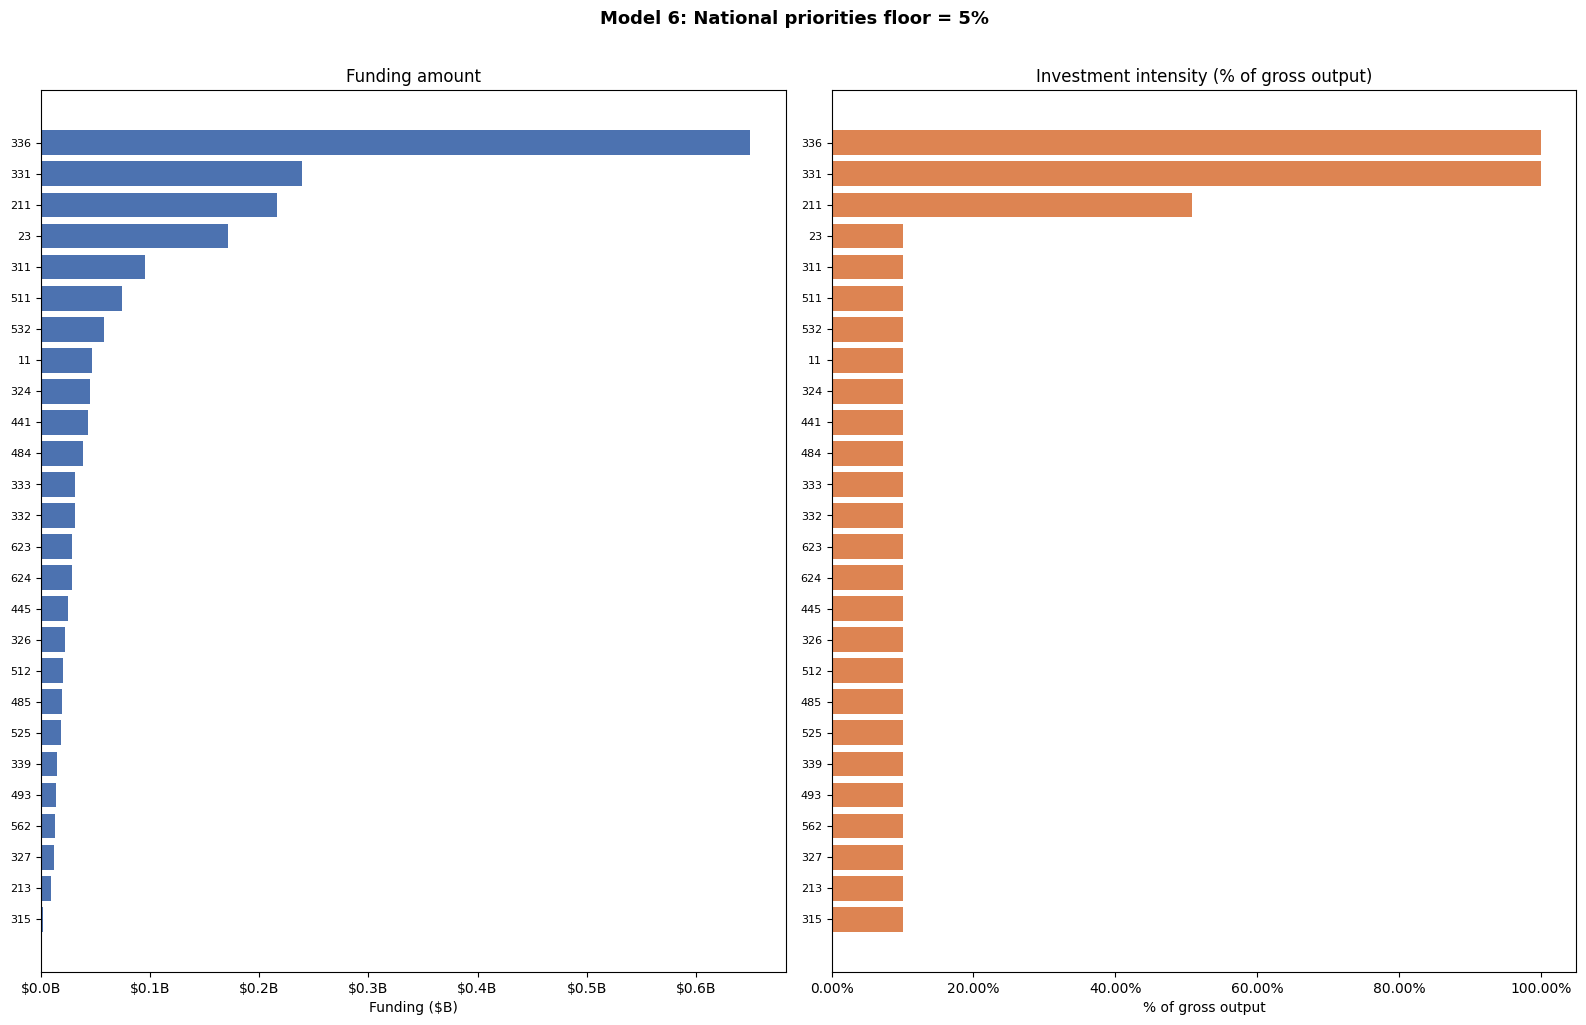

M6 floor=10% — Optimal | Obj: 2.1333e+15 | Priority share: 56.3%


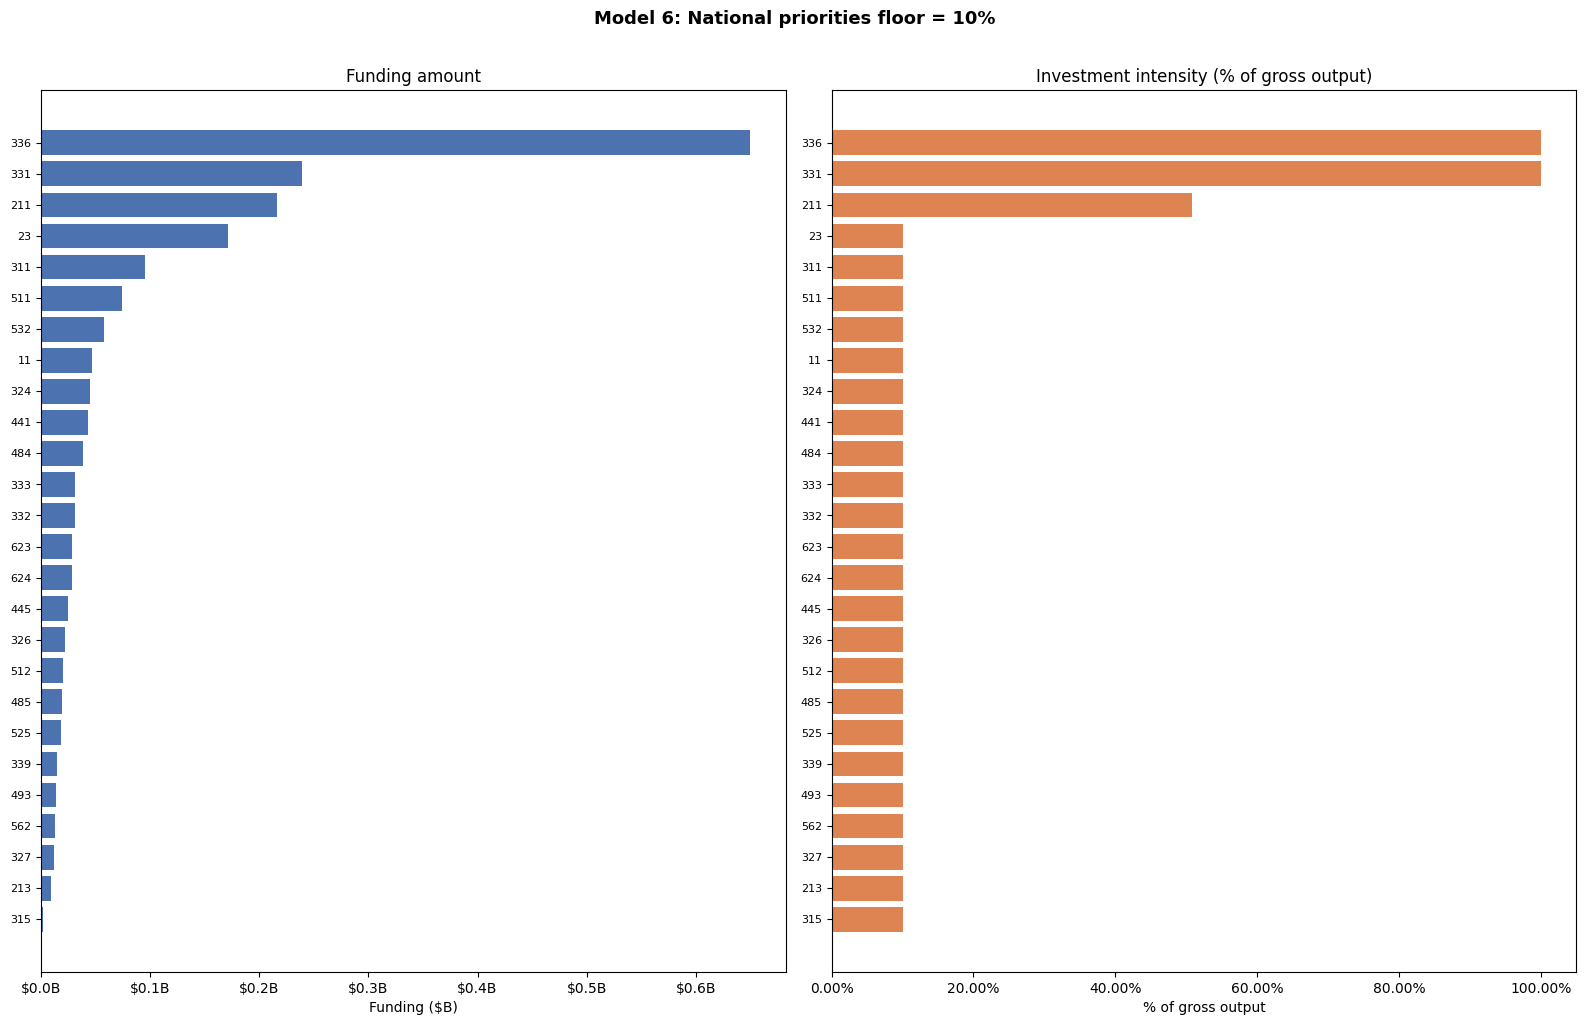

M6 floor=15% — Optimal | Obj: 2.0862e+15 | Priority share: 63.6%


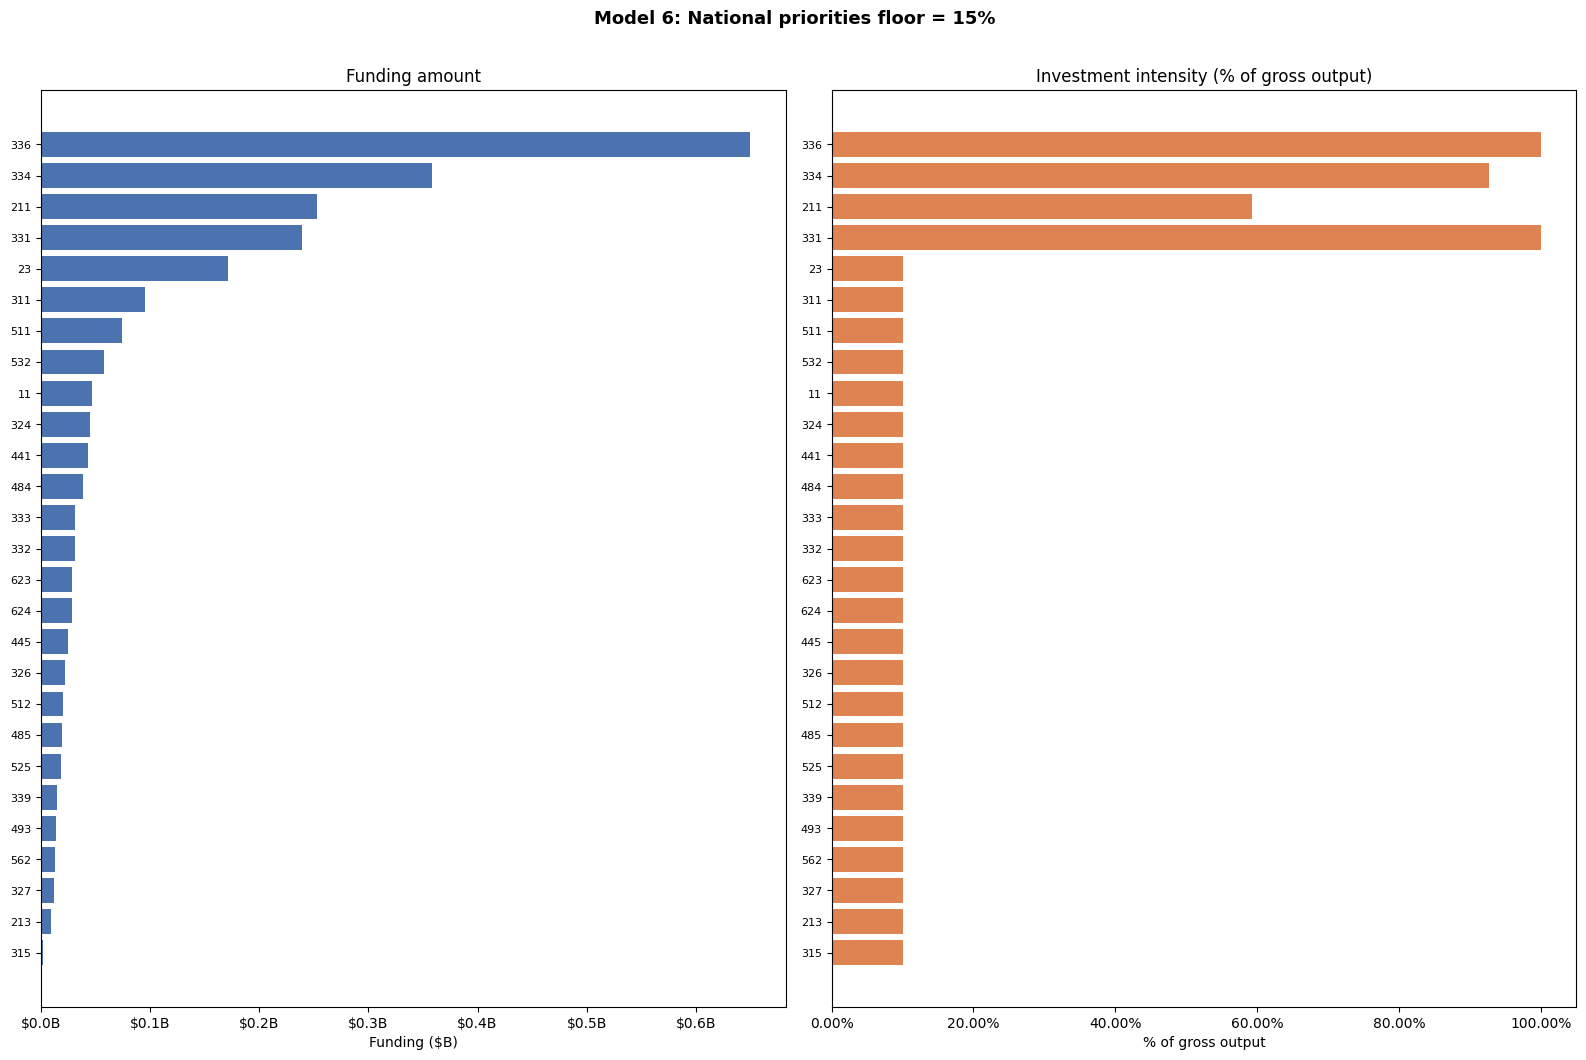

M6 floor=20% — Optimal | Obj: 1.3967e+15 | Priority share: 68.9%


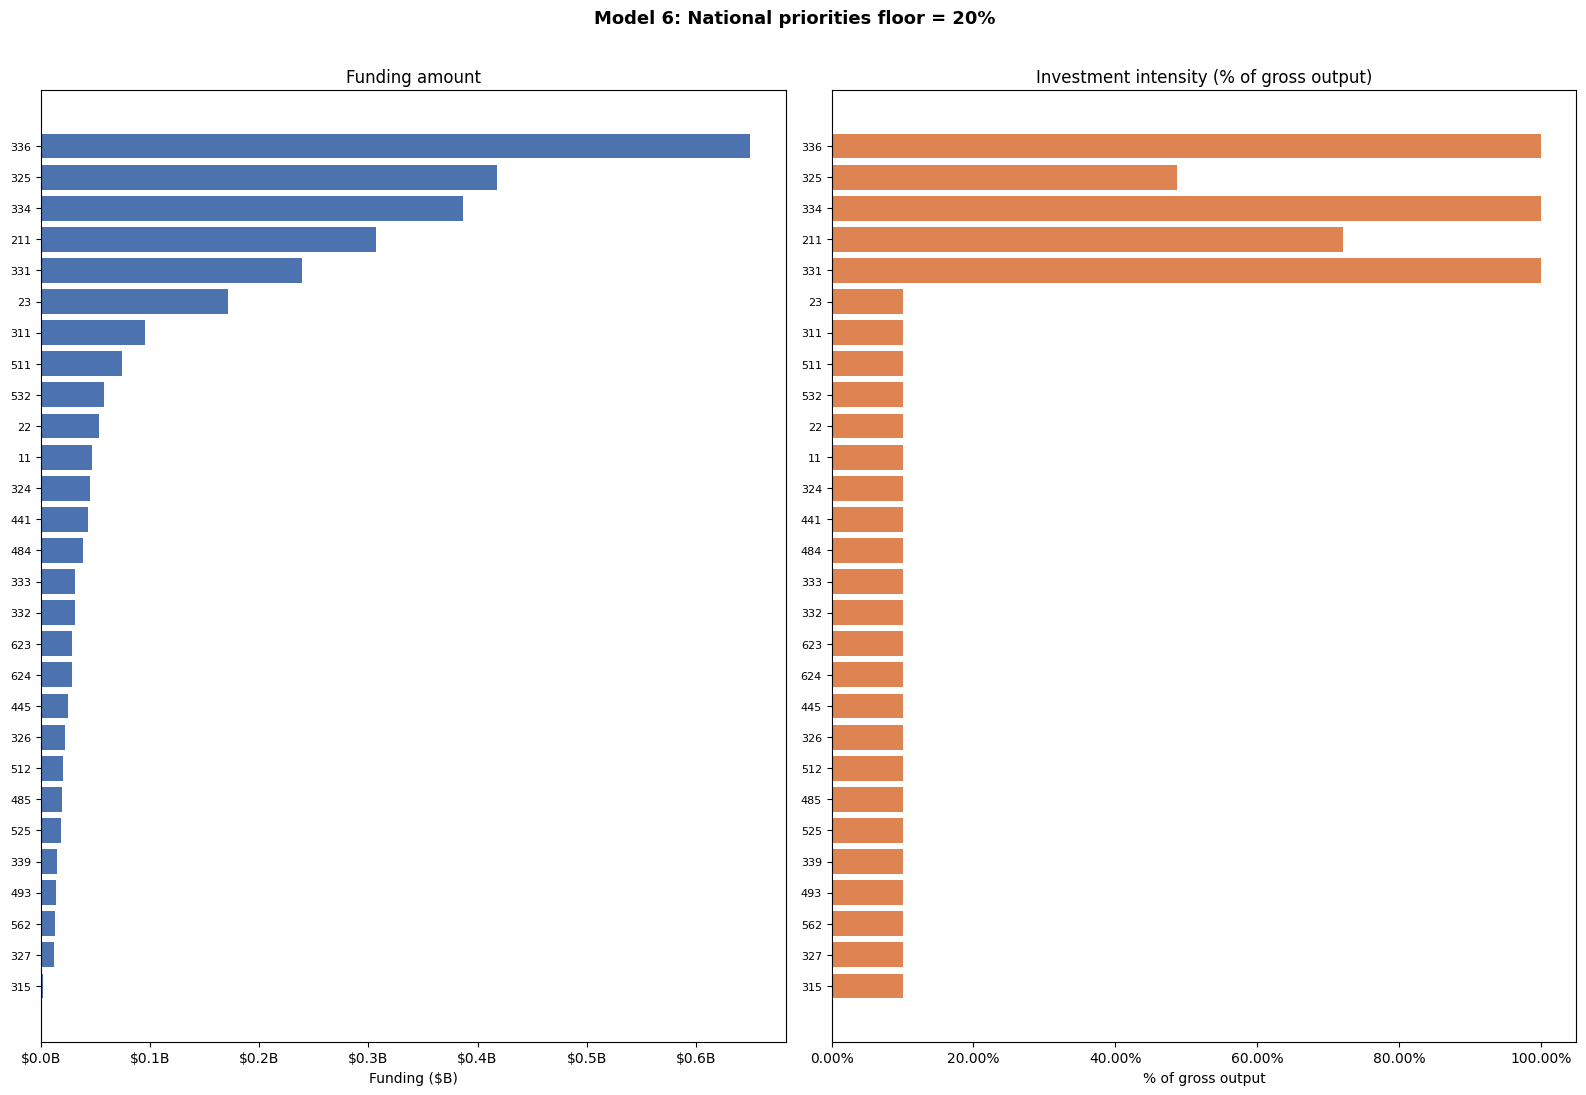

M6 floor=25% — Optimal | Obj: 5.7986e+14 | Priority share: 73.3%


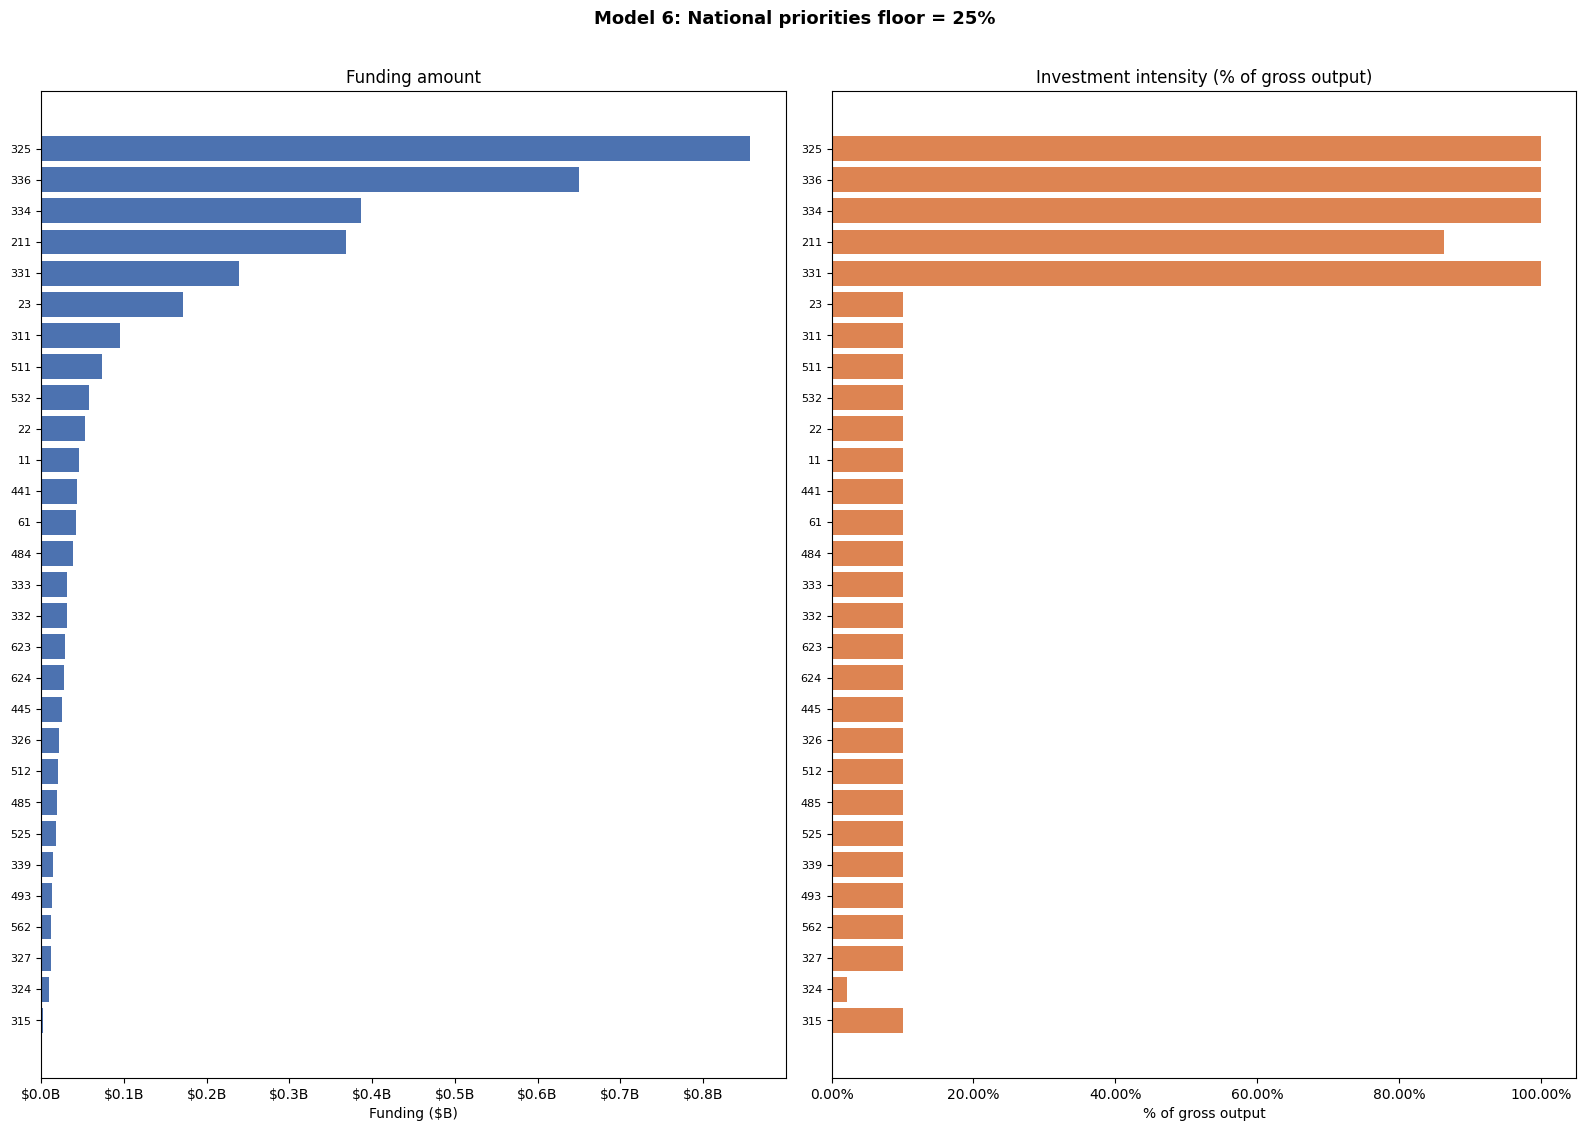

M6 floor=30% — Infeasible

M6 baseline (10% floor): Obj = 2.1333e+15


In [215]:
# Model 6: M5 (best tolerance) + national priority floor (swept)

priority_floors = [0.05, 0.10, 0.15, 0.20, 0.25, 0.3]
results_m6      = {}

for floor in priority_floors:
    prob = pulp.LpProblem(f"M6_floor{int(floor*100)}", pulp.LpMaximize)
    a    = [
        pulp.LpVariable(f"a_{i}", lowBound=0, upBound=(intensity_caps[i] * GO[i] if va_pos[i] else 0.0))
        for i in range(N)
    ]
    total = pulp.lpSum(a[i] for i in range(N))

    prob += pulp.lpSum(mu[i] * a[i] for i in range(N))
    prob += total <= BUDGET

    for s in range(S):
        state_wtd = pulp.lpSum(W[s, i] * a[i] for i in range(N))
        prob += state_wtd >= (equal_share - BEST_TOL) * total, f"state_lo_{s}"
        prob += state_wtd <= (equal_share + BEST_TOL) * total, f"state_hi_{s}"

    prob += (
        pulp.lpSum(a[i] for i in range(N) if priority_mask[i]) >= floor * BUDGET,
        "national_priority"
    )

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    status, obj = solve_status(prob)
    alloc = np.array([pulp.value(a[i]) or 0.0 for i in range(N)])
    results_m6[floor] = (alloc, status, obj)

    if status == "Optimal":
        pri_pct = alloc[priority_mask].sum() / max(alloc.sum(), 1) * 100
        print(f"M6 floor={floor*100:.0f}% — {status} | Obj: {obj:.4e} | Priority share: {pri_pct:.1f}%")
        plot_industry_results(alloc, GO, INDUSTRIES,
                              f"Model 6: National priorities floor = {floor*100:.0f}%")
    else:
        print(f"M6 floor={floor*100:.0f}% — {status}")

# Best M6 for use in M7/M8/M9
BEST_FLOOR = 0.10
M6_BEST_ALLOC, _, M6_BEST_OBJ = results_m6[BEST_FLOOR]
print(f"\nM6 baseline (10% floor): Obj = {M6_BEST_OBJ:.4e}")

### Model 7: investment funneled through agencies rather than directly to industries

In [216]:
# Cell 12 — Model 7: Agency funding as decision variable
# Decision var: b[k] = budget to agency k
# Implied industry allocation: a[i] = Σ_k P[k,i] * b[k]
# All M6 constraints apply to the implied a[i]

prob7 = pulp.LpProblem("M7_Agency", pulp.LpMaximize)
b7    = [pulp.LpVariable(f"b_{k}", lowBound=0) for k in range(K)]

# Implied industry allocations as linear expressions
a7 = [pulp.lpSum(P[k, i] * b7[k] for k in range(K)) for i in range(N)]
total7 = pulp.lpSum(b7[k] for k in range(K))

prob7 += pulp.lpSum(mu[i] * a7[i] for i in range(N))
prob7 += total7 <= BUDGET

for i in range(N):
    prob7 += a7[i] <= (intensity_caps[i] * GO[i] if va_pos[i] else 0.0), f"cap_{i}"

for s in range(S):
    state_wtd = pulp.lpSum(W[s, i] * a7[i] for i in range(N))
    prob7 += state_wtd >= (equal_share - BEST_TOL) * total7, f"state_lo_{s}"
    prob7 += state_wtd <= (equal_share + BEST_TOL) * total7, f"state_hi_{s}"

prob7 += (
    pulp.lpSum(a7[i] for i in range(N) if priority_mask[i]) >= BEST_FLOOR * BUDGET,
    "national_priority"
)

prob7.solve(pulp.PULP_CBC_CMD(msg=0))
status7, obj7 = solve_status(prob7)

if status7 == "Optimal":
    agency_alloc7 = np.array([pulp.value(b7[k]) or 0.0 for k in range(K)])
    ind_alloc7    = np.array([pulp.value(a7[i])  or 0.0 for i in range(N)])
    print(f"M7 — {status7} | Obj: {obj7:.4e} | Agency spend: ${agency_alloc7.sum()/1e9:.2f}B")
    plot_agency_results(agency_alloc7, AGENCIES, "Model 7: Agency-level funding")
    plot_industry_results(ind_alloc7, GO, INDUSTRIES, "Model 7: Implied industry funding")
else:
    print(f"M7 — {status7}")

M7 — Infeasible


### Model 8: minimize budget subject to different value added targets

M8 target=70% of M6 obj — Optimal | Min budget: $0.56B


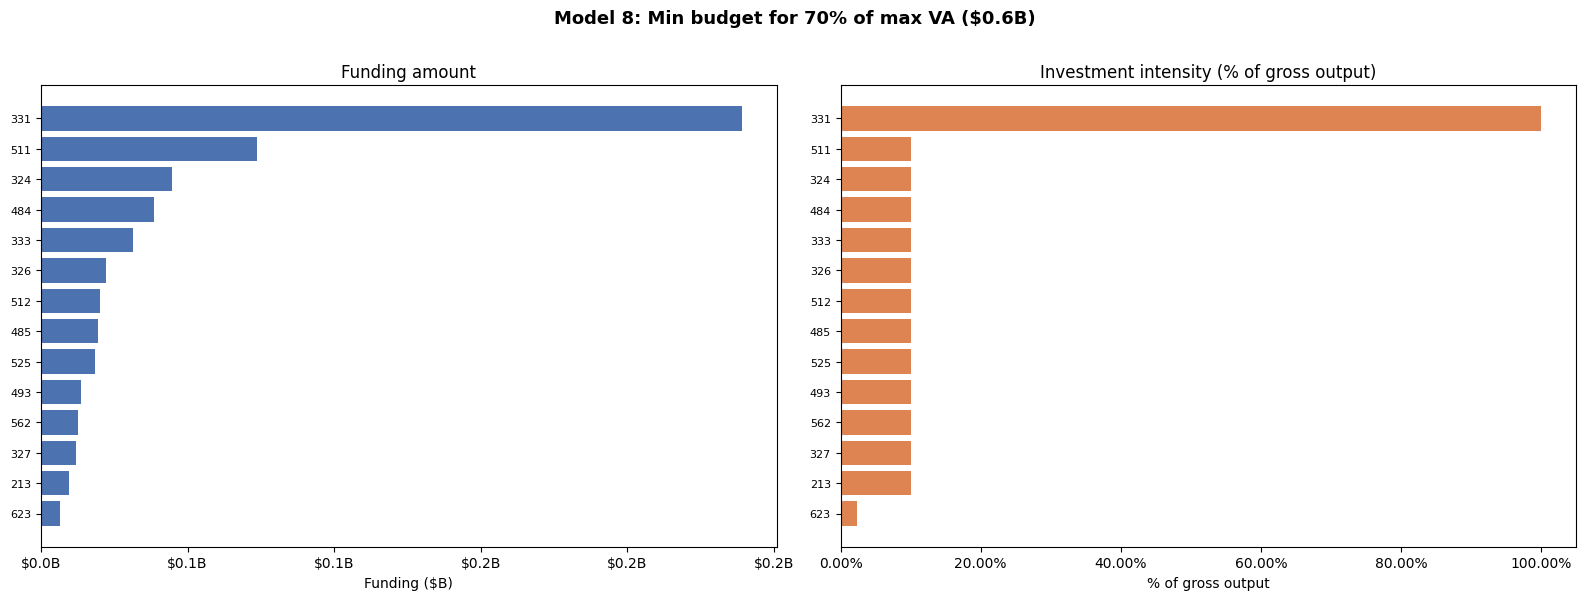

M8 target=85% of M6 obj — Optimal | Min budget: $0.86B


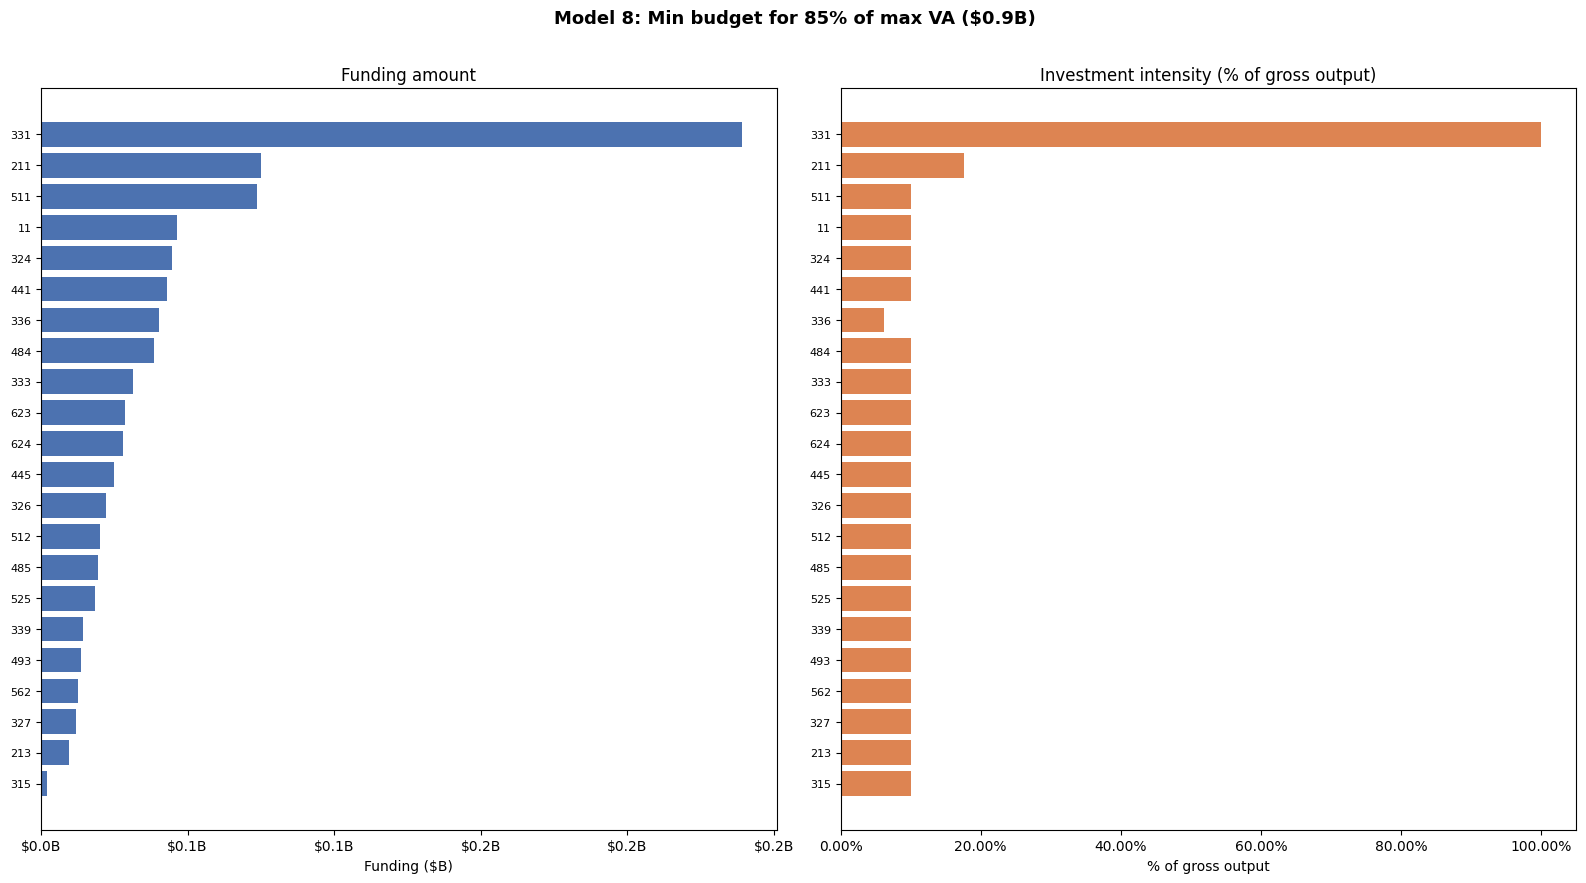

M8 target=95% of M6 obj — Optimal | Min budget: $1.51B


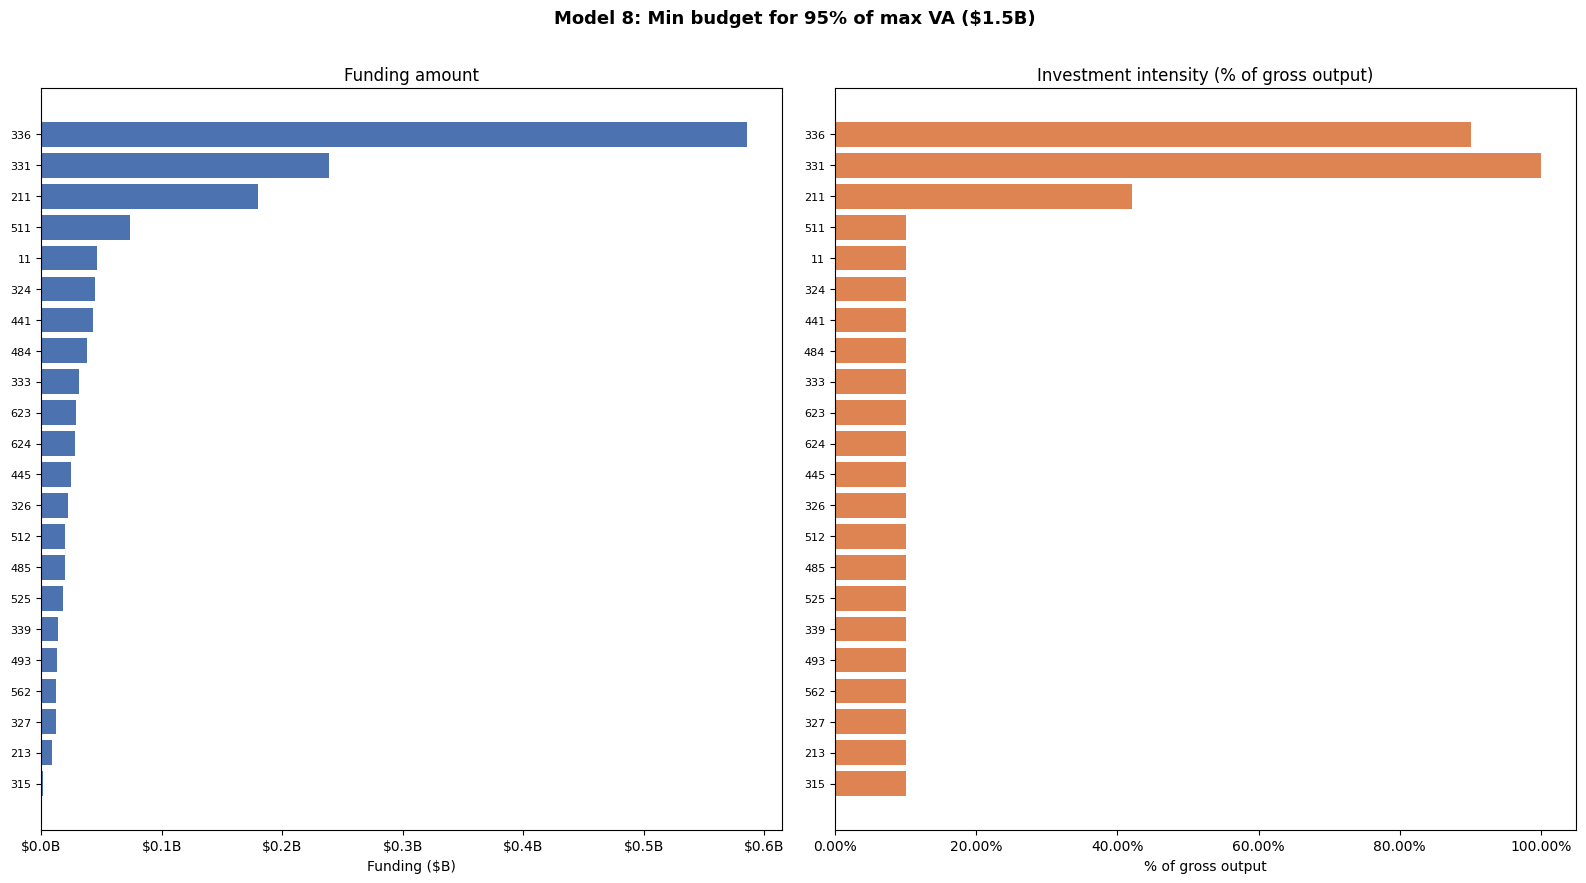

In [217]:
# Cell 13 — Model 8: Flip objective — minimize budget s.t. VA ≥ target
# Targets expressed as fractions of M6 best objective

va_target_fracs = [0.70, 0.85, 0.95]
results_m8      = {}

for frac in va_target_fracs:
    target = frac * M6_BEST_OBJ

    prob = pulp.LpProblem(f"M8_target{int(frac*100)}", pulp.LpMinimize)
    a    = [
        pulp.LpVariable(f"a_{i}", lowBound=0, upBound=(intensity_caps[i] * GO[i] if va_pos[i] else 0.0))
        for i in range(N)
    ]
    total = pulp.lpSum(a[i] for i in range(N))

    prob += total                                                              # minimize budget
    prob += pulp.lpSum(mu[i] * a[i] for i in range(N)) >= target, "va_floor" # VA target
    prob += total <= BUDGET                                                    # hard cap

    for s in range(S):
        state_wtd = pulp.lpSum(W[s, i] * a[i] for i in range(N))
        prob += state_wtd >= (equal_share - BEST_TOL) * total, f"state_lo_{s}"
        prob += state_wtd <= (equal_share + BEST_TOL) * total, f"state_hi_{s}"

    prob += (
        pulp.lpSum(a[i] for i in range(N) if priority_mask[i]) >= BEST_FLOOR * total,
        "national_priority"
    )

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    status, budget_used = solve_status(prob)
    alloc = np.array([pulp.value(a[i]) or 0.0 for i in range(N)])
    results_m8[frac] = (alloc, status)

    print(f"M8 target={frac*100:.0f}% of M6 obj — {status} | Min budget: ${budget_used/1e9:.2f}B")
    if status == "Optimal":
        plot_industry_results(alloc, GO, INDUSTRIES,
                              f"Model 8: Min budget for {frac*100:.0f}% of max VA (${budget_used/1e9:.1f}B)")

### Model 9: minimize budget subject to value added targets through funding to agencies

In [218]:
# Cell 14 — Model 9: Agency decision variable + minimize budget (M8 + M7 combined)

TARGET_FRAC_M9 = 0.85
target9        = TARGET_FRAC_M9 * M6_BEST_OBJ

prob9  = pulp.LpProblem("M9_Agency_MinBudget", pulp.LpMinimize)
b9     = [pulp.LpVariable(f"b_{k}", lowBound=0) for k in range(K)]
total9 = pulp.lpSum(b9[k] for k in range(K))

a9 = [pulp.lpSum(P[k, i] * b9[k] for k in range(K)) for i in range(N)]

prob9 += total9
prob9 += pulp.lpSum(mu[i] * a9[i] for i in range(N)) >= target9, "va_floor"
prob9 += total9 <= BUDGET

for i in range(N):
    prob9 += a9[i] <= (intensity_caps[i] * GO[i] if va_pos[i] else 0.0), f"cap_{i}"

for s in range(S):
    state_wtd = pulp.lpSum(W[s, i] * a9[i] for i in range(N))
    prob9 += state_wtd >= (equal_share - BEST_TOL) * total9, f"state_lo_{s}"
    prob9 += state_wtd <= (equal_share + BEST_TOL) * total9, f"state_hi_{s}"

prob9 += (
    pulp.lpSum(a9[i] for i in range(N) if priority_mask[i]) >= BEST_FLOOR * total9,
    "national_priority"
)

prob9.solve(pulp.PULP_CBC_CMD(msg=0))
status9, budget9 = solve_status(prob9)

if status9 == "Optimal":
    agency_alloc9 = np.array([pulp.value(b9[k]) or 0.0 for k in range(K)])
    ind_alloc9    = np.array([pulp.value(a9[i])  or 0.0 for i in range(N)])
    va_achieved   = sum(mu[i] * ind_alloc9[i] for i in range(N))
    print(f"M9 — {status9} | Min budget: ${budget9/1e9:.2f}B | VA achieved: {va_achieved:.4e}")
    plot_agency_results(agency_alloc9, AGENCIES, "Model 9: Agency-level funding (min budget)")
    plot_industry_results(ind_alloc9, GO, INDUSTRIES,
                          f"Model 9: Implied industry funding (min budget, ${budget9/1e9:.1f}B)")
else:
    print(f"M9 — {status9}")

M9 — Infeasible
